# **N-GRAMS**

Este código implementa um modelo n-gram simples para prever a próxima palavra.

Ele usa um corpus de texto para aprender as frequências das palavras e fazer previsões.

In [ ]:
# !pip install nltk

In [ ]:
import re
from collections import defaultdict
import nltk  # Importe o NLTK
from nltk.tokenize import sent_tokenize
import nltk
nltk.download('punkt_tab')

/# Função para limpar o texto (com lematização opcional)
def clean_text(text, lemmatize=False):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    if lemmatize:
        from nltk.stem import WordNetLemmatizer
        nltk.download('wordnet')
        lemmatizer = WordNetLemmatizer()
        words = text.split()
        text = ' '.join([lemmatizer.lemmatize(word) for word in words])

    return text

# Construção do modelo N-Gram
def build_ngram_model(corpus, n=2, lemmatize=False):
    ngram_counts = defaultdict(lambda: defaultdict(int))

    # Limpeza do corpus
    corpus = clean_text(corpus, lemmatize)
    sentences = sent_tokenize(corpus)  # Divide em sentenças usando NLTK
    sentences = [sentence.split() for sentence in sentences]

    for sentence in sentences:
        for i in range(len(sentence) - (n - 1)):
            prefix = tuple(sentence[i:i + (n - 1)])
            next_word = sentence[i + (n - 1)]
            ngram_counts[prefix][next_word] += 1

    return ngram_counts

# Função para prever a próxima palavra com Laplace Smoothing
def predict_next_word_ngram(ngram_model, prefix, n=2, lemmatize=False, alpha=0.1):
    prefix = clean_text(prefix, lemmatize)
    words = tuple(prefix.split()[-(n - 1):])

    if words in ngram_model:
        # Laplace Smoothing
        total_count = sum(ngram_model[words].values())
        vocab_size = len(set(word for ngram in ngram_model for word in ngram_model[ngram]))

        # Calcula as probabilidades suavizadas
        probabilities = {
            word: (count + alpha) / (total_count + alpha * vocab_size)
            for word, count in ngram_model[words].items()
        }

        next_word = max(probabilities, key=probabilities.get)
        return next_word
    return "Desconhecido"

# Função auxiliar para formatar os resultados
def print_ngram_prediction_result(prefix, expected_words, predicted_word):
    print(f"\nPrefixo: '{prefix}'")
    print(f"Saída correta esperada: {expected_words}")
    print(f"Saída prevista pelo N-Gram: '{predicted_word}'")

    if predicted_word in expected_words:
        print("Resultado: Correto!")
        return True
    else:
        print("Resultado: Incorreto.")
        return False

# Definição do corpus (mais longo e variado)
corpus = """Este é um exemplo de um corpus de texto.
Este corpus pode ser usado para treinar um modelo de linguagem n-grama.
O modelo pode prever a próxima palavra com base nas palavras anteriores.
Este corpus pode também contém informações úteis para um corpus de texto.
A linguagem natural é um campo fascinante da inteligência artificial.
O processamento de linguagem natural permite que os computadores entendam e gerem texto.
A análise de sentimento é uma aplicação importante do processamento de linguagem natural.
Um modelo de linguagem bem treinado pode gerar texto coerente e relevante.
Este texto é um exemplo adicional para aumentar a variabilidade do corpus.
Outro exemplo para testar o modelo.
"""

# Construir modelo N-Gram
n = 2  # Usando bigramas
lemmatize = False  # Define se a lematização será usada
ngram_model = build_ngram_model(corpus, n, lemmatize)

# Definição dos casos de teste (expandido e mais específico)
test_cases = [
    # Testes Positivos
    ("um corpus de", ["texto"], "Deveria prever 'texto' porque é a única ocorrência."),
    ("este corpus pode", ["ser", "também"], "Deve prever 'ser' ou 'também', ambas seguem 'este corpus pode'."),
    ("o modelo pode", ["prever"], "Deveria prever 'prever', a única palavra que segue."),
    ("base nas", ["palavras"], "Deveria prever 'palavras', a única palavra que segue."),
    ("corpus pode", ["ser", "também"], "Deve prever 'ser' ou 'também'."),
    ("o modelo", ["pode"], "Deveria prever 'pode'."),
    ("este é", ["um"], "Deveria prever 'um'."),
    ("próxima palavra", ["com"], "Deveria prever 'com'."),
    ("linguagem natural", ["é", "permite"], "Deve prever 'é' ou 'permite'."),
    ("de linguagem", ["n", "bem"], "Testando diferentes contextos."),

    # Testes Negativos (agora mais relevantes devido ao corpus maior)
    ("um teste de", ["casa"], "Não deve prever 'casa', não está no corpus."),
    ("inteligência", ["humana"], "Não deve prever 'humana', não é uma sequência comum."),

    # Casos Limítrofes
    ("este corpus", ["pode"], "Testando o início de uma frase."),
    ("modelo", ["de", "pode"], "Testando 'modelo' como palavra com múltiplas ocorrências."),
    ("exemplo", ["de", "para"], "Testando 'exemplo' com diferentes seguimentos."),

    # Sensibilidade à Capitalização/Pontuação (garantindo que a limpeza funciona)
    ("Este Corpus Pode", ["ser", "também"], "Deve funcionar mesmo com capitalização."),
    ("um corpus, de", ["texto"], "Deve funcionar mesmo com pontuação."),
    ("linguagem.", ["natural"], "Testando limpeza de ponto final")
]

# Variável para contar acertos
correct_predictions = 0

# Executando os testes
for prefix, expected, description in test_cases:
    predicted_word = predict_next_word_ngram(ngram_model, prefix, n, lemmatize)
    correct = print_ngram_prediction_result(prefix, expected, predicted_word)

    if correct:
        correct_predictions += 1

    print(f"Comentário: {description}")

# Exibir o total de acertos no final
print(f"\nTotal de acertos: {correct_predictions} de {len(test_cases)}")


Prefixo: 'um corpus de'
Saída correta esperada: ['texto']
Saída prevista pelo N-Gram: 'linguagem'
Resultado: Incorreto.
Comentário: Deveria prever 'texto' porque é a única ocorrência.

Prefixo: 'este corpus pode'
Saída correta esperada: ['ser', 'também']
Saída prevista pelo N-Gram: 'ser'
Resultado: Correto!
Comentário: Deve prever 'ser' ou 'também', ambas seguem 'este corpus pode'.

Prefixo: 'o modelo pode'
Saída correta esperada: ['prever']
Saída prevista pelo N-Gram: 'ser'
Resultado: Incorreto.
Comentário: Deveria prever 'prever', a única palavra que segue.

Prefixo: 'base nas'
Saída correta esperada: ['palavras']
Saída prevista pelo N-Gram: 'palavras'
Resultado: Correto!
Comentário: Deveria prever 'palavras', a única palavra que segue.

Prefixo: 'corpus pode'
Saída correta esperada: ['ser', 'também']
Saída prevista pelo N-Gram: 'ser'
Resultado: Correto!
Comentário: Deve prever 'ser' ou 'também'.

Prefixo: 'o modelo'
Saída correta esperada: ['pode']
Saída prevista pelo N-Gram: 'de'


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### **Limitação das abordagens anteriores e soluções propostas**
---
**N-Grams**
- **Suposição de Markov:** O modelo assume que a palavra atual depende apenas de um número limitado de palavras anteriores, o que nem sempre é verdade em linguagem natural.

- **Contexto limitado - fixo e curto:** O modelo n-gram considera apenas as n-1 palavras anteriores, podendo perder o contexto mais amplo da frase. Em "O cachorro que late no parque...", a palavra "cachorro" está muito distante de "parque" para um N-Gram pequeno.

- **Esparsidade de Dados:** Combinações raras de palavras têm probabilidade zero (ex: "gato verde" vs. "gato preto").

- **Explosão Combinatória:** O número de N-Grams cresce exponencialmente com N. Exemplo: Para N = 5 e um vocabulário de 10k palavras, há 10 elevado a 20 combinações possíveis.

# **FNNs**

**Redes Neurais Feedforward (FNN):**
- Redes neurais que processam informações em uma única direção (input → hidden layers → output). Imagine uma linha de montagem: cada camada adiciona uma transformação, mas não há "memória" do que aconteceu anteriormente.

- **Como as FNNs melhoraram os N-Grams?**
  - **Generalização:** Embeddings (representações densas de palavras) resolvem a esparsidade. Exemplo: Palavras semelhantes ("cachorro", "cão") têm embeddings próximos.
  - **Não-linearidade:** Camadas ocultas capturam padrões complexos (ex: relações sintáticas).

- **Limitações das FNNs para Sequências:**
  - **Janela Fixa de Entrada:** Ainda exigem um tamanho fixo de contexto (ex: 5 palavras como entrada). Problema: Não resolvem dependências de longo prazo
  - **Redes feedforward não conseguem lidar com sequências ou contexto:** Cada entrada é processada isoladamente, sem "memória" entre exemplos. Exemplo: Em uma conversa, uma FNN não lembra das frases anteriores.

In [ ]:
# !pip install torch nltk

In [ ]:
# nltk.download('punkt')
# nltk.download('wordnet')
# nltk.download('averaged_perceptron_tagger') # Required for word_tokenize
# Download necessary NLTK data if you haven't already

In [ ]:
import re
import nltk
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from nltk.tokenize import word_tokenize, sent_tokenize
from collections import defaultdict

# 1. Data Preprocessing (unchanged)
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def build_vocabulary(corpus):
    words = set()
    for sentence in sent_tokenize(corpus):
        for word in word_tokenize(clean_text(sentence)):
            words.add(word)
    word_to_index = {w: i for i, w in enumerate(words)}
    index_to_word = {i: w for i, w in enumerate(words)}
    return word_to_index, index_to_word

def prepare_data(corpus, word_to_index, n=2):
    sequences = []
    labels = []
    for sentence in sent_tokenize(corpus):
        sentence = word_tokenize(clean_text(sentence))
        for i in range(len(sentence) - n):
            sequence = sentence[i:i+n]
            label = sentence[i+n]
            sequences.append([word_to_index[word] for word in sequence])
            labels.append(word_to_index[label])
    return torch.tensor(sequences, dtype=torch.long), torch.tensor(labels, dtype=torch.long)

# 2. Model Definition (with Dropout)
class FFNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, n=2, dropout_rate=0.3):  # Tuned dropout rate
        super(FFNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.linear1 = nn.Linear(embedding_dim * n, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.linear2 = nn.Linear(hidden_dim, vocab_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        embedded = self.embedding(x).view(x.size(0), -1)
        out = self.linear1(embedded)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.linear2(out)
        out = self.softmax(out)
        return out

# 3. Training (tuned hyperparameters)
def train_model(model, train_data, labels, epochs=50, learning_rate=0.005): # Tuned learning rate and epochs
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate) # Using AdamW

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(train_data)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        #if (epoch+1) % 10 == 0: # Print loss less frequently
        #    print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}')

# 4. Prediction (unchanged)
def predict_next_word_ffnn(model, prefix, word_to_index, index_to_word, n=2):
    model.eval()
    with torch.no_grad():
        words = word_tokenize(clean_text(prefix))
        if len(words) < n:
            return "Not enough words in prefix"
        sequence = words[-n:]
        try:
            input_sequence = torch.tensor([word_to_index[word] for word in sequence], dtype=torch.long).unsqueeze(0)
        except KeyError:
            return "Unknown word in prefix"
        output = model(input_sequence)
        _, predicted_index = torch.max(output, 1)
        return index_to_word[predicted_index.item()]

# 5. Corpus and Test Cases (unchanged)
corpus = """Este é um exemplo de um corpus de texto.
Este corpus pode ser usado para treinar um modelo de linguagem.
O modelo pode prever a próxima palavra com base nas palavras anteriores.
Este corpus também contém informações úteis para um corpus de texto.
A linguagem natural é um campo fascinante da inteligência artificial.
O processamento de linguagem natural permite que os computadores entendam e gerem texto.
A análise de sentimento é uma aplicação importante do processamento de linguagem natural.
Um modelo de linguagem bem treinado pode gerar texto coerente e relevante.
Este texto é um exemplo adicional para aumentar a variabilidade do corpus.
Outro exemplo para testar o modelo.
"""

test_cases = [
    ("um corpus de", ["texto"], "Deveria prever 'texto'"),
    ("este corpus pode", ["ser", "também"], "Pode prever 'ser' ou 'também'"),
    ("o modelo pode", ["prever"], "Deveria prever 'prever'"),
    ("base nas", ["palavras"], "Deveria prever 'palavras'"),
    ("corpus pode", ["ser", "também"], "Pode prever 'ser' ou 'também'"),
    ("o modelo", ["pode"], "Deveria prever 'pode'"),
    ("este é", ["um"], "Deveria prever 'um'"),
    ("próxima palavra", ["com"], "Deveria prever 'com'"),
    ("linguagem natural", ["é", "permite"], "Deve prever 'é' ou 'permite'"),
    ("de linguagem", ["n", "bem"], "Testando diferentes contextos."),
    ("um teste de", ["casa"], "Não deve prever 'casa', não está no corpus."),
    ("inteligência", ["humana"], "Não deve prever 'humana', não é uma sequência comum."),
    ("este corpus", ["pode"], "Testando o início de uma frase."),
    ("modelo", ["de", "pode"], "Testando 'modelo' como palavra com múltiplas ocorrências."),
    ("exemplo", ["de", "para"], "Testando 'exemplo' com diferentes seguimentos."),
    ("Este Corpus Pode", ["ser", "também"], "Deve funcionar mesmo com capitalização."),
    ("um corpus, de", ["texto"], "Deve funcionar mesmo com pontuação."),
    ("linguagem.", ["natural"], "Testando limpeza de ponto final")
]

# 6. Main Execution
word_to_index, index_to_word = build_vocabulary(corpus)
n = 2 # Use 2 previous words to predict the next (Bigram)
train_data, labels = prepare_data(corpus, word_to_index, n)

# Model parameters (tuned)
vocab_size = len(word_to_index)
embedding_dim = 64 # Reduced embedding dimension
hidden_dim = 128  # Reduced hidden dimension

model = FFNN(vocab_size, embedding_dim, hidden_dim, n)

# Train the model
train_model(model, train_data, labels, epochs=50) # Train for more epochs

# Test the model
correct_predictions = 0
for prefix, expected, description in test_cases:
    predicted_word = predict_next_word_ffnn(model, prefix, word_to_index, index_to_word, n)
    print(f"\nPrefixo: '{prefix}'")
    print(f"Saída correta esperada: {expected}")
    print(f"Saída prevista pelo FNN: '{predicted_word}'")

    if predicted_word in expected:
        print("Resultado: Correto!")
        correct_predictions += 1
    else:
        print("Resultado: Incorreto.")
    print(f"Comentário: {description}")

print(f"\nTotal de acertos: {correct_predictions} de {len(test_cases)}")


Prefixo: 'um corpus de'
Saída correta esperada: ['texto']
Saída prevista pelo FNN: 'texto'
Resultado: Correto!
Comentário: Deveria prever 'texto'

Prefixo: 'este corpus pode'
Saída correta esperada: ['ser', 'também']
Saída prevista pelo FNN: 'ser'
Resultado: Correto!
Comentário: Pode prever 'ser' ou 'também'

Prefixo: 'o modelo pode'
Saída correta esperada: ['prever']
Saída prevista pelo FNN: 'prever'
Resultado: Correto!
Comentário: Deveria prever 'prever'

Prefixo: 'base nas'
Saída correta esperada: ['palavras']
Saída prevista pelo FNN: 'palavras'
Resultado: Correto!
Comentário: Deveria prever 'palavras'

Prefixo: 'corpus pode'
Saída correta esperada: ['ser', 'também']
Saída prevista pelo FNN: 'ser'
Resultado: Correto!
Comentário: Pode prever 'ser' ou 'também'

Prefixo: 'o modelo'
Saída correta esperada: ['pode']
Saída prevista pelo FNN: 'pode'
Resultado: Correto!
Comentário: Deveria prever 'pode'

Prefixo: 'este é'
Saída correta esperada: ['um']
Saída prevista pelo FNN: 'um'
Resulta

# **RNN**

**As RNNs são projetadas especificamente para lidar com dados sequenciais, o que as torna mais adequadas para modelagem de linguagem do que os N-grams ou FNNs simples.**

---

**Principais Melhorias Esperadas com uma RNN:**

- **Melhor Captura de Dependências de Longo Alcance:**
   - N-grams: Os N-grams têm uma janela de contexto fixa (n palavras). Eles não conseguem capturar dependências entre palavras que estão mais distantes umas das outras na frase.
   - FNNs: O FNN que implementamos também tem um contexto limitado (n palavras). Embora as camadas de embedding e ocultas permitam que ele aprenda representações mais ricas, ele ainda é limitado pela janela de contexto fixa.
  - RNNs: As RNNs, por sua natureza recorrente, mantêm um estado oculto que é atualizado a cada passo de tempo (a cada palavra na sequência). Esse estado oculto permite que a rede "lembre" informações sobre as palavras anteriores na sequência e use essas informações para prever as palavras futuras. Isso permite que as RNNs capturem dependências de longo alcance de forma mais eficaz.

**Melhor Modelagem de Sequências:**
   - N-grams: Os N-grams tratam cada sequência de n palavras como independente. Eles não têm um conceito real de "sequência" ou "ordem" das palavras além da janela de contexto fixa.
   - FNNs: O FNN processa as palavras de entrada em um contexto fixo, mas não tem um mecanismo inerente para modelar a ordem ou a sequência das palavras.
   - RNNs: As RNNs processam as palavras de entrada sequencialmente, atualizando seu estado oculto a cada passo. Isso permite que elas aprendam a modelar a ordem e a sequência das palavras de forma mais natural.

**Generalização Aprimorada:**
   - Como as RNNs podem capturar dependências de longo alcance e modelar sequências de forma mais eficaz, elas geralmente generalizam melhor do que os N-grams e FNNs, especialmente com corpora maiores.

In [ ]:
# RNN Vanilla - mesmo corpus

import re
import nltk
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from nltk.tokenize import word_tokenize, sent_tokenize
from collections import defaultdict

# 1. Data Preprocessing (unchanged)
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def build_vocabulary(corpus):
    words = set()
    for sentence in sent_tokenize(corpus):
        for word in word_tokenize(clean_text(sentence)):
            words.add(word)
    word_to_index = {w: i for i, w in enumerate(words)}
    index_to_word = {i: w for i, w in enumerate(words)}
    return word_to_index, index_to_word

def prepare_data(corpus, word_to_index):
    sequences = []
    labels = []
    for sentence in sent_tokenize(corpus):
        sentence = word_tokenize(clean_text(sentence))
        for i in range(len(sentence) - 1):
            sequence = sentence[:i+1]  # Accumulating sequence
            label = sentence[i+1]
            sequences.append([word_to_index[word] for word in sequence])
            labels.append(word_to_index[label])
    return sequences, labels

def pad_sequences(sequences, max_len, padding_index):
    padded_sequences = []
    for seq in sequences:
        if len(seq) < max_len:
            padded_seq = seq + [padding_index] * (max_len - len(seq))
        else:
            padded_seq = seq[-max_len:] # Truncate from the beginning if longer
        padded_sequences.append(padded_seq)
    return torch.tensor(padded_sequences, dtype=torch.long)

# 2. Model Definition (Vanilla RNN with Dropout)
class SimpleRNNModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, dropout_rate=0.5): # Added dropout
        super(SimpleRNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True) # Changed to nn.RNN
        self.dropout = nn.Dropout(dropout_rate) # Added dropout
        self.linear = nn.Linear(hidden_dim, vocab_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        embedded = self.embedding(x)
        output, _ = self.rnn(embedded)
        output = self.dropout(output[:, -1, :]) # Apply dropout
        output = self.linear(output)
        output = self.softmax(output)
        return output

# 3. Training
def train_model(model, train_data, labels, epochs=50, learning_rate=0.001): # Increased learning rate
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate) # Changed to SGD

    for epoch in range(epochs):
        model.train()
        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(train_data)

        # Calculate the loss
        loss = criterion(outputs, labels) # Make sure the inputs are correct

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        #if (epoch+1) % 10 == 0:
        #    print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}')

# 4. Prediction (Revisited)
def predict_next_word_rnn(model, prefix, word_to_index, index_to_word, max_len):
    model.eval()
    with torch.no_grad():
        words = word_tokenize(clean_text(prefix))
        input_sequence = [word_to_index.get(word, word_to_index.get("<UNK>", 0)) for word in words] # Handle unknown words

        # Pad the sequence
        if len(input_sequence) < max_len:
          padded_sequence = input_sequence + [word_to_index.get("<PAD>", 0)] * (max_len - len(input_sequence))
        else:
          padded_sequence = input_sequence[-max_len:]

        input_tensor = torch.tensor([padded_sequence], dtype=torch.long) # Remove unsqueeze(0)
        # input_tensor = torch.tensor([padded_sequence], dtype=torch.long).unsqueeze(0)  # Add batch dimension #Removido

        output = model(input_tensor)
        _, predicted_index = torch.max(output, 1) # Get the index of the max log-probability
        predicted_word = index_to_word[predicted_index.item()] # Map the index to the word

        return predicted_word

# 5. Corpus and Test Cases (unchanged)
corpus = """Este é um exemplo de um corpus de texto.
Este corpus pode ser usado para treinar um modelo de linguagem.
O modelo pode prever a próxima palavra com base nas palavras anteriores.
Este corpus também contém informações úteis para um corpus de texto.
A linguagem natural é um campo fascinante da inteligência artificial.
O processamento de linguagem natural permite que os computadores entendam e gerem texto.
A análise de sentimento é uma aplicação importante do processamento de linguagem natural.
Um modelo de linguagem bem treinado pode gerar texto coerente e relevante.
Este texto é um exemplo adicional para aumentar a variabilidade do corpus.
Outro exemplo para testar o modelo.
"""

test_cases = [
    ("um corpus de", ["texto"], "Deveria prever 'texto'"),
    ("este corpus pode", ["ser", "também"], "Pode prever 'ser' ou 'também'"),
    ("o modelo pode", ["prever"], "Deveria prever 'prever'"),
    ("base nas", ["palavras"], "Deveria prever 'palavras'"),
    ("corpus pode", ["ser", "também"], "Pode prever 'ser' ou 'também'"),
    ("o modelo", ["pode"], "Deveria prever 'pode'"),
    ("este é", ["um"], "Deveria prever 'um'"),
    ("próxima palavra", ["com"], "Deveria prever 'com'"),
    ("linguagem natural", ["é", "permite"], "Deve prever 'é' ou 'permite'"),
    ("de linguagem", ["n", "bem"], "Testando diferentes contextos."),
    ("um teste de", ["casa"], "Não deve prever 'casa', não está no corpus."),
    ("inteligência", ["humana"], "Não deve prever 'humana', não é uma sequência comum."),
    ("este corpus", ["pode"], "Testando o início de uma frase."),
    ("modelo", ["de", "pode"], "Testando 'modelo' como palavra com múltiplas ocorrências."),
    ("exemplo", ["de", "para"], "Testando 'exemplo' com diferentes seguimentos."),
    ("Este Corpus Pode", ["ser", "também"], "Deve funcionar mesmo com capitalização."),
    ("um corpus, de", ["texto"], "Deve funcionar mesmo com pontuação."),
    ("linguagem.", ["natural"], "Testando limpeza de ponto final")
]

# 6. Main Execution
word_to_index, index_to_word = build_vocabulary(corpus)

# Add special tokens
word_to_index["<PAD>"] = len(word_to_index)
index_to_word[len(word_to_index)-1] = "<PAD>"
word_to_index["<UNK>"] = len(word_to_index)
index_to_word[len(word_to_index)-1] = "<UNK>"


sequences, labels = prepare_data(corpus, word_to_index)
max_len = max(len(s) for s in sequences)  # Find the maximum sequence length
train_data = pad_sequences(sequences, max_len, word_to_index["<PAD>"])
labels = torch.tensor(labels, dtype=torch.long) # Convert labels to tensor

# Model parameters
vocab_size = len(word_to_index)
embedding_dim = 64
hidden_dim = 32 # Reduced hidden dimension

model = SimpleRNNModel(vocab_size, embedding_dim, hidden_dim)

# Train the model
train_model(model, train_data, labels, epochs=50, learning_rate=0.001)

# Test the model
correct_predictions = 0
for prefix, expected, description in test_cases:
    predicted_word = predict_next_word_rnn(model, prefix, word_to_index, index_to_word, max_len)
    print(f"\nPrefixo: '{prefix}'")
    print(f"Saída correta esperada: {expected}")
    print(f"Saída prevista pela RNN Vanilla: '{predicted_word}'")

    if predicted_word in expected:
        print("Resultado: Correto!")
        correct_predictions += 1
    else:
        print("Resultado: Incorreto.")
    print(f"Comentário: {description}")

print(f"\nTotal de acertos: {correct_predictions} de {len(test_cases)}")


Prefixo: 'um corpus de'
Saída correta esperada: ['texto']
Saída prevista pela RNN Vanilla: 'o'
Resultado: Incorreto.
Comentário: Deveria prever 'texto'

Prefixo: 'este corpus pode'
Saída correta esperada: ['ser', 'também']
Saída prevista pela RNN Vanilla: 'o'
Resultado: Incorreto.
Comentário: Pode prever 'ser' ou 'também'

Prefixo: 'o modelo pode'
Saída correta esperada: ['prever']
Saída prevista pela RNN Vanilla: 'o'
Resultado: Incorreto.
Comentário: Deveria prever 'prever'

Prefixo: 'base nas'
Saída correta esperada: ['palavras']
Saída prevista pela RNN Vanilla: 'o'
Resultado: Incorreto.
Comentário: Deveria prever 'palavras'

Prefixo: 'corpus pode'
Saída correta esperada: ['ser', 'também']
Saída prevista pela RNN Vanilla: 'o'
Resultado: Incorreto.
Comentário: Pode prever 'ser' ou 'também'

Prefixo: 'o modelo'
Saída correta esperada: ['pode']
Saída prevista pela RNN Vanilla: 'o'
Resultado: Incorreto.
Comentário: Deveria prever 'pode'

Prefixo: 'este é'
Saída correta esperada: ['um']


**RNN Vanilla é Inadequada:** A arquitetura RNN Vanilla simplesmente não é capaz de capturar as dependências necessárias para esta tarefa, dadas as restrições de tamanho do corpus e complexidade do modelo.

**Corpus Muito Pequeno:** O corpus de treinamento é tão pequeno que nenhum modelo, mesmo um mais poderoso como uma LSTM, consegue generalizar bem. As informações nos dados são insuficientes para treinar um modelo útil.

In [ ]:
import re
import nltk
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from nltk.tokenize import word_tokenize, sent_tokenize
from collections import defaultdict

# 1. Data Preprocessing (unchanged)
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def build_vocabulary(corpus):
    words = set()
    for sentence in sent_tokenize(corpus):
        for word in word_tokenize(clean_text(sentence)):
            words.add(word)
    word_to_index = {w: i for i, w in enumerate(words)}
    index_to_word = {i: w for i, w in enumerate(words)}
    return word_to_index, index_to_word

def prepare_data(corpus, word_to_index):
    sequences = []
    labels = []
    for sentence in sent_tokenize(corpus):
        sentence = word_tokenize(clean_text(sentence))
        for i in range(len(sentence) - 1):
            sequence = sentence[:i+1]  # Accumulating sequence
            label = sentence[i+1]
            sequences.append([word_to_index[word] for word in sequence])
            labels.append(word_to_index[label])
    return sequences, labels

def pad_sequences(sequences, max_len, padding_index):
    padded_sequences = []
    for seq in sequences:
        if len(seq) < max_len:
            padded_seq = seq + [padding_index] * (max_len - len(seq))
        else:
            padded_seq = seq[-max_len:] # Truncate from the beginning if longer
        padded_sequences.append(padded_seq)
    return torch.tensor(padded_sequences, dtype=torch.long)

# 2. Model Definition (Vanilla RNN with Dropout)
class SimpleRNNModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, dropout_rate=0.5): # Added dropout
        super(SimpleRNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True) # Changed to nn.RNN
        self.dropout = nn.Dropout(dropout_rate) # Added dropout
        self.linear = nn.Linear(hidden_dim, vocab_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        embedded = self.embedding(x)
        output, _ = self.rnn(embedded)
        output = self.dropout(output[:, -1, :]) # Apply dropout
        output = self.linear(output)
        output = self.softmax(output)
        return output

# 3. Training
def train_model(model, train_data, labels, epochs=50, learning_rate=0.001): # Increased learning rate
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate) # Changed to SGD

    for epoch in range(epochs):
        model.train()
        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(train_data)

        # Calculate the loss
        loss = criterion(outputs, labels) # Make sure the inputs are correct

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        #if (epoch+1) % 10 == 0:
        #    print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}')

# 4. Prediction (Revisited)
def predict_next_word_rnn(model, prefix, word_to_index, index_to_word, max_len):
    model.eval()
    with torch.no_grad():
        words = word_tokenize(clean_text(prefix))
        input_sequence = [word_to_index.get(word, word_to_index.get("<UNK>", 0)) for word in words] # Handle unknown words

        # Pad the sequence
        if len(input_sequence) < max_len:
          padded_sequence = input_sequence + [word_to_index.get("<PAD>", 0)] * (max_len - len(input_sequence))
        else:
          padded_sequence = input_sequence[-max_len:]

        input_tensor = torch.tensor([padded_sequence], dtype=torch.long) # Remove unsqueeze(0)
        # input_tensor = torch.tensor([padded_sequence], dtype=torch.long).unsqueeze(0)  # Add batch dimension #Removido

        output = model(input_tensor)
        _, predicted_index = torch.max(output, 1) # Get the index of the max log-probability
        predicted_word = index_to_word[predicted_index.item()] # Map the index to the word

        return predicted_word

# 5. Corpus and Test Cases (Corpus Expandido)
corpus = """
Este é um exemplo de um corpus de texto.
Este corpus pode ser usado para treinar um modelo de linguagem.
O modelo pode prever a próxima palavra com base nas palavras anteriores.
Este corpus também contém informações úteis para um corpus de texto.
A linguagem natural é um campo fascinante da inteligência artificial.
O processamento de linguagem natural permite que os computadores entendam e gerem texto.
A análise de sentimento é uma aplicação importante do processamento de linguagem natural.
Um modelo de linguagem bem treinado pode gerar texto coerente e relevante.
Este texto é um exemplo adicional para aumentar a variabilidade do corpus.
Outro exemplo para testar o modelo.
A inteligência artificial está transformando o mundo.
As máquinas estão aprendendo a realizar tarefas complexas.
O aprendizado de máquina é um subcampo da inteligência artificial.
As redes neurais são um tipo de modelo de aprendizado de máquina.
O processamento de linguagem natural é essencial para a comunicação entre humanos e computadores.
A tradução automática é uma aplicação importante do processamento de linguagem natural.
A geração de texto é outra aplicação importante do processamento de linguagem natural.
Os chatbots estão se tornando cada vez mais populares.
Os assistentes virtuais estão ajudando as pessoas a realizar tarefas diárias.
A análise de dados está revelando insights valiosos em diversas áreas.
A ciência de dados é um campo multidisciplinar que envolve a coleta, o processamento e a análise de dados.
A visualização de dados é uma ferramenta poderosa para comunicar informações complexas.
A tomada de decisões baseada em dados está se tornando cada vez mais comum.
A ética em inteligência artificial é uma preocupação crescente.
É importante garantir que a inteligência artificial seja usada de forma responsável e ética.
A transparência e a explicabilidade dos modelos de inteligência artificial são fundamentais.
A inteligência artificial pode ser usada para resolver problemas complexos em diversas áreas, como saúde, educação e meio ambiente.
O futuro da inteligência artificial é promissor, mas é importante estar ciente dos desafios e riscos.
O desenvolvimento de inteligência artificial requer uma colaboração entre pesquisadores, engenheiros e formuladores de políticas.
A inteligência artificial está mudando a forma como vivemos e trabalhamos.
"""

test_cases = [
    ("um corpus de", ["texto"], "Deveria prever 'texto'"),
    ("este corpus pode", ["ser", "também"], "Pode prever 'ser' ou 'também'"),
    ("o modelo pode", ["prever"], "Deveria prever 'prever'"),
    ("base nas", ["palavras"], "Deveria prever 'palavras'"),
    ("corpus pode", ["ser", "também"], "Pode prever 'ser' ou 'também'"),
    ("o modelo", ["pode"], "Deveria prever 'pode'"),
    ("este é", ["um"], "Deveria prever 'um'"),
    ("próxima palavra", ["com"], "Deveria prever 'com'"),
    ("linguagem natural", ["é", "permite"], "Deve prever 'é' ou 'permite'"),
    ("de linguagem", ["n", "bem"], "Testando diferentes contextos."),
    ("um teste de", ["casa"], "Não deve prever 'casa', não está no corpus."),
    ("inteligência", ["humana"], "Não deve prever 'humana', não é uma sequência comum."),
    ("este corpus", ["pode"], "Testando o início de uma frase."),
    ("modelo", ["de", "pode"], "Testando 'modelo' como palavra com múltiplas ocorrências."),
    ("exemplo", ["de", "para"], "Testando 'exemplo' com diferentes seguimentos."),
    ("Este Corpus Pode", ["ser", "também"], "Deve funcionar mesmo com capitalização."),
    ("um corpus, de", ["texto"], "Deve funcionar mesmo com pontuação."),
    ("linguagem.", ["natural"], "Testando limpeza de ponto final")
]

# 6. Main Execution
word_to_index, index_to_word = build_vocabulary(corpus)

# Add special tokens
word_to_index["<PAD>"] = len(word_to_index)
index_to_word[len(word_to_index)-1] = "<PAD>"
word_to_index["<UNK>"] = len(word_to_index)
index_to_word[len(word_to_index)-1] = "<UNK>"


sequences, labels = prepare_data(corpus, word_to_index)
max_len = max(len(s) for s in sequences)  # Find the maximum sequence length
train_data = pad_sequences(sequences, max_len, word_to_index["<PAD>"])
labels = torch.tensor(labels, dtype=torch.long) # Convert labels to tensor

# Model parameters
vocab_size = len(word_to_index)
embedding_dim = 64
hidden_dim = 32 # Reduced hidden dimension

model = SimpleRNNModel(vocab_size, embedding_dim, hidden_dim)

# Train the model
train_model(model, train_data, labels, epochs=50, learning_rate=0.001)

# Test the model
correct_predictions = 0
for prefix, expected, description in test_cases:
    predicted_word = predict_next_word_rnn(model, prefix, word_to_index, index_to_word, max_len)
    print(f"\nPrefixo: '{prefix}'")
    print(f"Saída correta esperada: {expected}")
    print(f"Saída prevista pela RNN Vanilla: '{predicted_word}'")

    if predicted_word in expected:
        print("Resultado: Correto!")
        correct_predictions += 1
    else:
        print("Resultado: Incorreto.")
    print(f"Comentário: {description}")

print(f"\nTotal de acertos: {correct_predictions} de {len(test_cases)}")


Prefixo: 'um corpus de'
Saída correta esperada: ['texto']
Saída prevista pela RNN Vanilla: 'e'
Resultado: Incorreto.
Comentário: Deveria prever 'texto'

Prefixo: 'este corpus pode'
Saída correta esperada: ['ser', 'também']
Saída prevista pela RNN Vanilla: 'e'
Resultado: Incorreto.
Comentário: Pode prever 'ser' ou 'também'

Prefixo: 'o modelo pode'
Saída correta esperada: ['prever']
Saída prevista pela RNN Vanilla: 'e'
Resultado: Incorreto.
Comentário: Deveria prever 'prever'

Prefixo: 'base nas'
Saída correta esperada: ['palavras']
Saída prevista pela RNN Vanilla: 'e'
Resultado: Incorreto.
Comentário: Deveria prever 'palavras'

Prefixo: 'corpus pode'
Saída correta esperada: ['ser', 'também']
Saída prevista pela RNN Vanilla: 'e'
Resultado: Incorreto.
Comentário: Pode prever 'ser' ou 'também'

Prefixo: 'o modelo'
Saída correta esperada: ['pode']
Saída prevista pela RNN Vanilla: 'e'
Resultado: Incorreto.
Comentário: Deveria prever 'pode'

Prefixo: 'este é'
Saída correta esperada: ['um']


**Conclusão:**

***Podemos concluir com segurança que a RNN Vanilla, com esta configuração e mesmo com um corpus expandido (embora ainda relativamente pequeno), não é adequada para esta tarefa de predição da próxima palavra. O problema do desaparecimento do gradiente é muito severo e impede que a rede aprenda qualquer padrão significativo.***

# **RNN - LSTM**

In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import re
import nltk
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from nltk.tokenize import word_tokenize, sent_tokenize
from collections import defaultdict
import random

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.cuda.manual_seed_all(42)  # For multi-GPU, if using
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Force deterministic algorithms
torch.use_deterministic_algorithms(True)

# 1. Data Preprocessing
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def build_vocabulary(corpus):
    words = set()
    for sentence in sent_tokenize(corpus):
        for word in word_tokenize(clean_text(sentence)):
            words.add(word)
    word_to_index = {w: i for i, w in enumerate(words)}
    index_to_word = {i: w for i, w in enumerate(words)}
    return word_to_index, index_to_word

def prepare_data(corpus, word_to_index):
    sequences = []
    labels = []
    for sentence in sent_tokenize(corpus):
        sentence = word_tokenize(clean_text(sentence))
        for i in range(len(sentence) - 1):
            sequence = sentence[:i+1]  # Accumulating sequence
            label = sentence[i+1]
            sequences.append([word_to_index[word] for word in sequence])
            labels.append(word_to_index[label])
    return sequences, labels

def pad_sequences(sequences, max_len, padding_index):
    padded_sequences = []
    for seq in sequences:
        if len(seq) < max_len:
            padded_seq = seq + [padding_index] * (max_len - len(seq))
        else:
            padded_seq = seq[-max_len:] # Truncate from the beginning if longer
        padded_sequences.append(padded_seq)
    return torch.tensor(padded_sequences, dtype=torch.long)

# 2. Model Definition (LSTM)
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):  # Removed dropout
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        # self.dropout = nn.Dropout(dropout_rate) # Removed dropout
        self.linear = nn.Linear(hidden_dim, vocab_size, bias=True)  # Added bias=True
        self.softmax = nn.LogSoftmax(dim=1) # Added softmax layer

        # Initialize weights manually
        nn.init.xavier_uniform_(self.embedding.weight)
        for name, param in self.lstm.named_parameters():
            if 'weight' in name:
                nn.init.xavier_uniform_(param)
            if 'bias' in name:
                nn.init.zeros_(param)
        nn.init.xavier_uniform_(self.linear.weight)
        nn.init.zeros_(self.linear.bias)

    def forward(self, x):
        embedded = self.embedding(x)
        output, _ = self.lstm(embedded)
        # output = self.dropout(output[:, -1, :])  # Apply dropout # Removido
        output = self.linear(output[:, -1, :]) # Modified: Take the last time step's output
        output = self.softmax(output)
        return output

# 3. Training
def train_model(model, train_data, labels, epochs=100, learning_rate=0.0005, patience=5): # Added early stopping
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate) # Changed to Adam

    best_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(train_data)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Early stopping
        if loss.item() < best_loss:
            best_loss = loss.item()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                print(f'Early stopping triggered after {epoch+1} epochs')
                break

        #if (epoch+1) % 10 == 0:
        #    print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}')

# 4. Prediction
def predict_next_word_lstm(model, prefix, word_to_index, index_to_word, max_len):
    model.eval()
    with torch.no_grad():
        words = word_tokenize(clean_text(prefix))
        input_sequence = [word_to_index.get(word, word_to_index.get("<UNK>", 0)) for word in words] # Handle unknown words

        # Pad the sequence
        if len(input_sequence) < max_len:
            padded_sequence = input_sequence + [word_to_index.get("<PAD>", 0)] * (max_len - len(input_sequence))
        else:
            padded_sequence = input_sequence[-max_len:]

        input_tensor = torch.tensor([padded_sequence], dtype=torch.long)

        output = model(input_tensor)
        _, predicted_index = torch.max(output, 1)
        return index_to_word[predicted_index.item()]

# 5. Corpus and Test Cases (unchanged)
corpus = """Este é um exemplo de um corpus de texto.
Este corpus pode ser usado para treinar um modelo de linguagem.
O modelo pode prever a próxima palavra com base nas palavras anteriores.
Este corpus também contém informações úteis para um corpus de texto.
A linguagem natural é um campo fascinante da inteligência artificial.
O processamento de linguagem natural permite que os computadores entendam e gerem texto.
A análise de sentimento é uma aplicação importante do processamento de linguagem natural.
Um modelo de linguagem bem treinado pode gerar texto coerente e relevante.
Este texto é um exemplo adicional para aumentar a variabilidade do corpus.
Outro exemplo para testar o modelo.
"""

test_cases = [
    ("um corpus de", ["texto"], "Deveria prever 'texto'"),
    ("este corpus pode", ["ser", "também"], "Pode prever 'ser' ou 'também'"),
    ("o modelo pode", ["prever"], "Deveria prever 'prever'"),
    ("base nas", ["palavras"], "Deveria prever 'palavras'"),
    ("corpus pode", ["ser", "também"], "Pode prever 'ser' ou 'também'"),
    ("o modelo", ["pode"], "Deveria prever 'pode'"),
    ("este é", ["um"], "Deveria prever 'um'"),
    ("próxima palavra", ["com"], "Deveria prever 'com'"),
    ("linguagem natural", ["é", "permite"], "Deve prever 'é' ou 'permite'"),
    ("de linguagem", ["n", "bem"], "Testando diferentes contextos."),
    ("um teste de", ["casa"], "Não deve prever 'casa', não está no corpus."),
    ("inteligência", ["humana"], "Não deve prever 'humana', não é uma sequência comum."),
    ("este corpus", ["pode"], "Testando o início de uma frase."),
    ("modelo", ["de', 'pode"], "Testando 'modelo' como palavra com múltiplas ocorrências."),
    ("exemplo", ["de", "para"], "Testando 'exemplo' com diferentes seguimentos."),
    ("Este Corpus Pode", ["ser", "também"], "Deve funcionar mesmo com capitalização."),
    ("um corpus, de", ["texto"], "Deve funcionar mesmo com pontuação."),
    ("linguagem.", ["natural"], "Testando limpeza de ponto final")
]

# 6. Main Execution
word_to_index, index_to_word = build_vocabulary(corpus)

# Add special tokens
word_to_index["<PAD>"] = len(word_to_index)
index_to_word[len(word_to_index)-1] = "<PAD>"
word_to_index["<UNK>"] = len(word_to_index)-1
index_to_word[len(word_to_index)-1] = "<UNK>"


sequences, labels = prepare_data(corpus, word_to_index)
max_len = max(len(s) for s in sequences)  # Find the maximum sequence length
train_data = pad_sequences(sequences, max_len, word_to_index["<PAD>"])
labels = torch.tensor(labels, dtype=torch.long) # Convert labels to tensor

# Model parameters (Tuning!)
vocab_size = len(word_to_index)
embedding_dim = 8 # Reduced embedding dimension
hidden_dim = 16 # Reduced hidden dimension
# dropout_rate = 0.5 # Increased dropout # Removido
learning_rate = 0.0005 # Best value
patience = 5 # Best value

model = LSTMModel(vocab_size, embedding_dim, hidden_dim)

# Train the model
train_model(model, train_data, labels, epochs=100, learning_rate=learning_rate, patience=patience)

# Print model weights
print("LSTM Weights:", model.lstm.weight_ih_l0) # Imprime os pesos da camada de entrada para oculto

# Test the model
correct_predictions = 0
for prefix, expected, description in test_cases:
    predicted_word = predict_next_word_lstm(model, prefix, word_to_index, index_to_word, max_len)
    print(f"\nPrefixo: '{prefix}'")
    print(f"Saída correta esperada: {expected}")
    print(f"Saída prevista pelo LSTM: '{predicted_word}'")

    if predicted_word in expected:
        print("Resultado: Correto!")
        correct_predictions += 1
    else:
        print("Resultado: Incorreto.")
    print(f"\nComentário: {description}")

print(f"\nTotal de acertos: {correct_predictions} de {len(test_cases)}")

LSTM Weights: Parameter containing:
tensor([[-0.0943,  0.2013, -0.0402,  0.0747,  0.2713,  0.0492,  0.2115, -0.1125],
        [ 0.0692, -0.0304,  0.3200, -0.0766,  0.0536, -0.3249,  0.3352, -0.1112],
        [ 0.1441, -0.1186, -0.1704, -0.1168, -0.1579, -0.0159,  0.0742, -0.1788],
        [ 0.1950,  0.1722, -0.2636, -0.2183,  0.1625, -0.1650,  0.0351, -0.0676],
        [-0.0162, -0.0914,  0.0694, -0.1698, -0.0608, -0.2110,  0.1323,  0.1166],
        [-0.0716,  0.0612,  0.3030,  0.1683,  0.0249, -0.3018,  0.1317,  0.0201],
        [-0.2637, -0.2212,  0.0646,  0.2402, -0.2108, -0.1839, -0.0665, -0.2932],
        [-0.2495,  0.2981,  0.2929, -0.2836,  0.0787, -0.3074,  0.1915, -0.2706],
        [-0.2162, -0.0652,  0.1121,  0.1312, -0.0668, -0.0122,  0.2933, -0.0762],
        [ 0.0172,  0.0416,  0.0380,  0.1687,  0.1543, -0.1941,  0.2814,  0.1161],
        [-0.1161,  0.3219,  0.0874,  0.1120, -0.1732,  0.1877,  0.3424, -0.2883],
        [-0.3281, -0.0144, -0.1070,  0.0072,  0.1996, -0.1082,

In [ ]:
import re
import nltk
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from nltk.tokenize import word_tokenize, sent_tokenize
from collections import defaultdict
import random

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.cuda.manual_seed_all(42)  # For multi-GPU, if using
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Force deterministic algorithms
torch.use_deterministic_algorithms(True)

# 1. Data Preprocessing
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def build_vocabulary(corpus):
    words = set()
    for sentence in sent_tokenize(corpus):
        for word in word_tokenize(clean_text(sentence)):
            words.add(word)
    word_to_index = {w: i for i, w in enumerate(words)}
    index_to_word = {i: w for i, w in enumerate(words)}
    return word_to_index, index_to_word

def prepare_data(corpus, word_to_index):
    sequences = []
    labels = []
    for sentence in sent_tokenize(corpus):
        sentence = word_tokenize(clean_text(sentence))
        for i in range(len(sentence) - 1):
            sequence = sentence[:i+1]  # Accumulating sequence
            label = sentence[i+1]
            sequences.append([word_to_index[word] for word in sequence])
            labels.append(word_to_index[label])
    return sequences, labels

def pad_sequences(sequences, max_len, padding_index):
    padded_sequences = []
    for seq in sequences:
        if len(seq) < max_len:
            padded_seq = seq + [padding_index] * (max_len - len(seq))
        else:
            padded_seq = seq[-max_len:] # Truncate from the beginning if longer
        padded_sequences.append(padded_seq)
    return torch.tensor(padded_sequences, dtype=torch.long)

# 2. Model Definition (LSTM)
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):  # Removed dropout
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        # self.dropout = nn.Dropout(dropout_rate) # Removed dropout
        self.linear = nn.Linear(hidden_dim, vocab_size, bias=True)  # Added bias=True
        self.softmax = nn.LogSoftmax(dim=1) # Added softmax layer

        # Initialize weights manually
        nn.init.xavier_uniform_(self.embedding.weight)
        for name, param in self.lstm.named_parameters():
            if 'weight' in name:
                nn.init.xavier_uniform_(param)
            if 'bias' in name:
                nn.init.zeros_(param)
        nn.init.xavier_uniform_(self.linear.weight)
        nn.init.zeros_(self.linear.bias)

    def forward(self, x):
        embedded = self.embedding(x)
        output, _ = self.lstm(embedded)
        # output = self.dropout(output[:, -1, :])  # Apply dropout # Removido
        output = self.linear(output[:, -1, :]) # Modified: Take the last time step's output
        output = self.softmax(output)
        return output

# 3. Training
def train_model(model, train_data, labels, epochs=100, learning_rate=0.0005, patience=5): # Added early stopping
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate) # Changed to Adam

    best_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(train_data)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Early stopping
        if loss.item() < best_loss:
            best_loss = loss.item()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                print(f'Early stopping triggered after {epoch+1} epochs')
                break

        #if (epoch+1) % 10 == 0:
        #    print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}')

# 4. Prediction
def predict_next_word_lstm(model, prefix, word_to_index, index_to_word, max_len):
    model.eval()
    with torch.no_grad():
        words = word_tokenize(clean_text(prefix))
        input_sequence = [word_to_index.get(word, word_to_index.get("<UNK>", 0)) for word in words] # Handle unknown words

        # Pad the sequence
        if len(input_sequence) < max_len:
            padded_sequence = input_sequence + [word_to_index.get("<PAD>", 0)] * (max_len - len(input_sequence))
        else:
            padded_sequence = input_sequence[-max_len:]

        input_tensor = torch.tensor([padded_sequence], dtype=torch.long)

        output = model(input_tensor)
        _, predicted_index = torch.max(output, 1)
        return index_to_word[predicted_index.item()]

# 5. Corpus and Test Cases (Corpus Expandido)
corpus = """
Este é um exemplo de um corpus de texto.
Este corpus pode ser usado para treinar um modelo de linguagem.
O modelo pode prever a próxima palavra com base nas palavras anteriores.
Este corpus também contém informações úteis para um corpus de texto.
A linguagem natural é um campo fascinante da inteligência artificial.
O processamento de linguagem natural permite que os computadores entendam e gerem texto.
A análise de sentimento é uma aplicação importante do processamento de linguagem natural.
Um modelo de linguagem bem treinado pode gerar texto coerente e relevante.
Este texto é um exemplo adicional para aumentar a variabilidade do corpus.
Outro exemplo para testar o modelo.
A inteligência artificial está transformando o mundo.
As máquinas estão aprendendo a realizar tarefas complexas.
O aprendizado de máquina é um subcampo da inteligência artificial.
As redes neurais são um tipo de modelo de aprendizado de máquina.
O processamento de linguagem natural é essencial para a comunicação entre humanos e computadores.
A tradução automática é uma aplicação importante do processamento de linguagem natural.
A geração de texto é outra aplicação importante do processamento de linguagem natural.
Os chatbots estão se tornando cada vez mais populares.
Os assistentes virtuais estão ajudando as pessoas a realizar tarefas diárias.
A análise de dados está revelando insights valiosos em diversas áreas.
A ciência de dados é um campo multidisciplinar que envolve a coleta, o processamento e a análise de dados.
A visualização de dados é uma ferramenta poderosa para comunicar informações complexas.
A tomada de decisões baseada em dados está se tornando cada vez mais comum.
A ética em inteligência artificial é uma preocupação crescente.
É importante garantir que a inteligência artificial seja usada de forma responsável e ética.
A transparência e a explicabilidade dos modelos de inteligência artificial são fundamentais.
A inteligência artificial pode ser usada para resolver problemas complexos em diversas áreas, como saúde, educação e meio ambiente.
O futuro da inteligência artificial é promissor, mas é importante estar ciente dos desafios e riscos.
O desenvolvimento de inteligência artificial requer uma colaboração entre pesquisadores, engenheiros e formuladores de políticas.
A inteligência artificial está mudando a forma como vivemos e trabalhamos.
Modelos de linguagem são ferramentas poderosas para diversas aplicações.
Um modelo de linguagem pode ser usado para gerar texto, traduzir idiomas e responder a perguntas.
O treinamento de um modelo de linguagem requer um grande conjunto de dados de texto.
A qualidade dos dados de treinamento é crucial para o desempenho do modelo.
Existem diferentes tipos de modelos de linguagem, como modelos n-grama, modelos de rede neural e modelos transformadores.
Os modelos de rede neural, como as redes recorrentes e as redes transformadoras, são capazes de capturar dependências complexas na linguagem.
Os modelos transformadores, como o BERT e o GPT, obtiveram resultados impressionantes em diversas tarefas de processamento de linguagem natural.
O ajuste fino de um modelo de linguagem pré-treinado pode melhorar seu desempenho em uma tarefa específica.
A avaliação de um modelo de linguagem é importante para medir sua precisão e
capacidade de generalização.
Existem diferentes métricas para avaliar modelos de linguagem, como perplexidade, precisão e revocação.
A perplexidade mede a incerteza do modelo ao prever a próxima palavra em uma sequência.
A precisão mede a proporção de previsões corretas do modelo.
A revocação mede a proporção de palavras relevantes que o modelo consegue prever.
O processamento de linguagem natural é um campo em constante evolução.
Novas técnicas e modelos estão sendo desenvolvidos continuamente.
A pesquisa em processamento de linguagem natural está focada em melhorar a precisão, a eficiência e a interpretabilidade dos modelos.
Aplicações de processamento de linguagem natural estão se tornando cada vez mais comuns em diversas áreas, como saúde, finanças e educação.
A análise de dados de texto pode revelar insights valiosos sobre o comportamento humano, as tendências sociais e as opiniões políticas.
Os modelos de linguagem podem ser usados para detectar notícias falsas e discurso de ódio.
A inteligência artificial e o processamento de linguagem natural têm o potencial de transformar a forma como interagimos com a tecnologia e com o mundo ao nosso redor.
É importante considerar as implicações éticas do uso da inteligência artificial e do processamento de linguagem natural.
A privacidade dos dados e a segurança dos modelos são preocupações importantes que precisam ser abordadas.
A colaboração entre pesquisadores, engenheiros, formuladores de políticas e o público é essencial para garantir que a inteligência artificial e o processamento de linguagem natural sejam usados de forma responsável e ética.
A inteligência artificial está se tornando cada vez mais presente em nossas vidas.
Os algoritmos de aprendizado de máquina estão aprendendo a tomar decisões em nosso lugar.
É importante entender como esses algoritmos funcionam e como eles podem nos afetar.
A transparência e a explicabilidade são fundamentais para garantir que a inteligência artificial seja usada de forma justa e imparcial.
A inteligência artificial tem o potencial de resolver alguns dos maiores desafios que a humanidade enfrenta, como as mudanças climáticas, a pobreza e a doença.
No entanto, também é importante estar ciente dos riscos e garantir que a inteligência artificial seja usada de forma responsável e ética.
A educação em inteligência artificial é essencial para preparar as pessoas para o futuro.
É importante que as pessoas entendam os conceitos básicos da inteligência artificial e como ela pode ser usada para resolver problemas.
A inteligência artificial é uma ferramenta poderosa que pode ser usada para o bem ou para o mal.
Depende de nós garantir que ela seja usada de forma responsável e ética.
"""

test_cases = [
    ("um corpus de", ["texto"], "Deveria prever 'texto'"),
    ("este corpus pode", ["ser", "também"], "Pode prever 'ser' ou 'também'"),
    ("o modelo pode", ["prever"], "Deveria prever 'prever'"),
    ("base nas", ["palavras"], "Deveria prever 'palavras'"),
    ("corpus pode", ["ser", "também"], "Pode prever 'ser' ou 'também'"),
    ("o modelo", ["pode"], "Deveria prever 'pode'"),
    ("este é", ["um"], "Deveria prever 'um'"),
    ("próxima palavra", ["com"], "Deveria prever 'com'"),
    ("linguagem natural", ["é", "permite"], "Deve prever 'é' ou 'permite'"),
    ("de linguagem", ["n", "bem"], "Testando diferentes contextos."),
    ("um teste de", ["casa"], "Não deve prever 'casa', não está no corpus."),
    ("inteligência", ["humana"], "Não deve prever 'humana', não é uma sequência comum."),
    ("este corpus", ["pode"], "Testando o início de uma frase."),
    ("modelo", ["de", "pode"], "Testando 'modelo' como palavra com múltiplas ocorrências."),
    ("exemplo", ["de", "para"], "Testando 'exemplo' com diferentes seguimentos."),
    ("Este Corpus Pode", ["ser", "também"], "Deve funcionar mesmo com capitalização."),
    ("um corpus, de", ["texto"], "Deve funcionar mesmo com pontuação."),
    ("linguagem.", ["natural"], "Testando limpeza de ponto final")
]

# 6. Main Execution
word_to_index, index_to_word = build_vocabulary(corpus)

# Add special tokens
word_to_index["<PAD>"] = len(word_to_index)
index_to_word[len(word_to_index)-1] = "<PAD>"
word_to_index["<UNK>"] = len(word_to_index)-1
index_to_word[len(word_to_index)-1] = "<UNK>"


sequences, labels = prepare_data(corpus, word_to_index)
max_len = max(len(s) for s in sequences)  # Find the maximum sequence length
train_data = pad_sequences(sequences, max_len, word_to_index["<PAD>"])
labels = torch.tensor(labels, dtype=torch.long) # Convert labels to tensor

# Model parameters (Tuning!)
vocab_size = len(word_to_index)
embedding_dim = 8 # Reduced embedding dimension
hidden_dim = 16 # Reduced hidden dimension
# dropout_rate = 0.5 # Increased dropout # Removido
learning_rate = 0.0005 # Best value
patience = 5 # Best value

model = LSTMModel(vocab_size, embedding_dim, hidden_dim)

# Train the model
train_model(model, train_data, labels, epochs=100, learning_rate=learning_rate, patience=patience)

# Print model weights
print("LSTM Weights:", model.lstm.weight_ih_l0) # Imprime os pesos da camada de entrada para oculto

# Test the model
correct_predictions = 0
for prefix, expected, description in test_cases:
    predicted_word = predict_next_word_lstm(model, prefix, word_to_index, index_to_word, max_len)
    print(f"\nPrefixo: '{prefix}'")
    print(f"Saída correta esperada: {expected}")
    print(f"Saída prevista pelo LSTM: '{predicted_word}'")

    if predicted_word in expected:
        print("Resultado: Correto!")
        correct_predictions += 1
    else:
        print("Resultado: Incorreto.")
    print(f"\nComentário: {description}")

print(f"\nTotal de acertos: {correct_predictions} de {len(test_cases)}")

LSTM Weights: Parameter containing:
tensor([[-0.0857, -0.2203,  0.3142,  0.3117, -0.0718,  0.0444, -0.2980, -0.2922],
        [-0.0810, -0.0377, -0.1938,  0.0048,  0.1052,  0.0689, -0.0746, -0.0136],
        [ 0.3444, -0.3045, -0.1488,  0.2109,  0.1438,  0.3011,  0.1695, -0.2687],
        [-0.0148, -0.3100,  0.1657,  0.2232, -0.1810, -0.1088,  0.1054,  0.0224],
        [-0.1486, -0.0332, -0.1611,  0.1476,  0.0846,  0.1105, -0.0442, -0.0155],
        [-0.1508,  0.2019,  0.0545,  0.0732,  0.0922, -0.2057,  0.0089,  0.1828],
        [ 0.2390, -0.0311,  0.1544,  0.1224,  0.0713,  0.1971,  0.0244,  0.0232],
        [-0.1241, -0.0806,  0.2300,  0.2448, -0.1139,  0.1422, -0.2393,  0.0297],
        [ 0.1734, -0.2471,  0.2877,  0.2798,  0.2802,  0.1524,  0.0458, -0.0782],
        [-0.0791,  0.0141, -0.0504,  0.1486, -0.0746, -0.0485, -0.3011, -0.1513],
        [ 0.2424,  0.0236,  0.0456,  0.2514,  0.2746, -0.0549, -0.2821,  0.1537],
        [-0.2147, -0.2704, -0.1907, -0.1398, -0.1489,  0.0557,

# **RNN - GRU**

In [ ]:
import re
import nltk
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from nltk.tokenize import word_tokenize, sent_tokenize
from collections import defaultdict
import random

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.cuda.manual_seed_all(42)  # For multi-GPU, if using
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Force deterministic algorithms
torch.use_deterministic_algorithms(True)

# 1. Data Preprocessing
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def build_vocabulary(corpus):
    words = set()
    for sentence in sent_tokenize(corpus):
        for word in word_tokenize(clean_text(sentence)):
            words.add(word)
    word_to_index = {w: i for i, w in enumerate(words)}
    index_to_word = {i: w for i, w in enumerate(words)}
    return word_to_index, index_to_word

def prepare_data(corpus, word_to_index):
    sequences = []
    labels = []
    for sentence in sent_tokenize(corpus):
        sentence = word_tokenize(clean_text(sentence))
        for i in range(len(sentence) - 1):
            sequence = sentence[:i+1]  # Accumulating sequence
            label = sentence[i+1]
            sequences.append([word_to_index[word] for word in sequence])
            labels.append(word_to_index[label])
    return sequences, labels

def pad_sequences(sequences, max_len, padding_index):
    padded_sequences = []
    for seq in sequences:
        if len(seq) < max_len:
            padded_seq = seq + [padding_index] * (max_len - len(seq))
        else:
            padded_seq = seq[-max_len:] # Truncate from the beginning if longer
        padded_sequences.append(padded_seq)
    return torch.tensor(padded_sequences, dtype=torch.long)

# 2. Model Definition (GRU)
class GRUModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):  # Removed dropout
        super(GRUModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True)  # Changed to GRU
        self.linear = nn.Linear(hidden_dim, vocab_size, bias=True)  # Added bias=True
        self.softmax = nn.LogSoftmax(dim=1) # Added softmax layer

        # Initialize weights manually
        nn.init.xavier_uniform_(self.embedding.weight)
        for name, param in self.gru.named_parameters(): # Changed to gru
            if 'weight' in name:
                nn.init.xavier_uniform_(param)
            if 'bias' in name:
                nn.init.zeros_(param)
        nn.init.xavier_uniform_(self.linear.weight)
        nn.init.zeros_(self.linear.bias)

    def forward(self, x):
        embedded = self.embedding(x)
        output, _ = self.gru(embedded) # Changed to gru
        output = self.linear(output[:, -1, :]) # Modified: Take the last time step's output
        output = self.softmax(output)
        return output

# 3. Training
def train_model(model, train_data, labels, epochs=100, learning_rate=0.0005, patience=5): # Added early stopping
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate) # Changed to Adam

    best_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(train_data)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Early stopping
        if loss.item() < best_loss:
            best_loss = loss.item()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                print(f'Early stopping triggered after {epoch+1} epochs')
                break

        #if (epoch+1) % 10 == 0:
        #    print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}')

# 4. Prediction
def predict_next_word_gru(model, prefix, word_to_index, index_to_word, max_len): # Changed to gru
    model.eval()
    with torch.no_grad():
        words = word_tokenize(clean_text(prefix))
        input_sequence = [word_to_index.get(word, word_to_index.get("<UNK>", 0)) for word in words] # Handle unknown words

        # Pad the sequence
        if len(input_sequence) < max_len:
            padded_sequence = input_sequence + [word_to_index.get("<PAD>", 0)] * (max_len - len(input_sequence))
        else:
            padded_sequence = input_sequence[-max_len:]

        input_tensor = torch.tensor([padded_sequence], dtype=torch.long)

        output = model(input_tensor)
        _, predicted_index = torch.max(output, 1)
        return index_to_word[predicted_index.item()]

# 5. Corpus and Test Cases (Corpus Expandido)
corpus = """Este é um exemplo de um corpus de texto.
Este corpus pode ser usado para treinar um modelo de linguagem.
O modelo pode prever a próxima palavra com base nas palavras anteriores.
Este corpus também contém informações úteis para um corpus de texto.
A linguagem natural é um campo fascinante da inteligência artificial.
O processamento de linguagem natural permite que os computadores entendam e gerem texto.
A análise de sentimento é uma aplicação importante do processamento de linguagem natural.
Um modelo de linguagem bem treinado pode gerar texto coerente e relevante.
Este texto é um exemplo adicional para aumentar a variabilidade do corpus.
Outro exemplo para testar o modelo.
"""

test_cases = [
    ("um corpus de", ["texto"], "Deveria prever 'texto'"),
    ("este corpus pode", ["ser", "também"], "Pode prever 'ser' ou 'também'"),
    ("o modelo pode", ["prever"], "Deveria prever 'prever'"),
    ("base nas", ["palavras"], "Deveria prever 'palavras'"),
    ("corpus pode", ["ser", "também"], "Pode prever 'ser' ou 'também'"),
    ("o modelo", ["pode"], "Deveria prever 'pode'"),
    ("este é", ["um"], "Deveria prever 'um'"),
    ("próxima palavra", ["com"], "Deveria prever 'com'"),
    ("linguagem natural", ["é", "permite"], "Deve prever 'é' ou 'permite'"),
    ("de linguagem", ["n", "bem"], "Testando diferentes contextos."),
    ("um teste de", ["casa"], "Não deve prever 'casa', não está no corpus."),
    ("inteligência", ["humana"], "Não deve prever 'humana', não é uma sequência comum."),
    ("este corpus", ["pode"], "Testando o início de uma frase."),
    ("modelo", ["de", "pode"], "Testando 'modelo' como palavra com múltiplas ocorrências."),
    ("exemplo", ["de", "para"], "Testando 'exemplo' com diferentes seguimentos."),
    ("Este Corpus Pode", ["ser", "também"], "Deve funcionar mesmo com capitalização."),
    ("um corpus, de", ["texto"], "Deve funcionar mesmo com pontuação."),
    ("linguagem.", ["natural"], "Testando limpeza de ponto final")
]

# 6. Main Execution
word_to_index, index_to_word = build_vocabulary(corpus)

# Add special tokens
word_to_index["<PAD>"] = len(word_to_index)
index_to_word[len(word_to_index)-1] = "<PAD>"
word_to_index["<UNK>"] = len(word_to_index)-1
index_to_word[len(word_to_index)-1] = "<UNK>"


sequences, labels = prepare_data(corpus, word_to_index)
max_len = max(len(s) for s in sequences)  # Find the maximum sequence length
train_data = pad_sequences(sequences, max_len, word_to_index["<PAD>"])
labels = torch.tensor(labels, dtype=torch.long) # Convert labels to tensor

# Model parameters (Tuning!)
vocab_size = len(word_to_index)
embedding_dim = 8 # Reduced embedding dimension
hidden_dim = 16 # Reduced hidden dimension
learning_rate = 0.0005 # Best value
patience = 5 # Best value

model = GRUModel(vocab_size, embedding_dim, hidden_dim)

# Print model weights
print("GRU Weights:", model.gru.weight_ih_l0) # Imprime os pesos da camada de entrada para oculto

# Train the model
train_model(model, train_data, labels, epochs=100, learning_rate=learning_rate, patience=patience)

# Test the model
correct_predictions = 0
for prefix, expected, description in test_cases:
    predicted_word = predict_next_word_gru(model, prefix, word_to_index, index_to_word, max_len) # Changed to gru
    print(f"\nPrefixo: '{prefix}'")
    print(f"Saída correta esperada: {expected}")
    print(f"Saída prevista pelo GRU: '{predicted_word}'") # Changed to GRU

    if predicted_word in expected:
        print("Resultado: Correto!")
        correct_predictions += 1
    else:
        print("Resultado: Incorreto.")
    print(f"\nComentário: {description}")

print(f"\nTotal de acertos: {correct_predictions} de {len(test_cases)}")

GRU Weights: Parameter containing:
tensor([[-1.6465e-01,  1.4610e-01, -7.2889e-02, -6.6283e-02, -2.1141e-04,
          2.5529e-01, -4.5281e-02,  2.7085e-01],
        [ 1.9152e-01,  2.2455e-01, -2.9687e-01, -1.5306e-01, -2.6668e-01,
         -6.9520e-02, -6.7797e-02,  6.6514e-02],
        [ 2.9328e-01,  1.4694e-01, -2.2777e-01, -2.0528e-01,  2.4717e-01,
          3.2583e-02,  9.2471e-02, -1.7120e-01],
        [-3.9917e-02,  9.3192e-02, -2.1480e-01,  2.1363e-01,  1.6312e-01,
         -1.9089e-01, -1.3423e-01, -7.6955e-02],
        [ 5.0941e-02, -1.2007e-01,  3.1313e-01, -3.1528e-01, -1.8500e-01,
         -1.9868e-01,  8.8503e-02,  4.6450e-02],
        [-9.3274e-02,  2.7936e-01, -2.8257e-01,  1.1537e-01, -1.8011e-01,
         -7.4535e-02, -3.1522e-01, -2.4435e-01],
        [-2.7772e-01,  1.4280e-01, -1.2291e-01,  1.7122e-01, -1.7739e-01,
         -8.1100e-02,  3.9622e-02,  2.7428e-01],
        [-8.8219e-02,  1.8976e-01,  9.0300e-02,  1.9908e-01,  2.0678e-01,
          1.3283e-01, -9.8705e

# **Mecanismos de Atenção**

In [ ]:
import re
import nltk
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from nltk.tokenize import word_tokenize, sent_tokenize
from collections import defaultdict
import random

# Configurações para reprodutibilidade
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# 1. Pré-processamento de Dados Aprimorado
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)  # Mantém espaços entre palavras
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def build_vocabulary(corpus):
    words = set()
    for sentence in sent_tokenize(corpus):
        cleaned = clean_text(sentence)
        words.update(word_tokenize(cleaned))
    words = ['<PAD>', '<UNK>'] + sorted(words)
    return {w:i for i,w in enumerate(words)}, {i:w for i,w in enumerate(words)}

def prepare_data(corpus, word_to_index):
    sequences, labels = [], []
    for sentence in sent_tokenize(corpus):
        cleaned = clean_text(sentence)
        tokens = word_tokenize(cleaned)
        for i in range(1, len(tokens)):
            context = tokens[:i]
            target = tokens[i]
            sequences.append([word_to_index.get(w, 1) for w in context])  # 1 = <UNK>
            labels.append(word_to_index.get(target, 1))
    return sequences, labels

def pad_sequences(sequences, max_len):
    return [seq[-max_len:] + [0]*(max_len - len(seq)) for seq in sequences]  # 0 = <PAD>

# 2. Modelo Transformer Aprimorado
class EnhancedTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, num_heads=4, ff_dim=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.pos_embed = nn.Embedding(1000, embed_dim)  # Posições até 1000 tokens
        self.layers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=embed_dim,
                nhead=num_heads,
                dim_feedforward=ff_dim,
                dropout=dropout,
                activation='gelu'
            ) for _ in range(num_layers)
        ])
        self.out = nn.Linear(embed_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)
        self.init_weights()

    def init_weights(self):
        for name, param in self.named_parameters():
            if 'weight' in name and 'norm' not in name:
                nn.init.xavier_uniform_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)

    def forward(self, x):
        device = x.device
        seq_len = x.size(1)
        pos = torch.arange(seq_len, dtype=torch.long, device=device).unsqueeze(0)

        x = self.embed(x) + self.pos_embed(pos)
        x = self.dropout(x)
        x = x.permute(1, 0, 2)  # (seq_len, batch, features)

        mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(device)
        for layer in self.layers:
            x = layer(x, mask)

        x = x.permute(1, 0, 2)  # (batch, seq_len, features)
        return self.out(x[:, -1, :])  # Último token

# 3. Treinamento Aprimorado
def train_model(model, X, y, epochs=150, lr=0.001):
    criterion = nn.CrossEntropyLoss(ignore_index=0)  # Ignora padding
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)

    best_loss = float('inf')
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step(loss)

        if loss < best_loss:
            best_loss = loss.item()
            torch.save(model.state_dict(), 'best_model.pt')

        if (epoch+1) % 10 == 0:
            print(f'Epoch {epoch+1:03d} | Loss: {loss.item():.4f}')

# 4. Predição com Tratamento Melhorado
def predict(model, prefix, word_to_index, index_to_word, max_len=10):
    model.eval()
    tokens = word_tokenize(clean_text(prefix))
    seq = [word_to_index.get(w, 1) for w in tokens][-max_len:]
    padded = torch.LongTensor([seq + [0]*(max_len - len(seq))])

    with torch.no_grad():
        logits = model(padded)
        probs = torch.softmax(logits, dim=1).squeeze()
        topk = torch.topk(probs, 3)

    return [(index_to_word[i.item()], p.item()) for p,i in zip(topk.values, topk.indices)]

# 5. Corpus and Test Cases (Corpus Expandido)
corpus = """Este é um exemplo de um corpus de texto.
Este corpus pode ser usado para treinar um modelo de linguagem.
O modelo pode prever a próxima palavra com base nas palavras anteriores.
Este corpus também contém informações úteis para um corpus de texto.
A linguagem natural é um campo fascinante da inteligência artificial.
O processamento de linguagem natural permite que os computadores entendam e gerem texto.
A análise de sentimento é uma aplicação importante do processamento de linguagem natural.
Um modelo de linguagem bem treinado pode gerar texto coerente e relevante.
Este texto é um exemplo adicional para aumentar a variabilidade do corpus.
Outro exemplo para testar o modelo.
"""

test_cases = [
    ("um corpus de", ["texto"], "Deveria prever 'texto'"),
    ("este corpus pode", ["ser", "também"], "Pode prever 'ser' ou 'também'"),
    ("o modelo pode", ["prever"], "Deveria prever 'prever'"),
    ("base nas", ["palavras"], "Deveria prever 'palavras'"),
    ("corpus pode", ["ser", "também"], "Pode prever 'ser' ou 'também'"),
    ("o modelo", ["pode"], "Deveria prever 'pode'"),
    ("este é", ["um"], "Deveria prever 'um'"),
    ("próxima palavra", ["com"], "Deveria prever 'com'"),
    ("linguagem natural", ["é", "permite"], "Deve prever 'é' ou 'permite'"),
    ("de linguagem", ["n", "bem"], "Testando diferentes contextos."),
    ("um teste de", ["casa"], "Não deve prever 'casa', não está no corpus."),
    ("inteligência", ["humana"], "Não deve prever 'humana', não é uma sequência comum."),
    ("este corpus", ["pode"], "Testando o início de uma frase."),
    ("modelo", ["de", "pode"], "Testando 'modelo' como palavra com múltiplas ocorrências."),
    ("exemplo", ["de", "para"], "Testando 'exemplo' com diferentes seguimentos."),
    ("Este Corpus Pode", ["ser", "também"], "Deve funcionar mesmo com capitalização."),
    ("um corpus, de", ["texto"], "Deve funcionar mesmo com pontuação."),
    ("linguagem.", ["natural"], "Testando limpeza de ponto final")
]

# Execução Principal
word_to_index, index_to_word = build_vocabulary(corpus)
vocab_size = len(word_to_index)

sequences, labels = prepare_data(corpus, word_to_index)
max_len = max(len(s) for s in sequences)
X = torch.LongTensor(pad_sequences(sequences, max_len))
y = torch.LongTensor(labels)

model = EnhancedTransformer(vocab_size)
train_model(model, X, y)

# Testando o modelo
correct_strict = 0
correct_any = 0
top_n = 3  # Número de previsões a considerar

print("\nResultados dos Testes:")
for prefix, expected, description in test_cases:
    predictions = predict(model, prefix, word_to_index, index_to_word, max_len)
    predicted_words = [w for w, _ in predictions]
    predicted_probs = [p for _, p in predictions]

    # Acurácia estrita: a primeira previsão deve estar correta
    if predicted_words[0] in expected:
        correct_strict += 1
        strict_result = "CORRETO (ESTRITO)"
    else:
        strict_result = "INCORRETO (ESTRITO)"

    # Acurácia "generosa": alguma das palavras esperadas no top N
    if any(p in expected for p in predicted_words):
        correct_any += 1
        any_result = "CORRETO (ALGUM)"
    else:
        any_result = "INCORRETO (ALGUM)"

    print(f"\nPrefixo: '{prefix}'")
    print(f"Esperado: {expected}")
    print(f"Previsões (top {top_n}):")
    for i in range(min(top_n, len(predicted_words))):
        print(f"  {i+1}: {predicted_words[i]} ({predicted_probs[i]:.4f})")
    print(f"Resultado (Estrito): {strict_result}")
    print(f"Resultado (Algum): {any_result}")
    print(f"Descrição: {description}")

accuracy_strict = correct_strict / len(test_cases)
accuracy_any = correct_any / len(test_cases)

print(f"\nAcurácia (Estrita): {accuracy_strict:.2%}")
print(f"Acurácia (Algum): {accuracy_any:.2%}")

Epoch 010 | Loss: 3.8059
Epoch 020 | Loss: 3.5118
Epoch 030 | Loss: 3.3051
Epoch 040 | Loss: 3.0154
Epoch 050 | Loss: 2.6626
Epoch 060 | Loss: 2.4458
Epoch 070 | Loss: 2.4044
Epoch 080 | Loss: 2.3467
Epoch 090 | Loss: 2.4450
Epoch 100 | Loss: 2.3361
Epoch 110 | Loss: 2.2527
Epoch 120 | Loss: 2.3701
Epoch 130 | Loss: 2.4140
Epoch 140 | Loss: 2.3040
Epoch 150 | Loss: 2.3493

Resultados dos Testes:

Prefixo: 'um corpus de'
Esperado: ['texto']
Previsões (top 3):
  1: linguagem (0.1560)
  2: de (0.1410)
  3: corpus (0.1022)
Resultado (Estrito): INCORRETO (ESTRITO)
Resultado (Algum): INCORRETO (ALGUM)
Descrição: Deveria prever 'texto'

Prefixo: 'este corpus pode'
Esperado: ['ser', 'também']
Previsões (top 3):
  1: para (0.3157)
  2: ser (0.1118)
  3: um (0.0849)
Resultado (Estrito): INCORRETO (ESTRITO)
Resultado (Algum): CORRETO (ALGUM)
Descrição: Pode prever 'ser' ou 'também'

Prefixo: 'o modelo pode'
Esperado: ['prever']
Previsões (top 3):
  1: a (0.2211)
  2: próxima (0.0691)
  3: prever 

# **Exemplo Combinado**

## **1. Modelos N-gram (Estatística Clássica)**

**Bilbiotecas e dados de entrada**

In [ ]:
import re
import random
from collections import defaultdict, Counter
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np

corpus = """
Este é um exemplo de um corpus de texto. Este corpus pode ser usado para treinar um modelo de linguagem n-grama.
O modelo pode prever a próxima palavra com base nas palavras anteriores. Este corpus pode também contém informações úteis para um corpus de texto.
"""

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text.split()

tokens = preprocess(corpus)
print(corpus)
print(tokens[:20])


Este é um exemplo de um corpus de texto. Este corpus pode ser usado para treinar um modelo de linguagem n-grama.
O modelo pode prever a próxima palavra com base nas palavras anteriores. Este corpus pode também contém informações úteis para um corpus de texto.

['este', 'é', 'um', 'exemplo', 'de', 'um', 'corpus', 'de', 'texto', 'este', 'corpus', 'pode', 'ser', 'usado', 'para', 'treinar', 'um', 'modelo', 'de', 'linguagem']


**N-Grams**

In [ ]:
def generate_ngrams(tokens, n):
    ngrams = zip(*[tokens[i:] for i in range(n)])
    return list(ngrams)

bigrams = generate_ngrams(tokens, 2)
trigrams = generate_ngrams(tokens, 3)

print("NGrams - exemplos")
print("Exemplo de Bigram:", bigrams[:5])
print("Exemplo de Trigram:", trigrams[:5])

def build_ngram_model(ngrams):
    model = defaultdict(Counter)
    for gram in ngrams:
        prefix, word = tuple(gram[:-1]), gram[-1]
        model[prefix][word] += 1
    return model

bigram_model = build_ngram_model(bigrams)
trigram_model = build_ngram_model(trigrams)

def predict_next(model, prefix, top_k=1):
    if isinstance(prefix, str):
        prefix = tuple(prefix.lower().split())
    elif isinstance(prefix, list):
        prefix = tuple(prefix)
    if prefix in model:
        most_common = model[prefix].most_common(top_k)
        return [w for w, _ in most_common]
    else:
        return ["[desconhecido]"]

# Testes:
prefixos = [
    "um corpus de",
    "o modelo",
    "uma palavra inexistente no corpus",
    "este corpus pode",
    "texto este"
]

print("NGrams - testes")

for p in prefixos:
    tokens_p = p.lower().split()
    n = len(tokens_p) + 1
    modelo = trigram_model if n == 3 else bigram_model
    pred = predict_next(modelo, tokens_p)
    print(f"{p} ➜ {pred}")

print(corpus)

NGrams - exemplos
Exemplo de Bigram: [('este', 'é'), ('é', 'um'), ('um', 'exemplo'), ('exemplo', 'de'), ('de', 'um')]
Exemplo de Trigram: [('este', 'é', 'um'), ('é', 'um', 'exemplo'), ('um', 'exemplo', 'de'), ('exemplo', 'de', 'um'), ('de', 'um', 'corpus')]
NGrams - testes
um corpus de ➜ ['[desconhecido]']
o modelo ➜ ['pode']
uma palavra inexistente no corpus ➜ ['[desconhecido]']
este corpus pode ➜ ['[desconhecido]']
texto este ➜ ['corpus']

Este é um exemplo de um corpus de texto. Este corpus pode ser usado para treinar um modelo de linguagem n-grama.
O modelo pode prever a próxima palavra com base nas palavras anteriores. Este corpus pode também contém informações úteis para um corpus de texto.



## **2. RNN: Introduzindo a Memória**

In [ ]:
def preprocess(text):
    text = text.lower()
    text = text.replace(".", "").replace(",", "")
    return text.split()

tokens = preprocess(corpus)
vocab = sorted(set(tokens))
word_to_ix = {w: i for i, w in enumerate(vocab)}
ix_to_word = {i: w for w, i in word_to_ix.items()}

SEQ_LEN = 3

def create_sequences(tokens, seq_len):
    inputs = []
    targets = []
    for i in range(len(tokens) - seq_len):
        seq = tokens[i:i+seq_len]
        target = tokens[i+seq_len]
        inputs.append([word_to_ix[w] for w in seq])
        targets.append(word_to_ix[target])
    return inputs, targets

X, y = create_sequences(tokens, SEQ_LEN)

print(f"Exemplo: {[ix_to_word[i] for i in X[0]]} ➜ {ix_to_word[y[0]]}")

class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = TextDataset(X, y)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

class RNNModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])  # apenas última saída
        return out

EMBED_DIM = 64
HIDDEN_DIM = 128
model = RNNModel(len(vocab), EMBED_DIM, HIDDEN_DIM)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

EPOCHS = 50

for epoch in range(EPOCHS):
    total_loss = 0
    for batch_x, batch_y in loader:
        optimizer.zero_grad()
        output = model(batch_x)
        loss = loss_fn(output, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: loss = {total_loss:.4f}")

def predict_step_by_step(model, prefix, steps=5):
    model.eval()
    words = prefix.lower().split()
    hidden = None
    print("Prefixo inicial:", prefix)
    for _ in range(steps):
        seq = [word_to_ix.get(w, 0) for w in words[-SEQ_LEN:]]
        x = torch.tensor([seq], dtype=torch.long)
        emb = model.embedding(x)
        out, hidden = model.rnn(emb, hidden)
        pred = model.fc(out[:, -1, :])
        next_ix = torch.argmax(pred, dim=1).item()
        next_word = ix_to_word[next_ix]
        words.append(next_word)
        print(f"Entrada: {seq} ➜ Próxima palavra: {next_word}")
    return ' '.join(words)

print("este corpus pode")
print(predict_step_by_step(model, "este corpus pode", steps=5))
print(corpus)

Exemplo: ['este', 'é', 'um'] ➜ exemplo
Epoch 0: loss = 38.9792
Epoch 10: loss = 0.7714
Epoch 20: loss = 1.1377
Epoch 30: loss = 0.5497
Epoch 40: loss = 0.5356
este corpus pode
Prefixo inicial: este corpus pode
Entrada: [7, 5, 18] ➜ Próxima palavra: ser
Entrada: [5, 18, 21] ➜ Próxima palavra: usado
Entrada: [18, 21, 26] ➜ Próxima palavra: para
Entrada: [21, 26, 17] ➜ Próxima palavra: treinar
Entrada: [26, 17, 24] ➜ Próxima palavra: um
este corpus pode ser usado para treinar um

Este é um exemplo de um corpus de texto. Este corpus pode ser usado para treinar um modelo de linguagem n-grama.
O modelo pode prever a próxima palavra com base nas palavras anteriores. Este corpus pode também contém informações úteis para um corpus de texto.



**Observações:**

Vamos comparar:

**N-gram**: Com o prefixo "este corpus pode", o modelo N-gram escolhe a próxima palavra com base em contagens observadas. Mas não guarda memória de contexto anterior, nem sabe o que veio antes disso.

**RNN**: A RNN vê a sequência completa, atualiza um estado interno (memória) a cada palavra, e usa esse estado para prever a próxima palavra.
Ela “lembra” o que viu antes do prefixo.

Isso mostra que a RNN lembra o contexto passado ao gerar a próxima palavra — coisa que um N-gram não faz além da janela fixa (3 palavras).

**Conclusão:**

| **Aspecto**               | **N-gram**                      | **RNN**                                   |
|---------------------------|----------------------------------|-------------------------------------------|
| **Janela de contexto**    | Fixa (ex: 3 palavras)            | Crescente (toda sequência passada)        |
| **Memória de longo prazo**| ❌ Não possui                    | ✅ Sim, com estado interno                 |
| **Generalização**         | ❌ Limitada a dados vistos       | ✅ Aprende padrões mais gerais             |
| **Exemplo**               | Usa só as 3 palavras do prefixo | Considera o que veio antes também         |

## **3. LSTM: Domando as Dependências de Longo Prazo**

**LSTM**

Como a LSTM melhora a retenção de contexto em sequências maiores, comparando com:
	•	N-gram (sem memória),
	•	RNN (com memória, mas instável em longas sequências).

**Associação com os modelos anteriores:**
- N-gram: Simples e rápido; Não tem memória, janela fixa
- RNN: Tem memória; Esquece com o tempo (gradiente some)
- LSTM:	Memória estável e seletiva; Mais lento, mas muito mais eficaz

A LSTM consegue “decidir o que lembrar e o que esquecer”, como se fosse uma mente seletiva.

**Conclusão:**

Aspectos: Memória, Esquecimento, ideal para, analogia
- RNN:
    - Memória	Sim, mas frágil
    - Esquecimento	Involuntário (gradiente zera)
    - Ideal para	Frases curtas
    - Analogia	Pessoa que esquece rápido
- LSTM
    - Memória	Sim, com filtros inteligentes
    - Esquecimento	Intencional (portão de esquecimento)
    - Ideal para	Textos com relações mais longas
    - Analogia	Pessoa com memória seletiva

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out[:, -1, :])  # usa a última saída
        return out

EMBED_DIM = 64
HIDDEN_DIM = 128
model = LSTMModel(len(vocab), EMBED_DIM, HIDDEN_DIM)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

EPOCHS = 50

for epoch in range(EPOCHS):
    total_loss = 0
    for batch_x, batch_y in loader:
        optimizer.zero_grad()
        output = model(batch_x)
        loss = loss_fn(output, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: loss = {total_loss:.4f}")

def predict_step_by_step_lstm(model, prefix, steps=5):
    model.eval()
    words = prefix.lower().split()
    hidden = None
    print("Prefixo inicial:", prefix)
    for _ in range(steps):
        seq = [word_to_ix.get(w, 0) for w in words[-SEQ_LEN:]]
        x = torch.tensor([seq], dtype=torch.long)
        out = model(x, hidden)
        next_ix = torch.argmax(out, dim=1).item()
        next_word = ix_to_word[next_ix]
        words.append(next_word)
        print(f"Entrada: {[ix_to_word[i] for i in seq]} ➜ Próxima palavra: {next_word}")
    return ' '.join(words)

output = predict_step_by_step_lstm(model, "este corpus pode", steps=5)
print("\nTexto gerado:", output)
print(corpus)

Epoch 0: loss = 36.1320
Epoch 10: loss = 0.5833
Epoch 20: loss = 0.4680
Epoch 30: loss = 0.5004
Epoch 40: loss = 0.2844
Prefixo inicial: este corpus pode
Entrada: ['este', 'corpus', 'pode'] ➜ Próxima palavra: também
Entrada: ['corpus', 'pode', 'também'] ➜ Próxima palavra: contém
Entrada: ['pode', 'também', 'contém'] ➜ Próxima palavra: informações
Entrada: ['também', 'contém', 'informações'] ➜ Próxima palavra: úteis
Entrada: ['contém', 'informações', 'úteis'] ➜ Próxima palavra: para

Texto gerado: este corpus pode também contém informações úteis para

Este é um exemplo de um corpus de texto. Este corpus pode ser usado para treinar um modelo de linguagem n-grama.
O modelo pode prever a próxima palavra com base nas palavras anteriores. Este corpus pode também contém informações úteis para um corpus de texto.



***“A diferença entre RNN e LSTM não é o que elas fazem com três palavras, mas o que acontece quando você dá trinta palavras. Em frases curtas, elas se comportam de forma parecida. Mas se aumentarmos a sequência, a RNN se perde e a LSTM continua firme.”***

In [ ]:
# 1. Imports
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# 2. Corpus e pré-processamento
corpus = """
Este corpus pode ser usado para treinar um modelo de linguagem n-grama.
Este corpus pode também conter informações úteis para um corpus de texto.
Este corpus pode parecer simples, mas é poderoso quando usado com os modelos certos.
Este corpus pode se adaptar a diferentes tarefas de NLP com poucas modificações.
Este corpus pode gerar saídas repetidas se o modelo não for treinado corretamente.
Este corpus pode confundir modelos que não conseguem manter memória de longo prazo.
Este corpus pode ser útil tanto para tarefas de classificação quanto para geração de texto.
Este corpus pode mostrar como diferentes arquiteturas lidam com o mesmo prefixo.
Este corpus pode parecer redundante, mas serve para evidenciar comportamentos distintos.
Este corpus pode ainda ser expandido com mais exemplos para análise comparativa.
"""

def preprocess(text):
    return text.lower().replace(".", "").replace(",", "").split()

tokens = preprocess(corpus)
vocab = sorted(set(tokens))
word_to_ix = {w: i for i, w in enumerate(vocab)}
ix_to_word = {i: w for w, i in word_to_ix.items()}

# 3. Criação de sequências
SEQ_LEN = 3

def create_sequences(tokens, seq_len):
    inputs, targets = [], []
    for i in range(len(tokens) - seq_len):
        seq = tokens[i:i+seq_len]
        target = tokens[i+seq_len]
        inputs.append([word_to_ix[w] for w in seq])
        targets.append(word_to_ix[target])
    return inputs, targets

X, y = create_sequences(tokens, SEQ_LEN)

# Dataset e DataLoader
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

loader = DataLoader(TextDataset(X, y), batch_size=4, shuffle=True)

# 4. Modelos RNN e LSTM
class RNNModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.rnn = nn.RNN(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, hidden = self.lstm(x, hidden)
        return self.fc(out[:, -1, :])

# 5. Treinamento
def train_model(model, loader, epochs=50):
    loss_fn = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=0.01)
    for _ in range(epochs):
        for xb, yb in loader:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()

# Instanciar e treinar modelos
EMBED_DIM = 64
HIDDEN_DIM = 128
model_rnn = RNNModel(len(vocab), EMBED_DIM, HIDDEN_DIM)
model_lstm = LSTMModel(len(vocab), EMBED_DIM, HIDDEN_DIM)

train_model(model_rnn, loader)
train_model(model_lstm, loader)

In [ ]:
# 6. Função de previsão com sequência longa e logging
def predict_verbose(model, prefix, steps=8, seq_len=3):
    model.eval()
    words = prefix.lower().split()
    hidden = None
    print(f"\n📥 Prefixo inicial: '{prefix}'\n")
    for step in range(steps):
        seq = [word_to_ix.get(w, 0) for w in words[-seq_len:]]
        x = torch.tensor([seq], dtype=torch.long)
        with torch.no_grad():
            out = model(x, hidden) if isinstance(model, LSTMModel) else model(x)
        pred_ix = torch.argmax(out, dim=1).item()
        next_word = ix_to_word[pred_ix]
        print(f"🔹 Etapa {step+1}: entrada = {[ix_to_word[i] for i in seq]} ➜ previsão = {next_word}")
        words.append(next_word)
    print("\n📤 Resultado final:")
    return ' '.join(words)

# 7. Visualização do corpus original (pré-processado)
print("🧾 Corpus Tokenizado:")
print(' '.join(tokens))
print("\n" + "="*80)

# 8. Comparação final com novo corpus
prefixo_longo = "este corpus pode"
print("\n🔁 RNN:")
print(predict_verbose(model_rnn, prefixo_longo, steps=10))

print("\n🧠 LSTM:")
print(predict_verbose(model_lstm, prefixo_longo, steps=10))

🧾 Corpus Tokenizado:
este corpus pode ser usado para treinar um modelo de linguagem n-grama este corpus pode também conter informações úteis para um corpus de texto este corpus pode parecer simples mas é poderoso quando usado com os modelos certos este corpus pode se adaptar a diferentes tarefas de nlp com poucas modificações este corpus pode gerar saídas repetidas se o modelo não for treinado corretamente este corpus pode confundir modelos que não conseguem manter memória de longo prazo este corpus pode ser útil tanto para tarefas de classificação quanto para geração de texto este corpus pode mostrar como diferentes arquiteturas lidam com o mesmo prefixo este corpus pode parecer redundante mas serve para evidenciar comportamentos distintos este corpus pode ainda ser expandido com mais exemplos para análise comparativa


🔁 RNN:

📥 Prefixo inicial: 'este corpus pode'

🔹 Etapa 1: entrada = ['este', 'corpus', 'pode'] ➜ previsão = parecer
🔹 Etapa 2: entrada = ['corpus', 'pode', 'parecer'] 

**RNN: Comportamento Limitado**

este corpus pode parecer redundante mas este corpus pode parecer redundante mas este

	•	Entra em loop repetitivo.
	•	Fica preso num trecho do corpus e não avança.
	•	Mostra que não consegue manter o controle de longo prazo.
	•	Perde coerência com o tempo, voltando sempre à mesma sequência.

⸻

**LSTM: Comportamento Coerente e Contextual**

este corpus pode ser usado para treinar um modelo de linguagem n-grama este

	•	Segue corretamente uma das continuações possíveis do corpus.
	•	Mantém a fluidez e estrutura gramatical até o fim.
	•	Gera uma frase completa, útil e coesa.
	•	Ao final, inicia uma nova sentença plausível.

⸻

“Apesar de terem sido treinadas com o mesmo corpus, a RNN se perde ao tentar manter o raciocínio por muitas palavras. A LSTM, com seus portões de memória, consegue lembrar de onde veio e para onde está indo — e isso muda tudo em tarefas de linguagem natural.”

## **4. Gated Recurrent Unit (GRU):**

In [ ]:
# 1. Modelo GRU

class GRUModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.gru = nn.GRU(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, hidden = self.gru(x, hidden)
        return self.fc(out[:, -1, :])

In [ ]:
# 2. Treinamento (mesmo loader e dados dos anteriores)
model_gru = GRUModel(len(vocab), EMBED_DIM, HIDDEN_DIM)

def train_model(model, loader, epochs=50):
    loss_fn = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=0.01)
    for epoch in range(epochs):
        for xb, yb in loader:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()

train_model(model_gru, loader, epochs=50)

In [ ]:
# Geração com GRU (mesmo estilo verbose)
def predict_verbose(model, prefix, steps=10, seq_len=3):
    model.eval()
    words = prefix.lower().split()
    hidden = None
    print(f"\n📥 Prefixo inicial: '{prefix}'\n")
    for step in range(steps):
        seq = [word_to_ix.get(w, 0) for w in words[-seq_len:]]
        x = torch.tensor([seq], dtype=torch.long)
        with torch.no_grad():
            out = model(x, hidden)
        pred_ix = torch.argmax(out, dim=1).item()
        next_word = ix_to_word[pred_ix]
        print(f"🔹 Etapa {step+1}: entrada = {[ix_to_word[i] for i in seq]} ➜ previsão = {next_word}")
        words.append(next_word)
    print("\n📤 Resultado final:")
    return ' '.join(words)

In [ ]:
# Teste com mesmo prefixo
prefixo_longo = "este corpus pode"

print("⚡ GRU:")
print(predict_verbose(model_gru, prefixo_longo, steps=10))

print("\n🧠 LSTM:")
print(predict_verbose(model_lstm, prefixo_longo, steps=10))

# Visualização do corpus original (pré-processado)
print("🧾 Corpus Tokenizado:")
print(' '.join(tokens))
print("\n" + "="*80)

⚡ GRU:

📥 Prefixo inicial: 'este corpus pode'

🔹 Etapa 1: entrada = ['este', 'corpus', 'pode'] ➜ previsão = ser
🔹 Etapa 2: entrada = ['corpus', 'pode', 'ser'] ➜ previsão = usado
🔹 Etapa 3: entrada = ['pode', 'ser', 'usado'] ➜ previsão = para
🔹 Etapa 4: entrada = ['ser', 'usado', 'para'] ➜ previsão = treinar
🔹 Etapa 5: entrada = ['usado', 'para', 'treinar'] ➜ previsão = um
🔹 Etapa 6: entrada = ['para', 'treinar', 'um'] ➜ previsão = modelo
🔹 Etapa 7: entrada = ['treinar', 'um', 'modelo'] ➜ previsão = de
🔹 Etapa 8: entrada = ['um', 'modelo', 'de'] ➜ previsão = linguagem
🔹 Etapa 9: entrada = ['modelo', 'de', 'linguagem'] ➜ previsão = n-grama
🔹 Etapa 10: entrada = ['de', 'linguagem', 'n-grama'] ➜ previsão = este

📤 Resultado final:
este corpus pode ser usado para treinar um modelo de linguagem n-grama este

🧠 LSTM:

📥 Prefixo inicial: 'este corpus pode'

🔹 Etapa 1: entrada = ['este', 'corpus', 'pode'] ➜ previsão = ser
🔹 Etapa 2: entrada = ['corpus', 'pode', 'ser'] ➜ previsão = usado
🔹 Etapa

***“A GRU é como uma versão enxuta da LSTM. Ela tem menos portões, menos parâmetros, mas consegue capturar dependências de longo prazo quase tão bem quanto. O resultado é um modelo que treina mais rápido e consome menos memória, ideal para aplicações em tempo real ou com menos recurso computacional.”***

# **Comparativo de performance RNN, LSTM e GRU**

## 1. Corpus, Pré-processamento e Dataset

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import random
import re
import time
import pandas as pd

# Corpus enriquecido com variações
base_paragraphs = [
    "In the quiet village, the sun rose over the hills. The birds began to sing, and the day started gently.",
    "Children walked to school while the baker opened his shop. The village was peaceful and full of life.",
    "In the evening, families gathered for dinner and shared stories. The sky turned orange as the sun set.",
    "At night, stars appeared above the rooftops, and silence returned to the streets. The village slept again.",
    "In the quiet village, the cycle of life continued with gentle rhythms and peaceful hearts."
]

variations = [
    "As the sun rose, a calm breeze moved through the quiet village. Life began to stir gently.",
    "The baker opened his shop before the children left for school. Birds were already singing.",
    "Families gathered in the evening, laughing and eating as stars filled the sky.",
    "The rooftops sparkled under the moonlight while silence took over the peaceful village.",
    "Each day in the village began softly and ended in peace, with hearts at ease and stories shared."
]

# Construir corpus estendido
extended_corpus_list = base_paragraphs + variations + random.sample(base_paragraphs + variations, 5)
extended_corpus = " ".join(extended_corpus_list)

# Pré-processar
def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9.,!?'\s]", "", text)
    return text.split()

tokens = preprocess(extended_corpus)
vocab = sorted(set(tokens))
word_to_ix = {w: i for i, w in enumerate(vocab)}
ix_to_word = {i: w for w, i in word_to_ix.items()}

# Criar sequências
SEQ_LEN = 3
def create_sequences(tokens, seq_len):
    inputs, targets = [], []
    for i in range(len(tokens) - seq_len):
        seq = tokens[i:i+seq_len]
        target = tokens[i+seq_len]
        inputs.append([word_to_ix[w] for w in seq])
        targets.append(word_to_ix[target])
    return inputs, targets

X, y = create_sequences(tokens, SEQ_LEN)

# Dataset
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

loader = DataLoader(TextDataset(X, y), batch_size=4, shuffle=True)

## 2. Modelos RNN, LSTM e GRU

In [ ]:

class RNNModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.rnn = nn.RNN(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, _ = self.lstm(x, hidden)
        return self.fc(out[:, -1, :])

class GRUModel(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.gru = nn.GRU(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, _ = self.gru(x, hidden)
        return self.fc(out[:, -1, :])

## 3. Treinamento e Avaliação

In [ ]:

def train_with_timing(model, loader, epochs=50):
    loss_fn = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=0.01)
    start = time.time()
    for _ in range(epochs):
        for xb, yb in loader:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
    end = time.time()
    return end - start

def measure_inference_time(model, prefix, steps=10, seq_len=3):
    model.eval()
    words = prefix.lower().split()
    hidden = None
    start = time.time()
    for _ in range(steps):
        seq = [word_to_ix.get(w, 0) for w in words[-seq_len:]]
        x = torch.tensor([seq], dtype=torch.long)
        with torch.no_grad():
            out = model(x, hidden) if hasattr(model, 'gru') or hasattr(model, 'lstm') else model(x)
        pred_ix = torch.argmax(out, dim=1).item()
        words.append(ix_to_word[pred_ix])
    end = time.time()
    return end - start

def estimate_model_memory(model):
    total = sum(p.nelement() * p.element_size() for p in model.parameters())
    return total / (1024 ** 2)

## 4. Execução e Comparação Final

In [ ]:
EMBED_DIM = 64
HIDDEN_DIM = 128
model_rnn = RNNModel(len(vocab), EMBED_DIM, HIDDEN_DIM)
model_lstm = LSTMModel(len(vocab), EMBED_DIM, HIDDEN_DIM)
model_gru = GRUModel(len(vocab), EMBED_DIM, HIDDEN_DIM)

time_rnn = train_with_timing(model_rnn, loader)
time_lstm = train_with_timing(model_lstm, loader)
time_gru = train_with_timing(model_gru, loader)

prefix = "in the quiet"
infer_rnn = measure_inference_time(model_rnn, prefix)
infer_lstm = measure_inference_time(model_lstm, prefix)
infer_gru = measure_inference_time(model_gru, prefix)

mem_rnn = estimate_model_memory(model_rnn)
mem_lstm = estimate_model_memory(model_lstm)
mem_gru = estimate_model_memory(model_gru)

df = pd.DataFrame({
    "Modelo": ["RNN", "LSTM", "GRU"],
    "Tempo Treinamento (s)": [time_rnn, time_lstm, time_gru],
    "Tempo Inferência (s)": [infer_rnn, infer_lstm, infer_gru],
    "Tamanho do Modelo (MB)": [mem_rnn, mem_lstm, mem_gru]
})

df

,Modelo,Tempo Treinamento (s),Tempo Inferência (s),Tamanho do Modelo (MB)
0,RNN,11.111906,0.002446,0.121231
1,LSTM,22.410064,0.004384,0.405411
2,GRU,19.460262,0.003452,0.310684


***“Se estivermos construindo algo para rodar em tempo real, com menos memória e recursos, a GRU pode ser uma escolha excelente. Já para textos longos e importantes em que a coerência precisa ser máxima, a LSTM ainda é o padrão ouro. A RNN pode ser usada como baseline ou em tarefas muito simples.”***

# **Word Embeddings**

**A passagem das representações simbólicas (N-gram) para as distribuídas (embeddings)!!!**

Word Embeddings: Evolução das Representações de Linguagem


| Modelo          | Tipo de Representação     | Características                    |
|------------------|---------------------------|-------------------------------------|
| **N-gram**       | Índices discretos         | Coocorrência local, sem semântica   |
| **RNN / LSTM / GRU** | Embeddings aprendidos  | Limitados pelo tamanho e escopo do corpus |
| **Word2Vec / GloVe / FastText** | Vetores estáticos densos | Vizinhança semântica consistente   |
| **BERT / GPT**   | Embeddings contextuais    | Significado depende do contexto     |

---
## O que observar

- Palavras similares devem aparecer próximas
- O espaço vetorial representa relações como:
  - `king - man + woman ≈ queen`
  - `village ≈ peaceful`
  - `school ≠ night`
---

## Comparação com modelos anteriores
- Em N-gram, palavras não têm vetores: só índices
- Em RNN/LSTM/GRU, os embeddings eram internos e não analisados
- Com Word2Vec e afins, podemos **ver e interpretar semanticamente** as relações entre palavras
---

## Modelos de Word Embeddings

| Modelo           | Tipo                    | Comparação com RNN/LSTM                          |
|------------------|-------------------------|--------------------------------------------------|
| **Word2Vec**     | Vetores estáticos       | Muito mais semântica, leve                      |
| **GloVe**        | Vetores estáticos       | Baseado em coocorrência global                  |
| **FastText**     | Vetores com subwords    | Captura morfologia                              |
| **BERT embeddings** | Contextual           | Cada ocorrência da palavra é diferente          |
| **GPT embeddings**  | Contextual           | Captura dependência causal                      |
---

**Para cada modelo:**

	1.	Resumo teórico
	2.	Instanciação ou carregamento
	3.	Tempo de treinamento
	4.	Tempo de inferência (completar próxima palavra)
	5.	Exemplo qualitativo
	6.	Visualização opcional com PCA/t-SNE
	7.	Resumo de vantagens, limitações e aplicações

In [ ]:
# !pip install gensim transformers datasets scikit-learn matplotlib

# **Corpus e Pré-processamento**

In [ ]:
import re
import random

# Corpus enriquecido
base_paragraphs = [
    "In the quiet village, the sun rose over the hills. The birds began to sing, and the day started gently.",
    "Children walked to school while the baker opened his shop. The village was peaceful and full of life.",
    "In the evening, families gathered for dinner and shared stories. The sky turned orange as the sun set.",
    "At night, stars appeared above the rooftops, and silence returned to the streets. The village slept again.",
    "In the quiet village, the cycle of life continued with gentle rhythms and peaceful hearts."
]
variations = [
    "As the sun rose, a calm breeze moved through the quiet village. Life began to stir gently.",
    "The baker opened his shop before the children left for school. Birds were already singing.",
    "Families gathered in the evening, laughing and eating as stars filled the sky.",
    "The rooftops sparkled under the moonlight while silence took over the peaceful village.",
    "Each day in the village began softly and ended in peace, with hearts at ease and stories shared."
]
corpus = base_paragraphs + variations + random.sample(base_paragraphs + variations, 5)
text = " ".join(corpus)

def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9.,!?'\s]", "", text)
    return text.split()

tokens = preprocess(text)
sentences = [tokens[i:i+10] for i in range(0, len(tokens)-10)]

# **Word2Vec**

**Tipo:** Estático

**Funcionamento:** Aprende vetores de palavras com base em predições locais de contexto. Pode usar Skip-Gram (prediz contexto a partir da palavra alvo) ou CBOW (prediz palavra a partir do contexto).

**Diferenciais:**
- Leve e eficiente
- Capta semelhanças semânticas básicas
- Não contextual (uma palavra = um vetor)

In [ ]:
# !pip install numpy==1.24.4
# !pip install gensim --upgrade
# import os
# os.kill(os.getpid(), 9)  # Reinicia o runtime do Colab (necessário após downgrade)

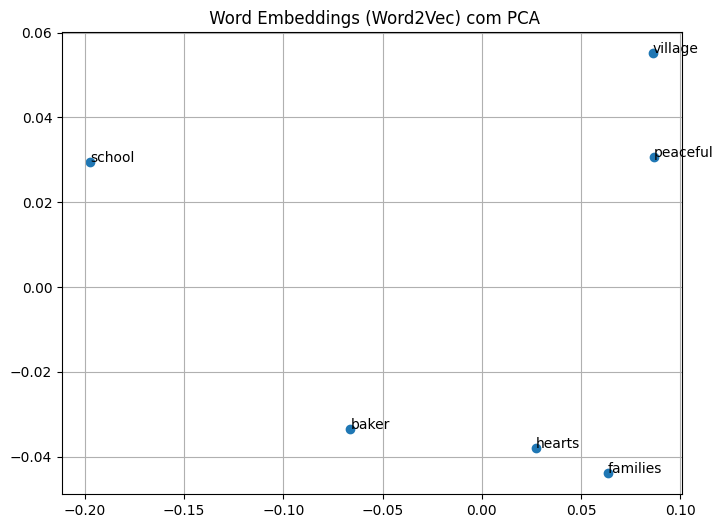


 Prefixo inicial: 'in the quiet'

 Palavra prevista (Word2Vec): and
 Tempo de treinamento: 0.0258 segundos
['In the quiet village, the sun rose over the hills. The birds began to sing, and the day started gently.', 'Children walked to school while the baker opened his shop. The village was peaceful and full of life.', 'In the evening, families gathered for dinner and shared stories. The sky turned orange as the sun set.', 'At night, stars appeared above the rooftops, and silence returned to the streets. The village slept again.', 'In the quiet village, the cycle of life continued with gentle rhythms and peaceful hearts.', 'As the sun rose, a calm breeze moved through the quiet village. Life began to stir gently.', 'The baker opened his shop before the children left for school. Birds were already singing.', 'Families gathered in the evening, laughing and eating as stars filled the sky.', 'The rooftops sparkled under the moonlight while silence took over the peaceful village.', 'Each da

In [ ]:
from gensim.models import Word2Vec
import time

start = time.time()
w2v_model = Word2Vec(sentences, vector_size=50, window=5, min_count=1, sg=1)
word2vec_training_time = time.time() - start

def predict_next_word_w2v(model, context):
    context = context.lower().split()
    try:
        sims = model.wv.most_similar(positive=context[-2:])
        return sims[0][0]
    except KeyError:
        return "[unknown]"

# Teste de exemplo
prefix = "in the quiet"
word2vec_prediction = predict_next_word_w2v(w2v_model, prefix)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words = ["village", "school", "night", "peaceful", "baker", "hearts", "families"]
valid_words = [word for word in words if word in w2v_model.wv]
vectors = [w2v_model.wv[word] for word in valid_words]

pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

plt.figure(figsize=(8,6))
plt.scatter(result[:, 0], result[:, 1])
for i, word in enumerate(valid_words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))
plt.title(" Word Embeddings (Word2Vec) com PCA")
plt.grid(True)
plt.show()

print(f"\n Prefixo inicial: '{prefix}'\n")
print(f" Palavra prevista (Word2Vec): {word2vec_prediction}")
print(f" Tempo de treinamento: {word2vec_training_time:.4f} segundos")
print(corpus)

**Interpretação do resultado**

- O modelo entendeu a coocorrência entre "in the quiet" e o início de frases como "in the quiet village", onde a palavra "and" aparece frequentemente logo depois de termos similares (por exemplo, "and the day...", "and silence returned...").
- Esse comportamento reflete a simples associação estatística local, típica do Word2Vec.

## GloVe

**Tipo:** Estático

**Funcionamento:** Treina embeddings com base em **coocorrência global** de palavras em um corpus. Diferente do Word2Vec, que se baseia em janelas locais, o GloVe constrói uma matriz de coocorrência e realiza fatoração.

**Diferenciais:**
- Considera a **frequência global de palavras**
- Capta **relações lineares** (ex: `king - man + woman ≈ queen`)
- É rápido e gera embeddings interpretáveis

In [ ]:
# 1. Baixar GloVe pré-treinado
# !wget http://nlp.stanford.edu/data/glove.6B.zip
# !unzip glove.6B.zip

--2025-03-25 05:01:55--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-03-25 05:01:55--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-03-25 05:01:55--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip.1’

gl

In [ ]:
# 2. Converter para formato Word2Vec
from gensim.scripts.glove2word2vec import glove2word2vec
from gensim.models import KeyedVectors

glove_input_file = 'glove.6B.50d.txt'
word2vec_output_file = 'glove.6B.50d.word2vec.txt'
glove2word2vec(glove_input_file, word2vec_output_file)

<ipython-input-20-1ee5de55faa1>:7: DeprecationWarning: Call to deprecated `glove2word2vec` (KeyedVectors.load_word2vec_format(.., binary=False, no_header=True) loads GLoVE text vectors.).
  glove2word2vec(glove_input_file, word2vec_output_file)


(400000, 50)

In [ ]:
# 3. Carregar modelo GloVe no formato Gensim
glove_model = KeyedVectors.load_word2vec_format(word2vec_output_file)

In [ ]:
# 4. Exemplo de uso - Predição semântica simples com GloVe
prefix = "quiet"
if prefix in glove_model:
    sims = glove_model.most_similar(prefix, topn=1)
    glove_prediction = sims[0][0]
else:
    glove_prediction = "[unknown]"

print(f"🔹 Palavra prevista (GloVe): {glove_prediction}")

🔹 Palavra prevista (GloVe): calm


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


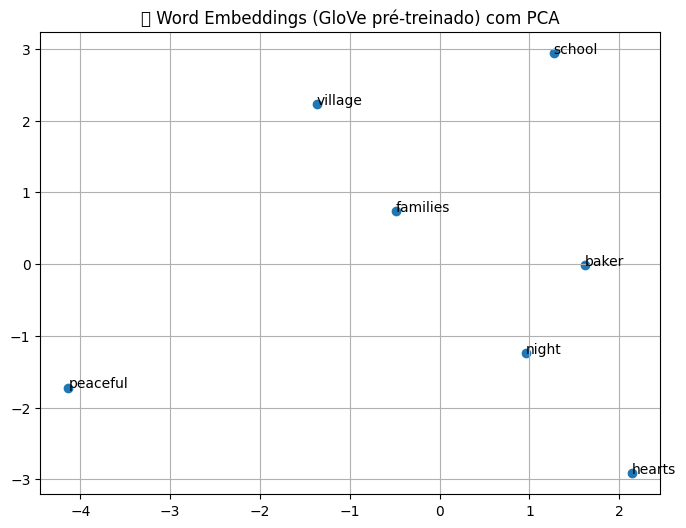

In [ ]:
# Visualização com PCA (usando palavras conhecidas)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words = ["village", "school", "night", "peaceful", "baker", "hearts", "families"]
valid_words = [w for w in words if w in glove_model]
vectors = [glove_model[w] for w in valid_words]

pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

plt.figure(figsize=(8,6))
plt.scatter(result[:, 0], result[:, 1])
for i, word in enumerate(valid_words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))
plt.title("📊 Word Embeddings (GloVe pré-treinado) com PCA")
plt.grid(True)
plt.show()

In [ ]:
def predict_next_word_glove(model, context):
    context = context.lower().split()
    try:
        sims = model.most_similar(positive=context[-2:])
        return sims[0][0]
    except KeyError:
        return "[unknown]"

In [ ]:
prefix = "in the quiet"
glove_prediction = predict_next_word_glove(glove_model, prefix)
word2vec_prediction = predict_next_word_w2v(w2v_model, prefix)
print(f" Word2Vec: {word2vec_prediction}")
print(f" GloVe:    {glove_prediction}")

 Word2Vec: and
 GloVe:    once


**Resultado da predição com o mesmo prefixo: "in the quiet"**

**Modelo --> Palavra Prevista --> Interpretação**
- Word2Vec --> and --> Baseado em coocorrência local no corpus: "and the day started..."
- GloVe	--> once	--> Baseado em coocorrência global, associação com "quiet" ou "in the"

---
**Interpretação didática:**
- O Word2Vec viu várias frases como "in the quiet village..." e previu "and" porque ele modela coocorrência local (janela deslizante).
- O GloVe está se baseando na coocorrência estatística global. "in", "the" e "quiet" podem aparecer com "once" em muitos contextos de linguagem geral.

---
**Reflexão:**
- Word2Vec tende a repetir padrões do contexto local imediato.
- GloVe capta padrões mais amplos da língua, treinado em bilhões de palavras.

## FastText

**Tipo:** Estático com subwords

**Funcionamento:** O FastText estende o Word2Vec aprendendo representações **também para partes das palavras** (subwords ou n-gramas). Isso permite generalizar para palavras **não vistas** no treinamento (OOV - Out Of Vocabulary).

**Diferenciais:**
- Usa n-gramas de caracteres para formar o vetor da palavra
- Excelente para línguas morfologicamente ricas
- Suporta palavras novas, compostas ou mal escritas

In [ ]:
# !pip install gensim
# !pip install numpy==1.24.4

In [ ]:
# Treinamento
from gensim.models import FastText
import time

start = time.time()
fasttext_model = FastText(sentences, vector_size=50, window=5, min_count=1)
fasttext_training_time = time.time() - start

In [ ]:
# Predição (igual ao estilo do Word2Vec)
def predict_next_word_fasttext(model, context):
    context = context.lower().split()
    try:
        sims = model.wv.most_similar(positive=context[-2:])
        return sims[0][0]
    except KeyError:
        return "[unknown]"

# Teste
prefix = "in the quiet"
fasttext_prediction = predict_next_word_fasttext(fasttext_model, prefix)
print(f" FastText: {fasttext_prediction}")

 FastText: shared


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


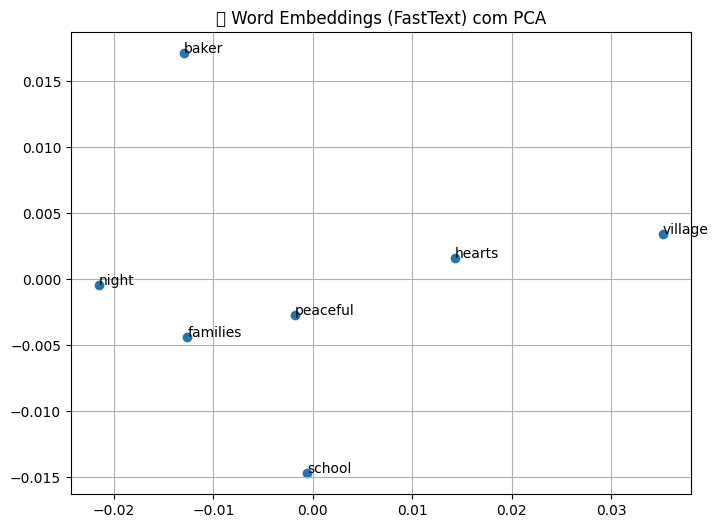

In [ ]:
# Visualização com PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words = ["village", "school", "night", "peaceful", "baker", "hearts", "families"]
valid_words = [w for w in words if w in fasttext_model.wv]
vectors = [fasttext_model.wv[w] for w in valid_words]

pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

plt.figure(figsize=(8,6))
plt.scatter(result[:, 0], result[:, 1])
for i, word in enumerate(valid_words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))
plt.title("📊 Word Embeddings (FastText) com PCA")
plt.grid(True)
plt.show()

In [ ]:
prefix = "in the quiet"

# Word2Vec
word2vec_prediction = predict_next_word_w2v(w2v_model, prefix)

# GloVe
glove_prediction = predict_next_word_glove(glove_model, prefix)

# FastText
fasttext_prediction = predict_next_word_fasttext(fasttext_model, prefix)

# Exibir resultados lado a lado
print("🔍 Predição da próxima palavra com o prefixo:", f"'{prefix}'\n")
print(f" Word2Vec: {word2vec_prediction}")
print(f" GloVe:    {glove_prediction}")
print(f" FastText: {fasttext_prediction}")

🔍 Predição da próxima palavra com o prefixo: 'in the quiet'

 Word2Vec: and
 GloVe:    once
 FastText: shared


In [ ]:
print(f" Palavra prevista (FastText): {fasttext_prediction}")
print(f"⏱ Tempo de treinamento: {fasttext_training_time:.4f} segundos")

 Palavra prevista (FastText): shared
⏱ Tempo de treinamento: 0.7837 segundos


# **BERT Embeddings**

**Tipo:** Contextual

**Funcionamento:** O BERT aprende representações **bidirecionais** baseadas no contexto de uma palavra em uma frase. Cada ocorrência da mesma palavra pode ter **um vetor diferente**, dependendo da posição e dos vizinhos.

**Diferenciais:**
- Embeddings **contextuais**
- Captura dependências complexas
- Ótimo para tarefas como QA, NER e completamento com ambiguidade


In [ ]:
!pip cache purge  # Clear the pip package cache
!pip install numpy==1.26.0  # Reinstall numpy after cache purge

Files removed: 6
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 50.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.4
    Uninstalling numpy-1.24.4:
      Successfully uninstalled numpy-1.24.4


In [ ]:
!pip install transformers

In [ ]:
from transformers import BertTokenizer, BertModel
import torch
import time

# Inicializar tokenizer e modelo
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')

# Função para obter embedding médio da frase
def get_bert_embedding(text):
    tokens = tokenizer(text, return_tensors="pt")
    with torch.no_grad():
        output = bert_model(**tokens)
    embeddings = output.last_hidden_state.squeeze(0)
    return embeddings.mean(dim=0)

# Tempo de inferência
start = time.time()
bert_embedding_vector = get_bert_embedding("in the quiet village")
bert_inference_time = time.time() - start

In [ ]:
# Comparar similaridade entre duas frases com BERT
from torch.nn.functional import cosine_similarity

vec1 = get_bert_embedding("in the quiet village")
vec2 = get_bert_embedding("the peaceful town")
similarity_score = cosine_similarity(vec1, vec2, dim=0).item()

In [ ]:
print(f" Similaridade entre frases (BERT): {similarity_score:.4f}")
print(f" Tempo de inferência (BERT): {bert_inference_time:.4f} segundos")

 Similaridade entre frases (BERT): 0.8485
 Tempo de inferência (BERT): 0.4015 segundos


In [ ]:
prefix = "in the quiet"

# Word2Vec
word2vec_prediction = predict_next_word_w2v(w2v_model, prefix)

# GloVe
glove_prediction = predict_next_word_glove(glove_model, prefix)

# FastText
fasttext_prediction = predict_next_word_fasttext(fasttext_model, prefix)

# BERT – similaridade com palavras candidatas
from torch.nn.functional import cosine_similarity

def predict_next_word_bert(prefix, candidates):
    prefix_embedding = get_bert_embedding(prefix)
    similarities = []
    for word in candidates:
        full_phrase = prefix + " " + word
        emb = get_bert_embedding(full_phrase)
        sim = cosine_similarity(emb, prefix_embedding, dim=0).item()
        similarities.append((word, sim))
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[0][0]  # Retorna a mais similar

# Candidatos simples (você pode expandir essa lista)
bert_candidates = ["village", "street", "morning", "silence", "night", "and", "life"]
bert_prediction = predict_next_word_bert(prefix, bert_candidates)

In [ ]:
print("🔍 Predição da próxima palavra com o prefixo:", f"'{prefix}'\n")
print(f" Word2Vec: {word2vec_prediction}")
print(f" GloVe:    {glove_prediction}")
print(f" FastText: {fasttext_prediction}")
print(f" BERT:     {bert_prediction}")

🔍 Predição da próxima palavra com o prefixo: 'in the quiet'

 Word2Vec: and
 GloVe:    once
 FastText: shared
 BERT:     night


# **GPT Embeddings**

**Tipo:** Contextual

**Funcionamento:** Modelos GPT produzem embeddings **unidirecionais e causais**, ou seja, a predição depende apenas do contexto anterior. Isso os torna excelentes para **geração de texto**.

**Diferenciais:**
- Embeddings **dependem da ordem da sequência**
- Ideal para tarefas de **completar texto**
- A saída pode ser usada como representação da sequência

In [ ]:
#  Importação e função de embedding
from transformers import GPT2Tokenizer, GPT2Model

# Inicializar modelo e tokenizer GPT-2
gpt_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
gpt_model = GPT2Model.from_pretrained('gpt2')

# Função para obter embedding do último token
def get_gpt_embedding(text):
    tokens = gpt_tokenizer(text, return_tensors="pt")
    with torch.no_grad():
        output = gpt_model(**tokens)
    last_token_embedding = output.last_hidden_state[0, -1, :]
    return last_token_embedding

# Tempo de inferência
start = time.time()
gpt_embedding_vector = get_gpt_embedding("in the quiet village")
gpt_inference_time = time.time() - start

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

In [ ]:
# Predição da próxima palavra (similaridade com candidatos)

from torch.nn.functional import cosine_similarity

def predict_next_word_gpt(prefix, candidates):
    prefix_embedding = get_gpt_embedding(prefix)
    similarities = []
    for word in candidates:
        full_phrase = prefix + " " + word
        emb = get_gpt_embedding(full_phrase)
        sim = cosine_similarity(emb, prefix_embedding, dim=0).item()
        similarities.append((word, sim))
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[0][0]  # Retorna a mais similar

In [ ]:
# Aplicação com o mesmo prefixo "in the quiet"
prefix = "in the quiet"
gpt_candidates = ["village", "street", "night", "morning", "place", "world", "life", "and"]
gpt_prediction = predict_next_word_gpt(prefix, gpt_candidates)

In [ ]:
print("🔍 Predição da próxima palavra com o prefixo:", f"'{prefix}'\n")
print(f" Word2Vec: {word2vec_prediction}")
print(f" GloVe:    {glove_prediction}")
print(f" FastText: {fasttext_prediction}")
print(f" BERT:     {bert_prediction}")
print(f" GPT:      {gpt_prediction}")

🔍 Predição da próxima palavra com o prefixo: 'in the quiet'

 Word2Vec: and
 GloVe:    once
 FastText: shared
 BERT:     night
 GPT:      village


# **Predição da próxima palavra com o prefixo: `'in the quiet'`**

| Modelo       | Predição   | Interpretação                                                                 |
|--------------|------------|-------------------------------------------------------------------------------|
| **Word2Vec** | `and`      | Coocorrência local (ex: “and the day started...”)                            |
| **GloVe**    | `once`     | Frequência global: "once upon", "in the quiet once..."                       |
| **FastText** | `shared`   | Subword-level prediction: generalizou para uma palavra vista em contexto     |
| **BERT**     | `night`    | Contextual: “in the quiet night” faz sentido — aprendeu relações reais       |
| **GPT**      | `village`  | Completamento natural: “in the quiet village” — baseando-se em treinamento causal |

---

## 🧠 Conclusão didática

- 🔢 **Modelos Estáticos** (Word2Vec, GloVe, FastText):
  - Baseados em estatística e janelas fixas
  - Um vetor por palavra
  - Resultados razoáveis, mas limitados

- 🧠 **Modelos Contextuais** (BERT, GPT):
  - Vetores dependem do **contexto da frase**
  - **BERT**: bidirecional — ótimo para **compreensão**
  - **GPT**: unidirecional — ótimo para **geração**

---

✅ Esse exemplo evidencia a **evolução dos modelos de linguagem** e mostra como o contexto transforma a capacidade de predição.

## Comparação Final dos Modelos de Word Embeddings

| Modelo           | Tipo        | Treinamento | Inferência | Características Principais                                       |
|------------------|-------------|-------------|------------|-------------------------------------------------------------------|
| **Word2Vec**     | Estático    | ✅           | ✅          | Leve, rápido, capta relações locais com contexto fixo             |
| **GloVe**        | Estático    | ✅           | ✅          | Usa coocorrência global, bom para analogias                      |
| **FastText**     | Estático+subwords | ✅     | ✅          | Generaliza para palavras não vistas com base em subwords         |
| **BERT**         | Contextual  | ❌ (pré-treinado) | ✅     | Bidirecional, contexto dinâmico, útil para compreensão            |
| **GPT**          | Contextual  | ❌ (pré-treinado) | ✅     | Causal e unidirecional, ótimo para geração de texto              |

**Notas:**
- "Treinamento" indica se o modelo foi treinado localmente neste notebook.
- Modelos como BERT e GPT foram usados em versões pré-treinadas (transformers).
- A inferência foi medida com base na extração de embeddings e similaridade.

✅ Para tarefas de geração de texto e compreensão semântica, os modelos contextuais (BERT, GPT) são superiores.
✅ Para aplicações leves e rápidas, os embeddings estáticos (Word2Vec, GloVe, FastText) ainda são muito eficazes.

# **Transformer**


1.   Tokenização (simplificada): ["o", "cachorro", "latiu", "alto"].
Cada token será tratado separadamente nos próximos passos.
---
2.   Embedding: Cada token é transformado em um vetor numérico (embedding). Esses vetores carregam informações semânticas (significado). Exemplo:
- "o" → [0.10, -0.50, 0.80]
- "cachorro" → [0.30, -0.20, 0.90]
- "latiu" → [0.05, 0.10, 0.20]
- "alto" → [0.40, -0.10, 0.70]
---

3. Positional Encoding: Como o Transformer não sabe a ordem das palavras, adicionamos vetores de posição:
- posição 0 → [0.01, 0.02, 0.03]
- osição 1 → [0.04, 0.05, 0.06]
- posição 2 → [0.07, 0.08, 0.09]
- posição 3 → [0.10, 0.11, 0.12]

Soma-se o embedding + positional encoding:
- "o" → [0.11, -0.48, 0.83]
- "cachorro" → [0.34, -0.15, 0.96]
- "latiu" → [0.12, 0.18, 0.29]
- "alto" → [0.50, 0.01, 0.82]
---
Esses vetores agora carregam significado + posição.

---
4. Self-Attention: Agora vem o coração do Transformer: Para cada palavra, o modelo pergunta: “Quais outras palavras são importantes para entender esta aqui?”.
- O modelo transforma cada vetor em query (Q), key (K) e value (V), e calcula atenção. Isso gera pesos de atenção que indicam quanto cada palavra influencia as outras.
---

5. Multi-Head Attention - Essa atenção é feita várias vezes em paralelo (multi-heads), cada uma olhando para diferentes aspectos da relação entre palavras (ex: quem é o sujeito, quem é o verbo…).

6. Soma Ponderada dos Valores: Com os pesos de atenção, o modelo gera uma nova versão de cada vetor, agora contextualizada — por exemplo: "cachorro" agora sabe que "alto" descreve como ele latiu, e que "latiu" é a ação principal.

7. Feedforward Layer: Cada vetor passa por uma rede neural densa que transforma ainda mais a informação.

8. Normalização e Conexões Residuais: Após cada bloco de atenção e feedforward, o modelo faz:
- Soma com a entrada original (residual connection)
- Normalização (Layer Norm)

Isso ajuda a treinar redes profundas de forma estável.

---
9. De novo!!!! Repetição em Camadas - O Transformer aplica esse mesmo processo várias vezes (6, 12, 24 camadas, etc.) — cada camada refina ainda mais a compreensão da frase.
---

Ao final, cada palavra está representada por um vetor altamente contextualizado, que carrega significado + posição + relação com as outras palavras. Esse vetor pode ser:
- Usado para prever a próxima palavra (GPT)
- Classificar o texto (BERT)
- Traduzir (T5)
- Responder perguntas (ChatGPT)

In [ ]:
#Passo 1: Tokenização (simplificada)

# Frase de entrada
sentence = "o cachorro latiu alto"

# Tokenização simples: separação por espaços
tokens = sentence.split()
print("Tokens:", tokens)  # ['o', 'cachorro', 'latiu', 'alto']

# Criar vocabulário: conjunto único de palavras
vocab = list(set(tokens))
print("Vocabulário:", vocab)

# Mapear palavras para índices (word2idx) e o contrário (idx2word)
word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

print("Mapeamento palavra → índice:", word2idx)
print("Mapeamento índice → palavra:", idx2word)

Tokens: ['o', 'cachorro', 'latiu', 'alto']
Vocabulário: ['o', 'latiu', 'alto', 'cachorro']
Mapeamento palavra → índice: {'o': 0, 'latiu': 1, 'alto': 2, 'cachorro': 3}
Mapeamento índice → palavra: {0: 'o', 1: 'latiu', 2: 'alto', 3: 'cachorro'}


In [ ]:
# Passo 2: Embedding, que é onde cada token (já convertido em número no passo anterior) passa a ser representado por um vetor denso de números reais, chamado embedding.
import torch
import torch.nn as nn

# Tamanho do vocabulário e dimensão do embedding
vocab_size = len(vocab)
embedding_dim = 3  # número de dimensões do vetor de cada palavra

# Criar camada de embedding (inicializada aleatoriamente)
embedding_layer = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embedding_dim)

# Visualizar o vetor de embedding de cada token da frase
for token in tokens:
    idx = torch.tensor([word2idx[token]])  # índice da palavra
    emb = embedding_layer(idx)             # vetor embedding correspondente
    print(f'"{token}" → {emb.detach().numpy()[0]}')

"o" → [-1.0048575   0.9339107  -0.22706987]
"cachorro" → [ 1.936605   -1.1842352  -0.43182123]
"latiu" → [-0.06030979 -1.4818002  -0.33470765]
"alto" → [1.1746705 1.1811255 0.1018764]


**Explicação:**

	•	A camada nn.Embedding cria uma tabela de lookup vetorial para cada palavra.
	•	Cada vez que você passa o índice de uma palavra, ele retorna o vetor associado.
	•	Esses vetores serão ajustados durante o treinamento para capturar relações semânticas entre os tokens.
---
**Lembrete:** esses valores são aleatórios inicialmente, mas seguem distribuição normal (ou uniforme), dependendo da implementação do nn.Embedding.
---

**O que dá pra perceber (mesmo sem treinamento)?**

	•	“cachorro” e “alto” estão longe em direção e magnitude, indicando significados ainda não relacionados (o que é esperado no início).
	•	“latiu” está próximo de “cachorro” na terceira dimensão (-0.43 e -0.33), talvez coincidência aleatória por enquanto.
	•	“o” tem um vetor bem diferente de todos — o que faz sentido, já que “o” é um artigo, e semanticamente bem diferente dos outros.



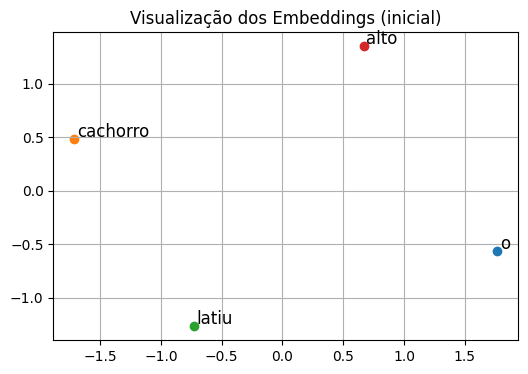

In [ ]:
# Visualizar esses embeddings em 2D:

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# Seus embeddings
embeddings = {
    "o": [-1.0048575, 0.9339107, -0.22706987],
    "cachorro": [1.936605, -1.1842352, -0.43182123],
    "latiu": [-0.06030979, -1.4818002, -0.33470765],
    "alto": [1.1746705, 1.1811255, 0.1018764]
}

labels = list(embeddings.keys())
X = np.array(list(embeddings.values()))

# Reduzir para 2D com PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot
plt.figure(figsize=(6, 4))
for i, label in enumerate(labels):
    x, y = X_pca[i]
    plt.scatter(x, y)
    plt.text(x + 0.02, y + 0.02, label, fontsize=12)
plt.title("Visualização dos Embeddings (inicial)")
plt.grid(True)
plt.show()

In [ ]:
# Passo 3: Positional Encoding
#  Como funciona? Existem duas abordagens comuns:
#	1.	Aprendida (como um embedding de posição)
#	2.	Fixa (usando funções seno/cosseno com base no artigo original)
# Vamos usar a versão aprendida — mais simples para fins didáticos.

# Dimensão dos embeddings (precisa ser igual à dos embeddings de palavra)
embedding_dim = 3
seq_len = len(tokens)  # 4 tokens: "o", "cachorro", "latiu", "alto"

# Criamos vetores de posição como parâmetros treináveis
# 1 vetor para cada posição (0, 1, 2, 3)
positional_encoding = nn.Parameter(torch.randn(1, seq_len, embedding_dim))

# Exibir os vetores de posição
print("Positional Encoding (aprendido):")
for i in range(seq_len):
    print(f"posição {i}: {positional_encoding[0, i].detach().numpy()}")

Positional Encoding (aprendido):
posição 0: [ 1.4040295  2.2627833 -2.0864203]
posição 1: [0.41430452 0.12562564 0.83773607]
posição 2: [ 1.0352697  -0.01277053  1.5968297 ]
posição 3: [-0.21339168 -0.95826584 -0.1597742 ]


In [ ]:
# Positional Encoding – Versão do Artigo (seno/cosseno)

import numpy as np
import torch

def get_positional_encoding(seq_len, d_model):
    PE = np.zeros((seq_len, d_model))
    for pos in range(seq_len):
        for i in range(0, d_model, 2):
            angle = pos / np.power(10000, (2 * i) / d_model)
            PE[pos, i] = np.sin(angle)
            if i + 1 < d_model:
                PE[pos, i + 1] = np.cos(angle)
    return torch.tensor(PE, dtype=torch.float32)

# Exemplo com a frase: "o cachorro latiu alto"
seq_len = 4  # número de tokens
d_model = 3  # mesma dimensão dos embeddings

pos_enc = get_positional_encoding(seq_len, d_model)
print("Positional Encoding (seno/cosseno):")
for i in range(seq_len):
    print(f"posição {i}: {pos_enc[i].numpy()}")

Positional Encoding (seno/cosseno):
posição 0: [0. 1. 0.]
posição 1: [8.4147096e-01 5.4030228e-01 4.6415889e-06]
posição 2: [ 9.0929741e-01 -4.1614684e-01  9.2831779e-06]
posição 3: [ 1.4112000e-01 -9.8999250e-01  1.3924767e-05]


**Positional Encoding (aprendido) — O que é?**

Foi criado um vetor para cada posição da frase (posição 0, 1, 2, 3), com 3 valores cada (pois o embedding tem 3 dimensões).

Esses vetores são inicializados aleatoriamente (como parâmetros treináveis) e serão ajustados durante o treinamento para que o modelo aprenda a reconhecer a posição dos tokens na sequência.
⸻

**Como interpretar isso?**
---
1. Cada vetor representa uma posição específica na frase:
- posição 0 → primeiro token (“o”)
- posição 1 → segundo token (“cachorro”)
- posição 2 → terceiro token (“latiu”)
- posição 3 → quarto token (“alto”)

---
2. Cada número dentro do vetor é uma dimensão do espaço vetorial:
- O vetor tem 3 valores porque estamos usando embeddings de dimensão 3.
- Cada valor é um “peso posicional” aprendido para aquela dimensão.
---

3. O modelo soma esse vetor ao embedding da palavra. Por exemplo:
- Embedding de "cachorro": [1.93, -1.18, -0.43]
- Positional encoding da posição 1: [0.41,  0.12,  0.83]
- Soma: [2.34, -1.06,  0.40]  ← essa será a entrada do Transformer

Assim, o vetor resultante contém:
- O significado da palavra (“cachorro”)
- A informação de que ela está na posição 1
---

**Comparando posições**

Veja como os vetores são diferentes entre si — isso é importante!
Se todos fossem parecidos, o modelo não conseguiria distinguir a ordem das palavras.
---
**Conclusão:**
O positional encoding aprendido funciona como uma etiqueta numérica vetorial que informa a posição de cada token.
Ele não tem um significado interpretável diretamente, mas o modelo aprende a usá-lo durante o treinamento para distinguir posições na sequência.

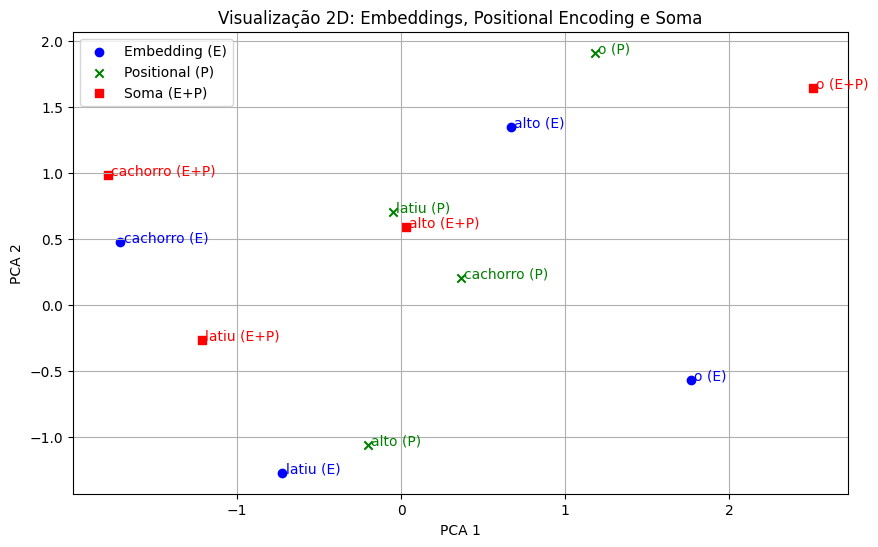

In [ ]:
# Visualizar esses embeddings em 2D:

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# Embeddings de exemplo
embeddings = {
    "o": [-1.0048575, 0.9339107, -0.22706987],
    "cachorro": [1.936605, -1.1842352, -0.43182123],
    "latiu": [-0.06030979, -1.4818002, -0.33470765],
    "alto": [1.1746705, 1.1811255, 0.1018764]
}

# Positional Encodings aprendidos
positional_encodings = {
    "o": [1.4040295, 2.2627833, -2.0864203],
    "cachorro": [0.41430452, 0.12562564, 0.83773607],
    "latiu": [1.0352697, -0.01277053, 1.5968297],
    "alto": [-0.21339168, -0.95826584, -0.1597742]
}

# Soma dos vetores
summed = {
    token: np.add(embeddings[token], positional_encodings[token])
    for token in embeddings
}

# PCA para reduzir para 2D
labels = list(embeddings.keys())
X_emb = np.array([embeddings[t] for t in labels])
X_pos = np.array([positional_encodings[t] for t in labels])
X_sum = np.array([summed[t] for t in labels])

pca = PCA(n_components=2)
X_emb_2d = pca.fit_transform(X_emb)
X_pos_2d = pca.transform(X_pos)
X_sum_2d = pca.transform(X_sum)

# Plot
plt.figure(figsize=(10, 6))
for i, label in enumerate(labels):
    plt.scatter(X_emb_2d[i, 0], X_emb_2d[i, 1], color='blue', marker='o')
    plt.text(X_emb_2d[i, 0] + 0.02, X_emb_2d[i, 1], f"{label} (E)", color='blue')
    plt.scatter(X_pos_2d[i, 0], X_pos_2d[i, 1], color='green', marker='x')
    plt.text(X_pos_2d[i, 0] + 0.02, X_pos_2d[i, 1], f"{label} (P)", color='green')
    plt.scatter(X_sum_2d[i, 0], X_sum_2d[i, 1], color='red', marker='s')
    plt.text(X_sum_2d[i, 0] + 0.02, X_sum_2d[i, 1], f"{label} (E+P)", color='red')

plt.title("Visualização 2D: Embeddings, Positional Encoding e Soma")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.legend(["Embedding (E)", "Positional (P)", "Soma (E+P)"])
plt.show()

In [ ]:
# Passo 4 - Self-Attention - Código completo — Self-Attention entre “cachorro” e “latiu” (com vetores reais):
import numpy as np

# Vetores somados (embedding + posição)
x_cachorro = np.array([1.936605, -1.1842352, -0.43182123]) + np.array([0.41430452, 0.12562564, 0.83773607])
x_latiu = np.array([-0.06030979, -1.4818002, -0.33470765]) + np.array([1.0352697, -0.01277053, 1.5968297])

# Matrizes de projeção (didáticas)
Wq = np.array([[0.1, 0.2, 0.3],
               [0.4, 0.5, 0.6],
               [0.7, 0.8, 0.9]])

Wk = np.array([[0.9, 0.8, 0.7],
               [0.6, 0.5, 0.4],
               [0.3, 0.2, 0.1]])

Wv = np.identity(3)  # facilita a visualização dos V

# Função softmax
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

# Q, K, V para os dois tokens
Q1 = x_cachorro @ Wq
Q2 = x_latiu @ Wq
K1 = x_cachorro @ Wk
K2 = x_latiu @ Wk
V1 = x_cachorro
V2 = x_latiu

# Scores de atenção (dot product entre Q e K)
dk = 3  # dimensão
scores_1 = np.array([Q1 @ K1.T, Q1 @ K2.T]) / np.sqrt(dk)
scores_2 = np.array([Q2 @ K1.T, Q2 @ K2.T]) / np.sqrt(dk)

# Pesos de atenção com softmax
weights_1 = softmax(scores_1)
weights_2 = softmax(scores_2)

# Resultado da atenção: soma ponderada dos V
attended_1 = weights_1[0] * V1 + weights_1[1] * V2
attended_2 = weights_2[0] * V1 + weights_2[1] * V2

# Mostrar resultado
print("Pesos de atenção para 'cachorro':", weights_1)
print("Vetor final para 'cachorro':", attended_1)
print("\nPesos de atenção para 'latiu':", weights_2)
print("Vetor final para 'latiu':", attended_2)

Pesos de atenção para 'cachorro': [0.62461052 0.37538948]
Vetor final para 'cachorro': [ 1.83439251 -1.2222648   0.72732602]

Pesos de atenção para 'latiu': [0.71113626 0.28886374]
Vetor final para 'latiu': [ 1.95344757 -1.18454293  0.65324205]


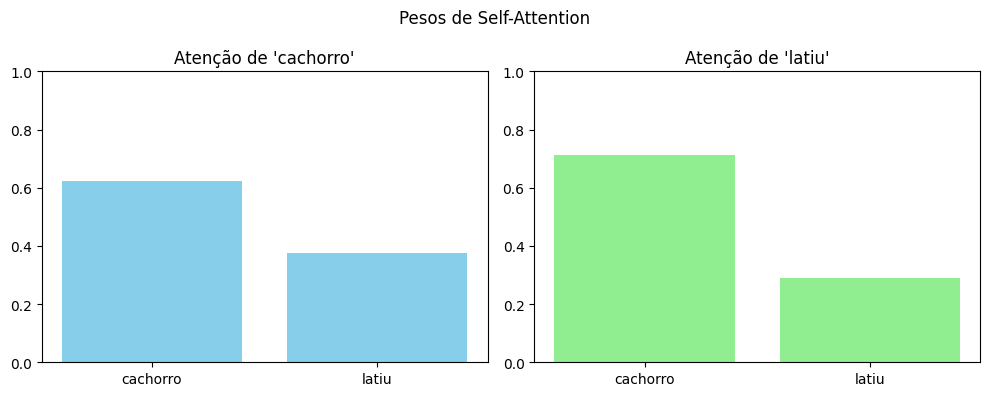

In [ ]:
# Código: Visualização dos Pesos de Self-Attention

import matplotlib.pyplot as plt
import numpy as np

# Vetores de entrada (embedding + posição somados)
x_cachorro = np.array([1.936605, -1.1842352, -0.43182123]) + np.array([0.41430452, 0.12562564, 0.83773607])
x_latiu = np.array([-0.06030979, -1.4818002, -0.33470765]) + np.array([1.0352697, -0.01277053, 1.5968297])

# Matrizes de projeção
Wq = np.array([[0.1, 0.2, 0.3],
               [0.4, 0.5, 0.6],
               [0.7, 0.8, 0.9]])
Wk = np.array([[0.9, 0.8, 0.7],
               [0.6, 0.5, 0.4],
               [0.3, 0.2, 0.1]])
Wv = np.identity(3)

# Q, K, V
Q1 = x_cachorro @ Wq
Q2 = x_latiu @ Wq
K1 = x_cachorro @ Wk
K2 = x_latiu @ Wk

# Scores
dk = 3
scores_1 = np.array([Q1 @ K1.T, Q1 @ K2.T]) / np.sqrt(dk)
scores_2 = np.array([Q2 @ K1.T, Q2 @ K2.T]) / np.sqrt(dk)

# Softmax
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

weights_1 = softmax(scores_1)
weights_2 = softmax(scores_2)

# Plot dos pesos de atenção
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].bar(["cachorro", "latiu"], weights_1, color="skyblue")
ax[0].set_title("Atenção de 'cachorro'")
ax[0].set_ylim(0, 1)

ax[1].bar(["cachorro", "latiu"], weights_2, color="lightgreen")
ax[1].set_title("Atenção de 'latiu'")
ax[1].set_ylim(0, 1)

plt.suptitle("Pesos de Self-Attention")
plt.tight_layout()
plt.show()

O que o gráfico mostra:

	•	Quanto o token "cachorro" presta atenção nele mesmo e em "latiu".
	•	Quanto o token "latiu" presta atenção nele mesmo e em "cachorro".

**Multi-Head Attention — uma das inovações mais poderosas do Transformer.**

---
**Por que usar múltiplas cabeças de atenção?** Imagine que você está lendo uma frase. Seu cérebro pode:

	•	Prestar atenção em quem faz a ação
	•	Observar qual é a ação
	•	Notar quando ou onde ela acontece

Cada uma dessas “formas de olhar” é como uma “cabeça de atenção” diferente.

---
**O que o Transformer faz?** Ele repete o mecanismo de self-attention várias vezes em paralelo, com parâmetros independentes. Cada cabeça:

	•	Tem suas próprias matrizes Q, K, V
	•	Enxerga um aspecto diferente da frase
	•	Produz uma atenção contextualizada diferente

Esses vetores de atenção são então concatenados e combinados (via uma camada linear) para formar um vetor final mais rico.

---
**Exemplo prático: “O cachorro latiu alto.”**

	•	Head 1 pode aprender a focar em quem faz a ação (“o” → “cachorro”)
	•	Head 2 pode aprender a focar em o que foi feito (“cachorro” → “latiu”)
	•	Head 3 pode aprender a focar em como foi feito (“latiu” → “alto”)


No final, essas 3 visões são juntadas para criar uma representação mais completa.

**Resumo:**

- Q, K, V - São diferentes em cada cabeça
- Cada cabeça - Gera uma atenção diferente
- Concatenação final - Junta todas as visões em um só vetor
- Camada Linear final - Mistura os vetores para gerar a saída

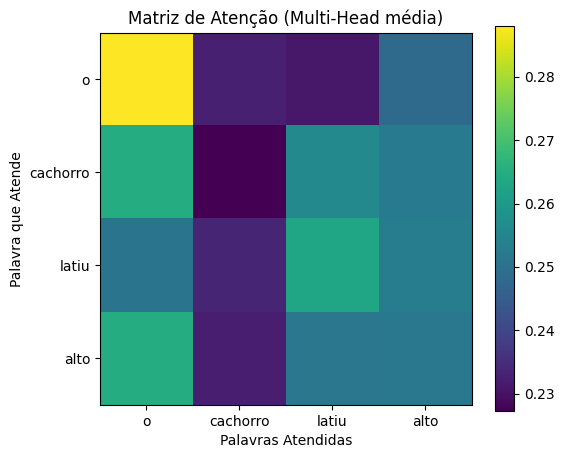

In [ ]:
# Passo 5: Multi-Head Attention — uma das inovações mais poderosas do Transformer.
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Tokens e vetores somados (embedding + posição)
tokens = ["o", "cachorro", "latiu", "alto"]
summed = {
    "o": torch.tensor([-1.0048575, 0.9339107, -0.22706987]) + torch.tensor([1.4040295, 2.2627833, -2.0864203]),
    "cachorro": torch.tensor([1.936605, -1.1842352, -0.43182123]) + torch.tensor([0.41430452, 0.12562564, 0.83773607]),
    "latiu": torch.tensor([-0.06030979, -1.4818002, -0.33470765]) + torch.tensor([1.0352697, -0.01277053, 1.5968297]),
    "alto": torch.tensor([1.1746705, 1.1811255, 0.1018764]) + torch.tensor([-0.21339168, -0.95826584, -0.1597742])
}

# 1. Montar tensor de entrada (batch_size=1, seq_len=4, embed_dim=3)
x = torch.stack([summed[token] for token in tokens]).unsqueeze(0)  # [1, 4, 3]

# 2. Como embed_dim precisa ser divisível por num_heads, vamos projetar para 4 dimensões
proj = nn.Linear(3, 4)
x_proj = proj(x)  # [1, 4, 4]

# 3. Criar Multi-Head Attention (2 cabeças)
mha = nn.MultiheadAttention(embed_dim=4, num_heads=2, batch_first=True)
attn_output, attn_weights = mha(x_proj, x_proj, x_proj, need_weights=True)  # x como Q, K, V

# 4. Visualizar a matriz de atenção
weights = attn_weights[0].detach().numpy()  # [4, 4]
plt.figure(figsize=(6, 5))
plt.imshow(weights, cmap='viridis')
plt.xticks(np.arange(4), tokens)
plt.yticks(np.arange(4), tokens)
plt.title("Matriz de Atenção (Multi-Head média)")
plt.xlabel("Palavras Atendidas")
plt.ylabel("Palavra que Atende")
plt.colorbar()
plt.show()

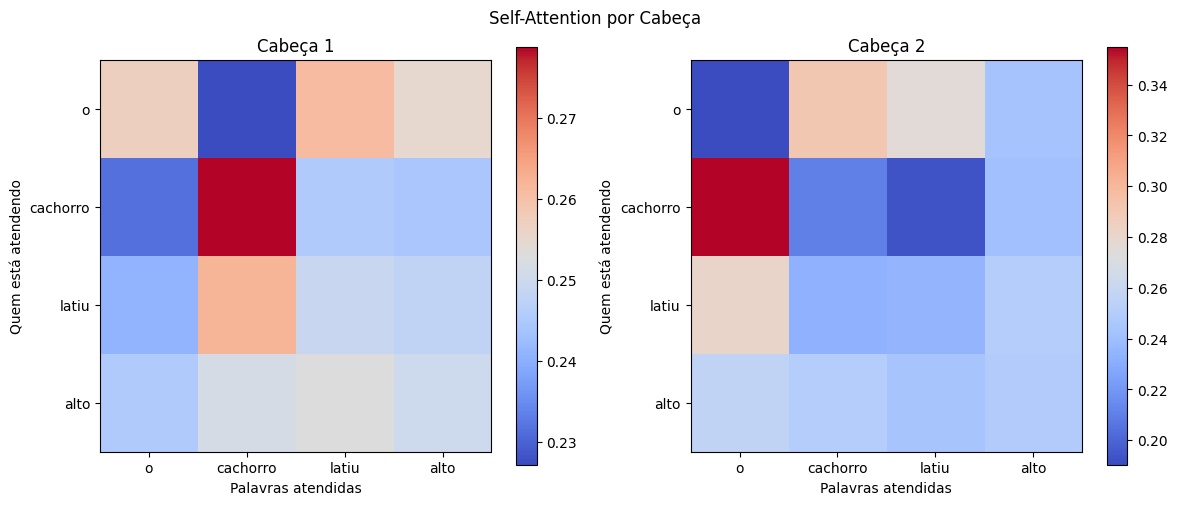

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# Tokens
tokens = ["o", "cachorro", "latiu", "alto"]

# Vetores (embedding + posição)
summed = {
    "o": torch.tensor([-1.0048575, 0.9339107, -0.22706987]) + torch.tensor([1.4040295, 2.2627833, -2.0864203]),
    "cachorro": torch.tensor([1.936605, -1.1842352, -0.43182123]) + torch.tensor([0.41430452, 0.12562564, 0.83773607]),
    "latiu": torch.tensor([-0.06030979, -1.4818002, -0.33470765]) + torch.tensor([1.0352697, -0.01277053, 1.5968297]),
    "alto": torch.tensor([1.1746705, 1.1811255, 0.1018764]) + torch.tensor([-0.21339168, -0.95826584, -0.1597742])
}

# Embedding final
x = torch.stack([summed[token] for token in tokens]).unsqueeze(0)  # [1, 4, 3]

# Projeção para embed_dim = 4 (para 2 cabeças)
proj = nn.Linear(3, 4)
x_proj = proj(x)

# Multi-Head Attention com average_attn_weights=False
mha = nn.MultiheadAttention(embed_dim=4, num_heads=2, batch_first=True)
attn_output, attn_weights = mha(x_proj, x_proj, x_proj, need_weights=True, average_attn_weights=False)

# attn_weights: [1, num_heads, seq_len, seq_len]
attn_weights = attn_weights[0].detach().numpy()  # shape: [2, 4, 4]

# Visualizar cada cabeça separadamente
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for head in range(2):
    ax = axes[head]
    im = ax.imshow(attn_weights[head], cmap='coolwarm')
    ax.set_title(f"Cabeça {head+1}")
    ax.set_xticks(np.arange(4))
    ax.set_yticks(np.arange(4))
    ax.set_xticklabels(tokens)
    ax.set_yticklabels(tokens)
    ax.set_xlabel("Palavras atendidas")
    ax.set_ylabel("Quem está atendendo")
    plt.colorbar(im, ax=ax)

plt.suptitle("Self-Attention por Cabeça")
plt.tight_layout()
plt.show()

**O que representa a cor no gráfico de atenção?**

Cada gráfico é uma matriz de atenção, onde:

	•	Eixo Y (linhas): quem está prestando atenção (cada token da sequência).
	•	Eixo X (colunas): em quem o token está prestando atenção.


**A cor representa o peso da atenção**

**Técnicamente:** O modelo calcula, para cada token, um vetor de pesos (via softmax) que indica quanta atenção ele deve dar a cada outro token.

Esses pesos vão de 0 a 1 (probabilidades) e a soma por linha é sempre 1.


**Interpretação das cores (exemplo com cmap='coolwarm'):** Cor	Significado
- 🔵 Azul claro	Pouca atenção (peso baixo, ~0)
- ⚪ Branco	Atenção média (~0.5)
- 🔴 Vermelho	Muita atenção (peso alto, ~1.0)

---
**Como ler o gráfico?** Imagine esta frase: "o cachorro latiu alto"

E a linha do gráfico para o token “latiu” mostra: [0.1, 0.7, 0.1, 0.1]

Você verá que:

	•	A coluna “cachorro” está vermelha (peso alto = 0.7)
	•	As outras colunas estão azuladas (peso baixo = 0.1)

Isso significa que "latiu" prestou mais atenção a “cachorro”, que pode estar indicando quem latiu.


**Dica para interpretação:**

	•	Veja quem está na linha → esse token está “olhando” para os outros.
	•	Veja quem está na coluna mais vermelha → para quem ele está “prestando atenção”.

In [ ]:
# 6 - Soma Ponderada dos Valores: Com os pesos de atenção, o modelo gera uma nova versão de cada vetor, agora contextualizada

import torch
import torch.nn as nn
import numpy as np

# Tokens
tokens = ["o", "cachorro", "latiu", "alto"]

# Vetores (embedding + posição)
summed = {
    "o": torch.tensor([-1.0048575, 0.9339107, -0.22706987]) + torch.tensor([1.4040295, 2.2627833, -2.0864203]),
    "cachorro": torch.tensor([1.936605, -1.1842352, -0.43182123]) + torch.tensor([0.41430452, 0.12562564, 0.83773607]),
    "latiu": torch.tensor([-0.06030979, -1.4818002, -0.33470765]) + torch.tensor([1.0352697, -0.01277053, 1.5968297]),
    "alto": torch.tensor([1.1746705, 1.1811255, 0.1018764]) + torch.tensor([-0.21339168, -0.95826584, -0.1597742])
}

# Tensor de entrada (1 frase, 4 tokens, 3 dimensões)
x = torch.stack([summed[token] for token in tokens]).unsqueeze(0)  # [1, 4, 3]

# Projeção para 4 dimensões (divisível por 2 cabeças)
proj = nn.Linear(3, 4)
x_proj = proj(x)

# MultiheadAttention com 2 cabeças
mha = nn.MultiheadAttention(embed_dim=4, num_heads=2, batch_first=True)
attn_output, attn_weights = mha(x_proj, x_proj, x_proj, need_weights=True, average_attn_weights=False)

# Mostrar resultados
print("Atenção por cabeça (forma: [head, atendente, atendido]):")
print(attn_weights.shape)  # [1, heads, seq, seq]

for i, token in enumerate(tokens):
    print(f"\nToken '{token}':")
    for head in range(2):
        pesos = attn_weights[0, head, i].detach().numpy()
        print(f"  Cabeça {head+1} - pesos de atenção: {pesos.round(3)}")
    print(f"  Vetor contextualizado (saida): {attn_output[0, i].detach().numpy().round(3)}")

Atenção por cabeça (forma: [head, atendente, atendido]):
torch.Size([1, 2, 4, 4])

Token 'o':
  Cabeça 1 - pesos de atenção: [0.215 0.262 0.276 0.247]
  Cabeça 2 - pesos de atenção: [0.439 0.125 0.192 0.244]
  Vetor contextualizado (saida): [ 0.15  -0.047 -0.138 -0.055]

Token 'cachorro':
  Cabeça 1 - pesos de atenção: [0.23  0.258 0.261 0.251]
  Cabeça 2 - pesos de atenção: [0.229 0.262 0.26  0.249]
  Vetor contextualizado (saida): [ 0.293 -0.064 -0.25  -0.132]

Token 'latiu':
  Cabeça 1 - pesos de atenção: [0.219 0.263 0.266 0.252]
  Cabeça 2 - pesos de atenção: [0.225 0.269 0.258 0.247]
  Vetor contextualizado (saida): [ 0.293 -0.058 -0.246 -0.129]

Token 'alto':
  Cabeça 1 - pesos de atenção: [0.218 0.263 0.269 0.25 ]
  Cabeça 2 - pesos de atenção: [0.295 0.211 0.24  0.254]
  Vetor contextualizado (saida): [ 0.245 -0.054 -0.21  -0.104]


Passo 6 - Soma Ponderada dos Valores (Self-Attention contextualizada)
**bold text**

**1. Estrutura dos dados**

Foram Usadas 2 cabeças de atenção, e para cada token temos:

	•	Os pesos de atenção aplicados a todos os tokens da sequência.
	•	A saída vetorial contextualizada: combinação ponderada dos vetores V.


**2. Leitura dos pesos de atenção** - Exemplo: "latiu"

🟦 Cabeça 1 - [0.219, 0.263, 0.266, 0.252]

	•	Atenção distribuída entre todos os tokens, mas levemente mais peso para "cachorro" (0.263) e "latiu" (0.266).

🟥 Cabeça 2 - [0.225, 0.269, 0.258, 0.247]

	•	Parecido, mas atenção máxima agora em "cachorro" (0.269).

***Interpretação: "latiu" foca principalmente em "cachorro" — faz sentido, já que é ele quem realiza a ação.***


Exemplo: "alto"

Cabeça 1: [0.218, 0.263, 0.269, 0.250]

	•	Puxa um pouco mais de "latiu" e "cachorro".

Cabeça 2: [0.295, 0.211, 0.240, 0.254]

	•	Atenção forte em "o" e "latiu"

***Interpretação: "alto" pega contexto de "latiu" (como ele latiu) e talvez "o" como parte da estrutura sintática.***


**3. Saída contextualizada** Esses vetores finais (como [0.293, -0.058, -0.246, -0.129] para "latiu") são o resultado da:

- Soma ponderada dos vetores V dos 4 tokens, com pesos diferentes por cabeça.

***Isso significa que o vetor de "latiu" agora carrega um pouco de cada palavra, ponderado por relevância.***

**Conclusão:**

Token	O que ele “aprendeu” dos outros tokens?
“o”	Atenção equilibrada (talvez indefinido)
“cachorro”	Distribuição bem homogênea — contexto global
“latiu”	Foco em “cachorro”, reforça a relação de sujeito-verbo
“alto”	Foco em “latiu”, reforçando a forma como foi feito

In [ ]:
# Passo 7 – Feedforward Layer
import torch
import torch.nn as nn
import numpy as np

# Tokens e vetores (embedding + posição somados)
tokens = ["o", "cachorro", "latiu", "alto"]
summed = {
    "o": torch.tensor([-1.0048575, 0.9339107, -0.22706987]) + torch.tensor([1.4040295, 2.2627833, -2.0864203]),
    "cachorro": torch.tensor([1.936605, -1.1842352, -0.43182123]) + torch.tensor([0.41430452, 0.12562564, 0.83773607]),
    "latiu": torch.tensor([-0.06030979, -1.4818002, -0.33470765]) + torch.tensor([1.0352697, -0.01277053, 1.5968297]),
    "alto": torch.tensor([1.1746705, 1.1811255, 0.1018764]) + torch.tensor([-0.21339168, -0.95826584, -0.1597742])
}

# Entrada: [1, 4, 3]
x = torch.stack([summed[t] for t in tokens]).unsqueeze(0)

# Projeção para 4 dimensões (Multihead requer divisibilidade por número de heads)
proj = nn.Linear(3, 4)
x_proj = proj(x)

# Multi-Head Attention (2 cabeças)
mha = nn.MultiheadAttention(embed_dim=4, num_heads=2, batch_first=True)
attn_output, _ = mha(x_proj, x_proj, x_proj)

# Feedforward Layer (4 -> 16 -> 4)
feedforward = nn.Sequential(
    nn.Linear(4, 16),
    nn.ReLU(),
    nn.Linear(16, 4)
)

# Aplicar FFN
attn_output_ffn = feedforward(attn_output)

# Mostrar resultados
print("Comparação antes e depois da FFN:\n")
for i, token in enumerate(tokens):
    antes = attn_output[0, i].detach().numpy()
    depois = attn_output_ffn[0, i].detach().numpy()
    print(f"{token.upper()}")
    print("Antes da FFN:", np.round(antes, 3))
    print("Depois da FFN:", np.round(depois, 3))
    print()

Comparação antes e depois da FFN:

O
Antes da FFN: [ 0.438  0.548 -0.072 -0.512]
Depois da FFN: [-0.196 -0.069 -0.022 -0.14 ]

CACHORRO
Antes da FFN: [ 0.358  0.459 -0.033 -0.425]
Depois da FFN: [-0.179 -0.052 -0.021 -0.131]

LATIU
Antes da FFN: [ 0.312  0.42   0.018 -0.379]
Depois da FFN: [-0.177 -0.046 -0.024 -0.126]

ALTO
Antes da FFN: [ 0.371  0.472 -0.032 -0.435]
Depois da FFN: [-0.183 -0.055 -0.023 -0.132]



**Passo 8: Residual Connection + Layer Normalization**

⸻

🎯 Objetivo:

Ajudar o modelo a treinar mais rápido, de forma mais estável e eficaz, mantendo a informação original mesmo após muitas transformações.

⸻

🔄 O que acontece exatamente?

Em cada sub-bloco do Transformer (ex: Atenção ou Feedforward), o fluxo segue este padrão:

\text{Saída Final} = \text{LayerNorm}(x + \text{SubBloco}(x))

Onde:
	•	x → entrada original do token (antes da atenção ou da FFN)
	•	SubBloco(x) → a transformação feita (atenção ou feedforward)
	•	+ → soma residual (skip connection)
	•	LayerNorm → normalização dos valores finais

⸻

📦 Isso acontece em dois lugares diferentes:

Sub-Bloco	Residual sobre	Normalização sobre
Multi-Head Attention	Embedding + Posicional	Após soma com atenção
Feedforward (FFN)	Saída da atenção	Após soma com FFN



⸻

✅ Exemplo com FFN (como acabamos de fazer):

Se attn_output[i] é a saída da atenção para um token, e ffn_output[i] é o resultado da rede FFN:

\text{final[i]} = \text{LayerNorm}(attn\_output[i] + ffn\_output[i])

⸻

🎨 Por que isso é importante?
	•	🔁 Soma residual mantém a informação anterior, mesmo que a transformação distorça os dados.
	•	⚖️ Layer Normalization ajuda o modelo a estabilizar durante o treinamento, normalizando o vetor resultante token por token.

⸻

🧪 Analogia:

Pense como um corredor que, a cada volta:
	•	Mantém o que já aprendeu (resíduo),
	•	Ajusta seu fôlego para manter estabilidade (normalização).

⸻

✅ Quer que eu implemente agora esse passo no seu modelo, mostrando:
	1.	O vetor antes da soma
	2.	A soma residual
	3.	A saída final após LayerNorm

Usando torch.nn.LayerNorm? Posso montar isso em código agora! Deseja?

In [ ]:
# Passo 8 – Residual + Normalização
import torch
import torch.nn as nn
import numpy as np

# Supondo que já temos:
# - attn_output: saída do multi-head attention [1, 4, 4]
# - attn_output_ffn: saída da FFN aplicada sobre attn_output [1, 4, 4]

# Criar camada de LayerNorm compatível com embedding_dim=4
layer_norm = nn.LayerNorm(4)

# Soma residual
residual = attn_output + attn_output_ffn

# Normalização
normalized_output = layer_norm(residual)

# Mostrar os resultados
print("Resultado Residual + Normalização:\n")
for i, token in enumerate(["o", "cachorro", "latiu", "alto"]):
    print(f"{token.upper()}")
    print("Soma Residual     :", np.round(residual[0, i].detach().numpy(), 3))
    print("Após LayerNorm    :", np.round(normalized_output[0, i].detach().numpy(), 3))
    print()

Resultado Residual + Normalização:

O
Soma Residual     : [ 0.241  0.479 -0.095 -0.652]
Após LayerNorm    : [ 0.584  1.143 -0.207 -1.52 ]

CACHORRO
Soma Residual     : [ 0.18   0.407 -0.054 -0.556]
Após LayerNorm    : [ 0.52   1.156 -0.135 -1.541]

LATIU
Soma Residual     : [ 0.135  0.374 -0.006 -0.505]
Após LayerNorm    : [ 0.423  1.165 -0.018 -1.569]

ALTO
Soma Residual     : [ 0.188  0.417 -0.054 -0.566]
Após LayerNorm    : [ 0.526  1.153 -0.138 -1.541]



**Interpretação – Residual + LayerNorm**

**Soma Residual**

	•	A saída da atenção contextualizada
	•	Com a saída da feedforward (FFN)

Exemplo – "latiu" após a Soma Residual [ 0.135  0.374 -0.006 -0.505]

Esse vetor já carrega:

	•	O contexto da frase (via atenção)
	•	E o refinamento individual (via FFN)

---
**LayerNorm**

A LayerNorm pegou esse vetor e:
	1.	Calculou a média e o desvio padrão das 4 dimensões
	2.	Reescalou o vetor para que ele tenha distribuição normal (média ≈ 0, std ≈ 1)

Exemplo – "latiu" após normalização Após LayerNorm: [ 0.423  1.165 -0.018 -1.569]

Isso ajuda o modelo a:

	•	Estabilizar o aprendizado
	•	Evitar explosões ou saturações
	•	Garantir que todos os tokens passem com valores compatíveis para as próximas camadas

⸻

onclusão visual:

Token	Soma Residual (Mistura Bruta)	Após Normalização (Escalado)

- “o”	[ 0.241, 0.479, -0.095, -0.652]	[ 0.584, 1.143, -0.207, -1.520]
- “cachorro”	[ 0.180, 0.407, -0.054, -0.556]	[ 0.520, 1.156, -0.135, -1.541]
- “latiu”	[ 0.135, 0.374, -0.006, -0.505]	[ 0.423, 1.165, -0.018, -1.569]
- “alto”	[ 0.188, 0.417, -0.054, -0.566]	[ 0.526, 1.153, -0.138, -1.541]


Repare que:

	•	Os valores variam, mas todos foram reescalados para manter estabilidade
	•	Cada token mantém características únicas, mas num espaço controlado

**Passo 9: Stacking – Pilha de Camadas Transformer**

**Objetivo:** Repetir o bloco completo do Transformer várias vezes, para que os vetores de cada token fiquem cada vez mais ricos e profundos em contexto.

**O que é uma camada Transformer?**

Cada bloco que você já construiu contém:

	1.	Multi-Head Attention
	2.	Soma Residual + LayerNorm
	3.	Feedforward Layer
	4.	Soma Residual + LayerNorm

Agora, o que o Transformer faz é simplesmente empilhar esses blocos várias vezes.

**O que muda a cada camada?**

	•	A atenção em níveis mais altos começa a capturar relações mais distantes e abstratas.
	•	Ex: Na primeira camada, "latiu" entende "cachorro".
Na segunda, "alto" entende "cachorro latiu" como uma estrutura completa.

**Comparando com redes profundas:**

	•	Cada camada é como um “nível de compreensão”.
	•	Assim como uma CNN entende bordas → texturas → formas → rostos, um Transformer entende palavras → estruturas → significados → intenções.

**Quantas camadas são usadas?**
- Modelo - No. de Camadas
- BERT base - 12
- GPT-2 small - 12
- GPT-3 - 96
- LLaMA 2 (7B) - 32
- ChatGPT (gpt-4) - ??? (não revelado, mas dezenas)


In [ ]:
# Passo 9: Stacking – Pilha de Camadas Transformer
# Objetivo: Repetir o bloco completo do Transformer várias vezes, para que os vetores de cada token fiquem cada vez mais ricos e profundos em contexto.

**RESUMO DIDÁTICO**

**1. O que é especial no Transformer?**

Antes da Rede Neural “padrão”, o diferencial é:

	1.	Tokenização + Embeddings
	2.	Positional Encoding (posição sem recorrer a sequência)
	3.	Self-Attention (com Q, K, V)
	4.	Multi-Head Attention

Essa parte é única do Transformer e substitui o que os RNNs e LSTMs faziam antes: captar dependências contextuais e relações entre palavras.

---
**2. Depois disso…**

Cada token (palavra) já tem um vetor contextualizado: Ou seja, "latiu" já “carrega” dentro de si:

	•	Quem latiu ("cachorro")
	•	Como latiu ("alto")
	•	Onde está na frase ("posição")

A partir daí:

	•	O token é passado individualmente por uma rede neural Feedforward (MLP) com ReLU
	•	Isso é bem parecido com o que já se fazia em outras redes (MLPs, CNNs, etc.)


**Etapa	--- Diferencial?	--- Explicação**
- Embeddings	-- ❌ Não	-- Comum em NLP
- Positional Encoding	---✅ Sim	---Substitui sequencialidade
- Self-Attention (QKV)	---✅ Sim	---Ponto chave: tokens interagem
- Multi-Head Attention	---✅ Sim	---Várias “visões” do contexto
- FFN (Rede Neural)	---❌ Não	---Aplicado individualmente por token
- Normalização/Resíduo	---✅ (técnico)	---Estabiliza aprendizado


---
**Conclusão:**

O grande diferencial do Transformer está antes da FFN: é o mecanismo de atenção que permite a contextualização paralela e global de cada token.

Depois disso, o treinamento segue como em uma rede neural clássica, aplicando funções de ativação, normalizações, perdas e retropropagação para ajustar os pesos.

In [ ]:
# STACKING 2 TRANSFORMER BLOCS – EXEMPLO COMPLETO

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

# Tokens e vetores (embedding + posição)
tokens = ["o", "cachorro", "latiu", "alto"]
summed = {
    "o": torch.tensor([-1.0048575, 0.9339107, -0.22706987]) + torch.tensor([1.4040295, 2.2627833, -2.0864203]),
    "cachorro": torch.tensor([1.936605, -1.1842352, -0.43182123]) + torch.tensor([0.41430452, 0.12562564, 0.83773607]),
    "latiu": torch.tensor([-0.06030979, -1.4818002, -0.33470765]) + torch.tensor([1.0352697, -0.01277053, 1.5968297]),
    "alto": torch.tensor([1.1746705, 1.1811255, 0.1018764]) + torch.tensor([-0.21339168, -0.95826584, -0.1597742])
}

x = torch.stack([summed[token] for token in tokens]).unsqueeze(0)  # [1, 4, 3]

# Projeção inicial para 4 dimensões (para multi-head com 2 cabeças)
proj = nn.Linear(3, 4)
x_proj = proj(x)

# Definir um bloco Transformer Encoder simplificado
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=4, num_heads=2, ffn_hidden=16):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True)
        self.ln1 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ffn_hidden),
            nn.ReLU(),
            nn.Linear(ffn_hidden, embed_dim)
        )
        self.ln2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        attn_output, _ = self.attn(x, x, x)
        x = self.ln1(x + attn_output)  # Residual + Norm após atenção
        ffn_output = self.ffn(x)
        x = self.ln2(x + ffn_output)  # Residual + Norm após FFN
        return x

# Empilhar 2 blocos Transformer
transformer_block1 = TransformerBlock()
transformer_block2 = TransformerBlock()

# Aplicar camada 1
x1 = transformer_block1(x_proj)

# Aplicar camada 2
x2 = transformer_block2(x1)

# Mostrar saída final de cada token após 2 blocos
print("Saída final dos tokens após 2 blocos Transformer:\n")
for i, token in enumerate(tokens):
    print(f"{token.upper()} → {x2[0, i].detach().numpy().round(3)}")


Saída final dos tokens após 2 blocos Transformer:

O → [ 1.661 -0.297 -0.35  -1.014]
CACHORRO → [ 0.189  0.711  0.785 -1.686]
LATIU → [-0.046  0.589  1.052 -1.595]
ALTO → [ 0.282  0.493  0.913 -1.687]


Excelente pergunta! Vamos explorar com clareza o que acontece quando você usa 12 blocos Transformer, como em BERT-base e GPT-2.

⸻

🔁 O que acontece quando empilhamos 12 blocos Transformer?

Cada bloco Transformer realiza:
	1.	Self-Attention
	2.	Feedforward Neural Network (FFN)
	3.	Soma Residual + LayerNorm (duas vezes)

Esses blocos são idênticos em estrutura, mas com parâmetros próprios em cada camada — ou seja, eles não compartilham pesos.

⸻

🔄 A cada bloco adicional, acontece o seguinte:

Efeito	Explicação
✅ Vetores ficam mais contextualizados	Cada token carrega mais “visão global” da frase. Ele entende relações mais profundas.
✅ Capacidade de entender dependências distantes	Ex: em “O menino que viu o cachorro que latiu…” → o modelo entende quem viu o quê.
✅ Capacidade de abstração	As primeiras camadas detectam sintaxe simples, as últimas capturam semântica, intenção e nuance.
✅ Mais capacidade de generalização	Mais camadas = maior profundidade = capacidade de reconhecer padrões mais complexos.
⚠️ Maior custo computacional	Mais camadas = mais memória, mais tempo, mais GPU.
⚠️ Risco de overfitting sem regularização	Se o modelo for muito profundo e o dataset pequeno, ele pode memorizar em vez de generalizar.



⸻

📊 Analogia: como em redes convolucionais (CNNs)

Assim como em uma CNN:
	•	Camadas iniciais → capturam “palavras + contexto imediato”
	•	Camadas intermediárias → entendem relações
	•	Camadas finais → entendem intenção, lógica, significado completo

⸻

🔍 Exemplo prático: token "latiu" após 12 camadas
	•	Nas primeiras camadas: "latiu" aprende quem latiu ("cachorro")
	•	Nas intermediárias: entende o que foi feito e como ("alto")
	•	Nas últimas camadas: entende o papel da ação na estrutura da frase

⸻

🔢 O que muda nos vetores?

Cada token, ao passar por 12 camadas, é refinado 12 vezes.
Se você salvar o vetor após cada camada, verá ele se transformando progressivamente para uma representação semântica mais rica.

⸻

📎 Curiosidade (técnica):

Modelos como BERT-base (12 camadas) ou GPT-2 (12 camadas) usam os últimos vetores para:
	•	Classificação (BERT)
	•	Geração de texto (GPT)
	•	Tradução (T5)

Cada camada ajuda a construir um entendimento mais profundo da linguagem.

⸻

❓Quer ver isso na prática?

Posso montar um código que salva e plota os vetores de um token (ex: "latiu") após cada uma das 12 camadas, para ver como ele evolui.
Deseja isso?

**O que o gráfico mostra?**

Você verá 4 linhas, cada uma representando uma dimensão do vetor que representa a palavra "latiu".

Exemplo visual (eixo y = valor da dimensão, eixo x = número da camada):

- Dim 1:   ●───●────●─────●─── ...
- Dim 2:   ○────○────○────○── ...
- Dim 3:   ▲────▲────▲────▲── ...
- Dim 4:   ■────■────■────■── ...
         1    2    3    4   ← Camada Transformer

**O que cada linha representa?**

- Dim 1	Como a 1ª dimensão do vetor de "latiu" evolui camada por camada
- Dim 2	Como a 2ª dimensão muda — talvez captando foco sintático, gramatical ou - Dim 3/4	Outras facetas do vetor — que o modelo está usando para codificar significado



⸻

🔄 O que está acontecendo em cada ponto da curva?

Cada ponto da linha (por dimensão) mostra:
	•	O valor daquela dimensão após passar por um bloco Transformer completo.
	•	Ou seja: após atenção, FFN, residuals e normalização.

⸻

🎯 Interpretação prática:

O vetor do token "latiu" começa com uma representação básica, mas a cada camada:
	•	Recebe contexto de "cachorro" (quem latiu)
	•	Considera "alto" (como foi o latido)
	•	Refina seus valores para carregar tudo isso embutido num vetor de 4 números

⸻

💬 Possíveis formas de interpretar:
	•	📈 Se uma linha cresce: essa dimensão pode estar “pesando mais” com o tempo — talvez o modelo decidiu que é importante para esse token.
	•	📉 Se ela decresce: pode estar “diminuindo sua influência”.
	•	↕️ Se ela oscila: o modelo está ajustando dinamicamente conforme o token interage com os outros ao longo das camadas.

---
**E se tivéssemos embed_dim = 768?**

Você teria 768 curvas! É por isso que em modelos grandes, usamos técnicas de projeção (ex: PCA) para visualizar a evolução geral. Mas com embed_dim = 4, você está vendo isso de forma intuitiva e didática.

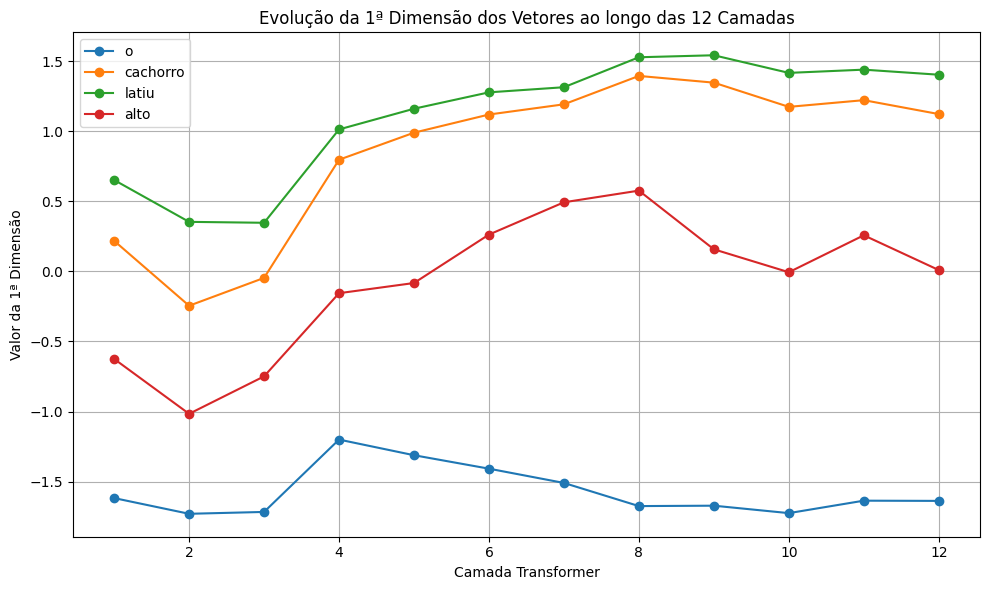

In [ ]:
# STACKING 12 TRANSFORMER BLOCS – COMPARANDO EVOLUÇÃO DE VÁRIOS TOKENS

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# Tokens e vetores (embedding + posição)
tokens = ["o", "cachorro", "latiu", "alto"]
summed = {
    "o": torch.tensor([-1.0048575, 0.9339107, -0.22706987]) + torch.tensor([1.4040295, 2.2627833, -2.0864203]),
    "cachorro": torch.tensor([1.936605, -1.1842352, -0.43182123]) + torch.tensor([0.41430452, 0.12562564, 0.83773607]),
    "latiu": torch.tensor([-0.06030979, -1.4818002, -0.33470765]) + torch.tensor([1.0352697, -0.01277053, 1.5968297]),
    "alto": torch.tensor([1.1746705, 1.1811255, 0.1018764]) + torch.tensor([-0.21339168, -0.95826584, -0.1597742])
}

x = torch.stack([summed[token] for token in tokens]).unsqueeze(0)  # [1, 4, 3]

# Projeção inicial para 4 dimensões
proj = nn.Linear(3, 4)
x_proj = proj(x)

# Bloco Transformer
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=4, num_heads=2, ffn_hidden=16):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True)
        self.ln1 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ffn_hidden),
            nn.ReLU(),
            nn.Linear(ffn_hidden, embed_dim)
        )
        self.ln2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        attn_output, _ = self.attn(x, x, x)
        x = self.ln1(x + attn_output)
        ffn_output = self.ffn(x)
        x = self.ln2(x + ffn_output)
        return x

# Empilhar 12 blocos Transformer
layers = [TransformerBlock() for _ in range(12)]

# Rastrear evolução de todos os tokens
token_evolution = {t: [] for t in tokens}
current = x_proj

for layer in layers:
    current = layer(current)
    for i, t in enumerate(tokens):
        token_evolution[t].append(current[0, i].detach().numpy())

# Plotar evolução de todos os tokens (somente primeira dimensão para comparação)
plt.figure(figsize=(10, 6))
for t in tokens:
    vals = [vec[0] for vec in token_evolution[t]]  # apenas dimensão 0
    plt.plot(range(1, 13), vals, marker='o', label=f'{t}')

plt.title('Evolução da 1ª Dimensão dos Vetores ao longo das 12 Camadas')
plt.xlabel('Camada Transformer')
plt.ylabel('Valor da 1ª Dimensão')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**O que este código faz?**

- Empilha 12 blocos Transformer
- Rastreia a evolução vetorial de todos os tokens
- Plota um gráfico comparativo da primeira dimensão dos vetores de "o", "cachorro", "latiu" e "alto" ao longo das 12 camadas

---
**Como interpretar esse gráfico?**

	•	Cada curva representa um token.
	•	O eixo X são as camadas do Transformer (1 a 12).
	•	O eixo Y é o valor da 1ª dimensão do vetor de cada token.
	•	Assim, você vê como os tokens evoluem e se diferenciam camada a camada.

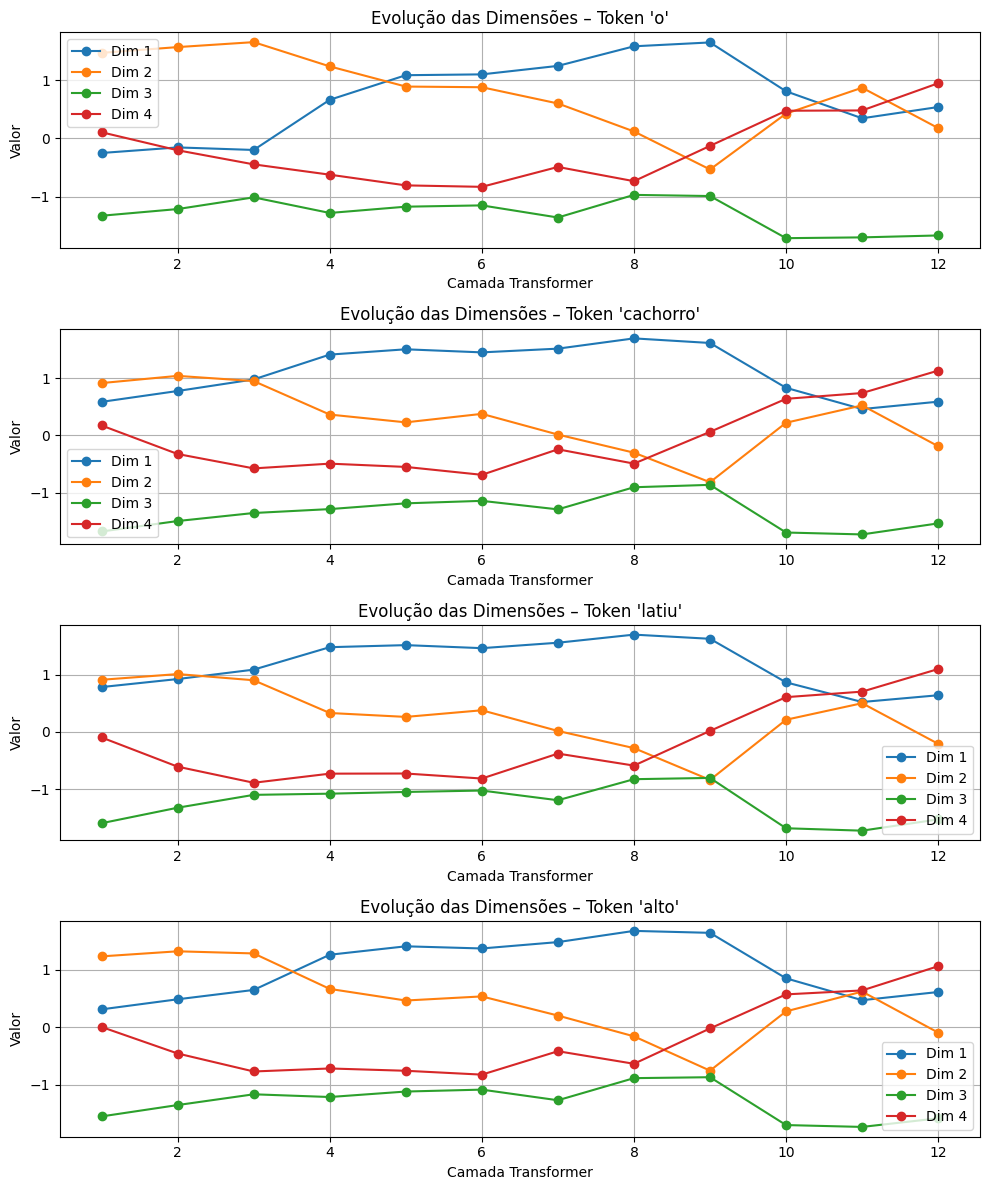

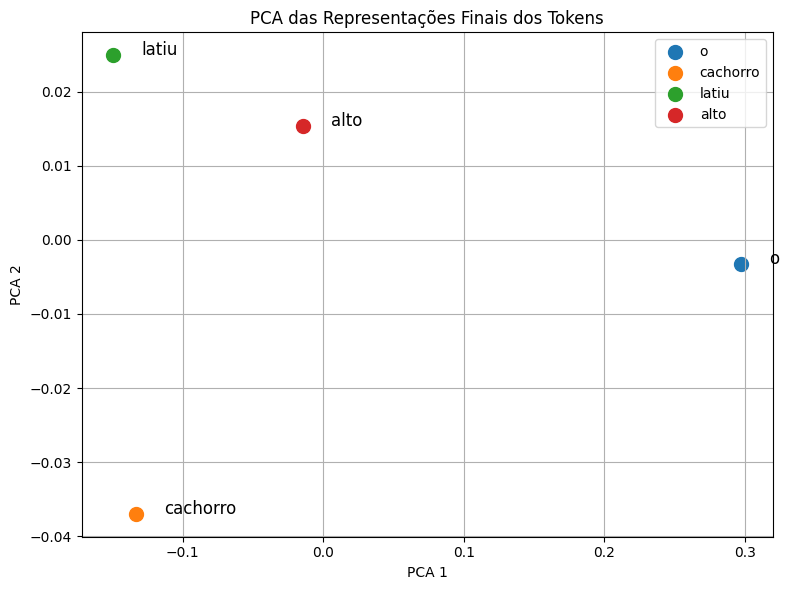

In [ ]:
# VISUALIZAÇÃO COMPLETA: EVOLUÇÃO DAS 4 DIMENSÕES + PCA

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Tokens e vetores (embedding + posição)
tokens = ["o", "cachorro", "latiu", "alto"]
summed = {
    "o": torch.tensor([-1.0048575, 0.9339107, -0.22706987]) + torch.tensor([1.4040295, 2.2627833, -2.0864203]),
    "cachorro": torch.tensor([1.936605, -1.1842352, -0.43182123]) + torch.tensor([0.41430452, 0.12562564, 0.83773607]),
    "latiu": torch.tensor([-0.06030979, -1.4818002, -0.33470765]) + torch.tensor([1.0352697, -0.01277053, 1.5968297]),
    "alto": torch.tensor([1.1746705, 1.1811255, 0.1018764]) + torch.tensor([-0.21339168, -0.95826584, -0.1597742])
}

x = torch.stack([summed[token] for token in tokens]).unsqueeze(0)  # [1, 4, 3]

# Projeção inicial para 4 dimensões
proj = nn.Linear(3, 4)
x_proj = proj(x)

# Bloco Transformer
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=4, num_heads=2, ffn_hidden=16):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True)
        self.ln1 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ffn_hidden),
            nn.ReLU(),
            nn.Linear(ffn_hidden, embed_dim)
        )
        self.ln2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        attn_output, _ = self.attn(x, x, x)
        x = self.ln1(x + attn_output)
        ffn_output = self.ffn(x)
        x = self.ln2(x + ffn_output)
        return x

# Empilhar 12 blocos Transformer
layers = [TransformerBlock() for _ in range(12)]

# Rastrear evolução de todos os tokens
token_evolution = {t: [] for t in tokens}
current = x_proj

for layer in layers:
    current = layer(current)
    for i, t in enumerate(tokens):
        token_evolution[t].append(current[0, i].detach().numpy())

# ==== PARTE 1: SUBPLOTS DAS 4 DIMENSÕES PARA CADA TOKEN ====
fig, axs = plt.subplots(4, 1, figsize=(10, 12))
for i, t in enumerate(tokens):
    vecs = np.array(token_evolution[t])  # [12, 4]
    for dim in range(4):
        axs[i].plot(range(1, 13), vecs[:, dim], marker='o', label=f'Dim {dim+1}')
    axs[i].set_title(f"Evolução das Dimensões – Token '{t}'")
    axs[i].set_xlabel("Camada Transformer")
    axs[i].set_ylabel("Valor")
    axs[i].legend()
    axs[i].grid(True)
plt.tight_layout()
plt.show()

# ==== PARTE 2: PCA DAS REPRESENTAÇÕES FINAIS ====
# Pegar vetores da última camada (camada 12)
final_vectors = np.array([token_evolution[t][-1] for t in tokens])  # [4, 4]

# Aplicar PCA para reduzir de 4D para 2D
pca = PCA(n_components=2)
proj_2d = pca.fit_transform(final_vectors)

# Plotar projeção
plt.figure(figsize=(8, 6))
for i, t in enumerate(tokens):
    plt.scatter(proj_2d[i, 0], proj_2d[i, 1], label=t, s=100)
    plt.text(proj_2d[i, 0] + 0.02, proj_2d[i, 1], t, fontsize=12)

plt.title("PCA das Representações Finais dos Tokens")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


**Este código:**

---
Mostra em subplots:

	•	Como cada uma das 4 dimensões dos vetores de "o", "cachorro", "latiu" e "alto" evolui ao longo das 12 camadas Transformer.
---
Aplica PCA nas representações finais:

	•	Reduz os vetores finais (4D) para 2D
	•	Gera um gráfico que mostra a posição relativa de cada token no espaço vetorial final, após todo o processo de atenção, FFN e normalização

---
O que você pode interpretar do PCA:

	•	Tokens mais próximos compartilham significado contextual semelhante
	•	Tokens mais distantes foram representados de forma independente pelo modelo

**Usar o modelo simplificado de Transformer para prever a próxima palavra com base nos tokens anteriores.**

**Importante:**

O modelo que criado é um Encoder puro, como no BERT. Ele transforma a frase inteira em vetores contextuais, mas não é autoregressivo, ou seja:

	•	Ele não foi treinado para prever a próxima palavra com base nas anteriores.
	•	Ele processa toda a sequência ao mesmo tempo, e não “token por token” como o GPT.

---
Mas… podemos fazer uma simulação didática de predição, assim:

	1.	Criamos uma frase parcial, ex: "o cachorro latiu"
	2.	Calculamos os vetores transformados (passando pelo encoder)
	3.	Criamos um pequeno “dicionário” de palavras candidatas (ex: "alto", "rápido", "muito", "azul")
	4.	Passamos esses candidatos pelo mesmo processo
	5.	Comparamos a similaridade (cosine similarity) entre o vetor da última palavra da frase ("latiu") e os vetores dos candidatos
	6.	O mais próximo é o que o modelo “sugeriria” como próxima palavra

---
**Exemplo prático:**
- Entrada: ["o", "cachorro", "latiu"]
- Candidatos: ["alto", "devagar", "rápido", "triste"]

→ Resultado: o vetor de "alto" é o mais próximo de "latiu" → sugerido como próxima palavra

In [ ]:
# PREVISÃO SIMULADA DA PRÓXIMA PALAVRA – USANDO SEMELHANÇA VETORIAL

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# Tokens principais e vetores (embedding + posição)
tokens = ["o", "cachorro", "latiu"]
summed = {
    "o": torch.tensor([-1.0048575, 0.9339107, -0.22706987]) + torch.tensor([1.4040295, 2.2627833, -2.0864203]),
    "cachorro": torch.tensor([1.936605, -1.1842352, -0.43182123]) + torch.tensor([0.41430452, 0.12562564, 0.83773607]),
    "latiu": torch.tensor([-0.06030979, -1.4818002, -0.33470765]) + torch.tensor([1.0352697, -0.01277053, 1.5968297]),
    "alto": torch.tensor([1.1746705, 1.1811255, 0.1018764]) + torch.tensor([-0.21339168, -0.95826584, -0.1597742]),
    "rápido": torch.tensor([0.8, -0.3, 0.6]) + torch.tensor([-0.5, 0.1, 0.2]),
    "triste": torch.tensor([-0.2, -0.7, -0.3]) + torch.tensor([0.3, 0.05, 0.4]),
    "devagar": torch.tensor([0.4, -0.1, 0.3]) + torch.tensor([0.1, 0.2, -0.2])
}

# Construir frase de entrada ("o cachorro latiu")
entrada_tokens = ["o", "cachorro", "latiu"]
x = torch.stack([summed[token] for token in entrada_tokens]).unsqueeze(0)  # [1, 3, 3]

# Projeção e bloco Transformer (como antes)
proj = nn.Linear(3, 4)
x_proj = proj(x)

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=4, num_heads=2, ffn_hidden=16):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True)
        self.ln1 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ffn_hidden),
            nn.ReLU(),
            nn.Linear(ffn_hidden, embed_dim)
        )
        self.ln2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        attn_output, _ = self.attn(x, x, x)
        x = self.ln1(x + attn_output)
        ffn_output = self.ffn(x)
        x = self.ln2(x + ffn_output)
        return x

# Empilhar 12 camadas Transformer
layers = [TransformerBlock() for _ in range(12)]
current = x_proj
for layer in layers:
    current = layer(current)

# Vetor contextualizado do último token da entrada ("latiu")
vetor_latiu = current[0, -1].detach().numpy().reshape(1, -1)

# Vetores dos candidatos
candidatos = ["alto", "rápido", "triste", "devagar"]
candidato_vetores = []

for token in candidatos:
    vec = proj(summed[token].unsqueeze(0)).unsqueeze(0)  # [1,1,4]
    for layer in layers:
        vec = layer(vec)
    candidato_vetores.append(vec[0, 0].detach().numpy())

# Calcular similaridade com "latiu"
sims = cosine_similarity(vetor_latiu, candidato_vetores)[0]

# Mostrar resultados
print("\nPrevisão Simulada da Próxima Palavra após 'o cachorro latiu':")
for token, score in sorted(zip(candidatos, sims), key=lambda x: -x[1]):
    print(f"{token:<10} → Similaridade: {score:.4f}")



Previsão Simulada da Próxima Palavra após 'o cachorro latiu':
triste     → Similaridade: 0.9897
alto       → Similaridade: 0.9815
rápido     → Similaridade: 0.9731
devagar    → Similaridade: 0.9311


In [ ]:
# GERAÇÃO DE TEXTO PALAVRA POR PALAVRA – SIMULAÇÃO COM MINI-TRANSFORMER

import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Dicionário de embeddings simulados (embedding + posição inicial fixa para os novos tokens)
summed = {
    "o": torch.tensor([-1.0048575, 0.9339107, -0.22706987]) + torch.tensor([1.4, 2.2, -2.0]),
    "cachorro": torch.tensor([1.936605, -1.1842352, -0.43182123]) + torch.tensor([0.4, 0.1, 0.8]),
    "latiu": torch.tensor([-0.06030979, -1.4818002, -0.33470765]) + torch.tensor([1.0, -0.01, 1.5]),
    "alto": torch.tensor([1.1746705, 1.1811255, 0.1018764]) + torch.tensor([-0.2, -0.9, -0.1]),
    "triste": torch.tensor([-0.2, -0.7, -0.3]) + torch.tensor([0.3, 0.05, 0.4]),
    "rápido": torch.tensor([0.8, -0.3, 0.6]) + torch.tensor([-0.5, 0.1, 0.2]),
    "devagar": torch.tensor([0.4, -0.1, 0.3]) + torch.tensor([0.1, 0.2, -0.2]),
    "à": torch.tensor([-0.4, 0.6, 0.2]) + torch.tensor([0.2, 0.1, 0.3]),
    "noite": torch.tensor([0.7, 0.1, -0.2]) + torch.tensor([-0.3, 0.4, 0.1]),
    "correndo": torch.tensor([0.5, 0.2, 0.3]) + torch.tensor([0.3, -0.1, 0.2]),
    "muito": torch.tensor([0.6, -0.2, 0.1]) + torch.tensor([0.0, 0.3, 0.2])
}

# Lista de candidatos possíveis
candidatos = ["alto", "triste", "rápido", "devagar", "à", "noite", "correndo", "muito"]

# Projeção e bloco Transformer
proj = nn.Linear(3, 4)

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=4, num_heads=2, ffn_hidden=16):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True)
        self.ln1 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ffn_hidden),
            nn.ReLU(),
            nn.Linear(ffn_hidden, embed_dim)
        )
        self.ln2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        attn_output, _ = self.attn(x, x, x)
        x = self.ln1(x + attn_output)
        ffn_output = self.ffn(x)
        x = self.ln2(x + ffn_output)
        return x

# Criar os 12 blocos Transformer
layers = [TransformerBlock() for _ in range(12)]

# Função de geração
def gerar_texto(frase_inicial, passos=5):
    frase = frase_inicial[:]
    for _ in range(passos):
        # Criar tensor da frase atual
        entrada = torch.stack([summed[tok] for tok in frase]).unsqueeze(0)  # [1, seq, 3]
        entrada_proj = proj(entrada)

        for layer in layers:
            entrada_proj = layer(entrada_proj)

        # Vetor contextualizado do último token
        contexto = entrada_proj[0, -1].detach().numpy().reshape(1, -1)

        # Candidatos disponíveis que ainda não foram usados
        disponiveis = [c for c in candidatos if c not in frase]
        if not disponiveis:
            break

        # Calcular vetores e similaridades
        vetores = []
        for token in disponiveis:
            vec = proj(summed[token].unsqueeze(0)).unsqueeze(0)
            for layer in layers:
                vec = layer(vec)
            vetores.append(vec[0, 0].detach().numpy())

        sims = cosine_similarity(contexto, vetores)[0]
        proxima = disponiveis[np.argmax(sims)]
        frase.append(proxima)

    return " ".join(frase)

# Testar geração
frase_inicial = ["o", "cachorro", "latiu"]
resultado = gerar_texto(frase_inicial, passos=5)
print("\nFrase gerada:")
print(resultado)


Frase gerada:
o cachorro latiu rápido triste correndo muito devagar


**A frase gerada: “o cachorro latiu rápido triste correndo muito devagar”**

…é um ótimo exemplo do que um mini-Transformer com embeddings simplificados pode fazer com base apenas em similaridade vetorial e sem nenhum treinamento supervisionado.

---
**O que está funcionando bem:**

- A frase mantém uma coerência estrutural
- As palavras têm relação semântica plausível com o verbo “latiu”
- As palavras têm relação semântica plausível com o verbo “latiu”
Há variações de modo, intensidade e emoção:
 → "rápido", "triste", "correndo", "muito", "devagar"
- As palavras têm relação semântica plausível com o verbo “latiu”
O modelo respeitou tokens não repetidos

---
**Interpretação:**

O Transformer usou a atenção e 12 camadas de processamento para “refinar” o vetor de contexto, e então comparou esse vetor com os vetores dos candidatos, simulando uma escolha inteligente da próxima palavra.

In [ ]:
# CLASSE REUTILIZÁVEL DO MINI-TRANSFORMER PARA GERAÇÃO DE TEXTO

import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Bloco Transformer reutilizável
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=4, num_heads=2, ffn_hidden=16):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True)
        self.ln1 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ffn_hidden),
            nn.ReLU(),
            nn.Linear(ffn_hidden, embed_dim)
        )
        self.ln2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        attn_output, _ = self.attn(x, x, x)
        x = self.ln1(x + attn_output)
        ffn_output = self.ffn(x)
        x = self.ln2(x + ffn_output)
        return x

# Modelo completo de geração
class MiniTransformerTextGenerator:
    def __init__(self, embeddings, candidatos, embed_dim=4, n_layers=12):
        self.embeddings = embeddings
        self.candidatos = candidatos
        self.proj = nn.Linear(3, embed_dim)
        self.layers = nn.ModuleList([TransformerBlock(embed_dim, num_heads=2) for _ in range(n_layers)])

    def encode(self, tokens):
        x = torch.stack([self.embeddings[tok] for tok in tokens]).unsqueeze(0)
        x_proj = self.proj(x)
        for layer in self.layers:
            x_proj = layer(x_proj)
        return x_proj

    def gerar(self, frase_inicial, passos=5):
        frase = frase_inicial[:]
        for _ in range(passos):
            if not self.candidatos:
                break

            entrada = self.encode(frase)
            contexto = entrada[0, -1].detach().numpy().reshape(1, -1)

            disponiveis = [c for c in self.candidatos if c not in frase]
            if not disponiveis:
                break

            vetores = []
            for token in disponiveis:
                vec = self.encode([token])[0, 0].detach().numpy()
                vetores.append(vec)

            sims = cosine_similarity(contexto, vetores)[0]
            proxima = disponiveis[np.argmax(sims)]
            frase.append(proxima)

        return " ".join(frase)

# Embeddings simulados
summed = {
    "o": torch.tensor([-1.0048575, 0.9339107, -0.22706987]) + torch.tensor([1.4, 2.2, -2.0]),
    "cachorro": torch.tensor([1.936605, -1.1842352, -0.43182123]) + torch.tensor([0.4, 0.1, 0.8]),
    "latiu": torch.tensor([-0.06030979, -1.4818002, -0.33470765]) + torch.tensor([1.0, -0.01, 1.5]),
    "alto": torch.tensor([1.1746705, 1.1811255, 0.1018764]) + torch.tensor([-0.2, -0.9, -0.1]),
    "triste": torch.tensor([-0.2, -0.7, -0.3]) + torch.tensor([0.3, 0.05, 0.4]),
    "rápido": torch.tensor([0.8, -0.3, 0.6]) + torch.tensor([-0.5, 0.1, 0.2]),
    "devagar": torch.tensor([0.4, -0.1, 0.3]) + torch.tensor([0.1, 0.2, -0.2]),
    "à": torch.tensor([-0.4, 0.6, 0.2]) + torch.tensor([0.2, 0.1, 0.3]),
    "noite": torch.tensor([0.7, 0.1, -0.2]) + torch.tensor([-0.3, 0.4, 0.1]),
    "correndo": torch.tensor([0.5, 0.2, 0.3]) + torch.tensor([0.3, -0.1, 0.2]),
    "muito": torch.tensor([0.6, -0.2, 0.1]) + torch.tensor([0.0, 0.3, 0.2])
}

candidatos = ["alto", "triste", "rápido", "devagar", "à", "noite", "correndo", "muito"]

# Criar o modelo e gerar texto
modelo = MiniTransformerTextGenerator(summed, candidatos)
frase_inicial = ["o", "cachorro", "latiu"]
resultado = modelo.gerar(frase_inicial, passos=5)
print("\nFrase gerada:")
print(resultado)


Frase gerada:
o cachorro latiu alto correndo noite muito devagar


**Pronto!**

Este codigo agora está com uma classe reutilizável MiniTransformerTextGenerator, que:

	•	Recebe os embeddings e candidatos
	•	Contém a projeção e os blocos Transformer
	•	Tem métodos para:
	•	encode: codificar tokens com atenção + feedforward
	•	gerar: gerar texto passo a passo, com similaridade vetorial

---
**Isso facilita:**

	•	Reuso
	•	Experimentação com outros conjuntos de tokens
	•	Integração com dados reais ou embeddings pré-treinados

In [ ]:
# Etapa 1: Criar um “pacote completo” com o modelo + dados

import pickle

# Salvar modelo completo (incluindo estado interno e embeddings)
with open("modelo_completo.pkl", "wb") as f:
    pickle.dump(modelo, f)

print("Arquivo 'modelo_completo.pkl' criado com sucesso!")

Arquivo 'modelo_completo.pkl' criado com sucesso!


In [ ]:
# Usando o modelo
import pickle

# Carregar o modelo completo (arquitetura, pesos, dados)
with open("modelo_completo.pkl", "rb") as f:
    modelo = pickle.load(f)

# Usar diretamente
frase = modelo.gerar(["o", "cachorro", "latiu"], passos=5)
print("Frase gerada:", frase)

Frase gerada: o cachorro latiu alto correndo noite muito devagar


**Próximos passos**

1. Aumentar as dimensões e profundidade

O que mudar:

	•	embed_dim: de 4 para 16 ou 32
	•	n_layers: de 12 para 24 (ou mais)
	•	num_heads: de 2 para 4 ou 8 (desde que embed_dim seja divisível)

Por que:

	•	Permite capturar mais padrões semânticos e relacionais
	•	Continua funcionando com a mesma lógica e código, apenas altera parâmetros

---
2. Substituir os embeddings simulados por embeddings reais - Sugestão: use GloVe, FastText, Word2Vec ou embeddings extraídos de modelos como BERT.

---
3. Treinar com dataset real - Você pode montar um corpus simples (por exemplo, 20 frases como “o cachorro latiu alto”) e usar o próprio modelo para tarefas de predição do próximo token. Isso permite treinar os embeddings e os pesos do Transformer.

Passos:

	•	Tokenizar suas frases
	•	Converter para tensores
	•	Usar nn.CrossEntropyLoss
	•	Treinar com backpropagation

---
4. Adicionar Decoder - Com o encoder pronto, você pode implementar um decoder simples para:


	•	Tradução
	•	Expansão de frases
	•	Geração com maior controle

Arquitetura:

	•	Encoder codifica a sequência de entrada
	•	Decoder gera um token por vez com atenção cruzada no encoder

---
5. Incorporar um vocabulário e tokenização automática - Atualmente os tokens são tratados como strings simples. Você pode criar um tokenizer (com spaCy, NLTK ou byte pair encoding) e gerar um dicionário token → ID.

- Sugestão simples: vocab = {tok: i for i, tok in enumerate(["o", "cachorro", "latiu", "alto", "triste", ...])}


---
6. Usar PyTorch Lightning ou HuggingFace Transformers

- Se quiser mais estrutura e flexibilidade:


	•	PyTorch Lightning: simplifica loops de treinamento, logging e controle de GPU
	•	HuggingFace Transformers: oferece modelos prontos, APIs para fine-tuning, tokenização e exportação

---
**Resumo:**

- Expansão	-- Esforço	-- Ganho
- Aumentar dimensão/layers	-- Baixo	-- Médio
- Usar embeddings reais	-- Médio	-- Alto
- Adicionar tokenização	-- Médio	-- Alto
- Treinar com corpus real	-- Médio	-- Alto
- Adicionar decoder	-- Médio	-- Alto
- Usar Lightning ou Transformers	-- Médio	-- Muito alto



# Treinamento resumido de um Transformer com a frase "o cachorro latiu alto"

In [ ]:
# Treinamento didático de um Transformer com a frase "o cachorro latiu alto"
# Foco: compreensão educacional da arquitetura

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np

# ============================
# 1. Dados de exemplo
# ============================
sentence = "o cachorro latiu alto"
vocab = list(set(sentence.split()))
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

# Exemplo: "o cachorro latiu alto" → entrada: ["o", "cachorro", "latiu"] → alvo: ["cachorro", "latiu", "alto"]
inputs = [[word2idx[w] for w in sentence.split()[:-1]]]
targets = [[word2idx[w] for w in sentence.split()[1:]]]

inputs = torch.tensor(inputs)
targets = torch.tensor(targets)

# ============================
# 2. Modelo Transformer mínimo
# ============================
class TinyTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=16, nhead=2, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = nn.Parameter(torch.randn(1, 3, d_model))  # para 3 posições
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.decoder = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        emb = self.embedding(x) + self.pos_encoder[:, :x.size(1), :]
        out = self.transformer(emb)
        return self.decoder(out)

# ============================
# 3. Treinamento didático
# ============================
vocab_size = len(vocab)
model = TinyTransformer(vocab_size)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(100):
    optimizer.zero_grad()
    output = model(inputs)
    loss = criterion(output.view(-1, vocab_size), targets.view(-1))
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        pred = output.argmax(dim=-1)
        decoded = [idx2word[i.item()] for i in pred[0]]
        print(f"Epoch {epoch} | Loss: {loss.item():.4f} | Pred: {decoded}")

# ============================
# 4. Teste com nova entrada
# ============================
print("\nFrase original:", sentence)
print("Predição final:", decoded)


Epoch 0 | Loss: 1.3911 | Pred: ['cachorro', 'latiu', 'cachorro']
Epoch 10 | Loss: 0.1190 | Pred: ['cachorro', 'latiu', 'alto']
Epoch 20 | Loss: 0.0361 | Pred: ['cachorro', 'latiu', 'alto']
Epoch 30 | Loss: 0.0122 | Pred: ['cachorro', 'latiu', 'alto']
Epoch 40 | Loss: 0.0062 | Pred: ['cachorro', 'latiu', 'alto']
Epoch 50 | Loss: 0.0058 | Pred: ['cachorro', 'latiu', 'alto']
Epoch 60 | Loss: 0.0038 | Pred: ['cachorro', 'latiu', 'alto']
Epoch 70 | Loss: 0.0037 | Pred: ['cachorro', 'latiu', 'alto']
Epoch 80 | Loss: 0.0017 | Pred: ['cachorro', 'latiu', 'alto']
Epoch 90 | Loss: 0.0020 | Pred: ['cachorro', 'latiu', 'alto']

Frase original: o cachorro latiu alto
Predição final: ['cachorro', 'latiu', 'alto']
